In [1]:
import numpy as np 
import pandas as pd 
import h5py
import re
import uproot
import glob 

from collections import Counter
import copy, sys, os
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from tqdm import tqdm 
# adding path to folder
from datetime import datetime
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.colors as mcolors  # Importing the correct module for colors


from utils_analysis import ParticleCode, load_dataset
# Load your custom style 
plt.style.use('./cfg/my_custom_plot.mplstyle')

# use these lines on top of your matplotlib script
import matplotlib.ticker
class MyLocator(matplotlib.ticker.AutoMinorLocator):
    def __init__(self, n=4):
        super().__init__(n=n)
matplotlib.ticker.AutoMinorLocator = MyLocator        
 
# Now use matplotlib as usual.       
import matplotlib.pyplot as plt
plt.rcParams["xtick.minor.visible"] =  True
plt.rcParams["ytick.minor.visible"] =  True

sys.path.insert(0, '../tools/')
from caf_readers import CafReader
from mx2_matching import Mx2_DS_Match

In [2]:
# Load datasets 
n_files = 300
location = "nersc"
type="mr6.2"
df = load_dataset(n_files,location, type)
# Create a caf reader
caf_reader = CafReader(df)

Reading  300  files gk
Location selected nersc
Openning MiniRun 6.2 CAFs


100%|██████████| 300/300 [11:47<00:00,  2.36s/it]


In [4]:
import numpy as np

class NeutrinoSelection:
    def __init__(self, ev_data, pdg_tab,QE_true=False, QE_reco=False, exclusive=False, mode='mx2', proton_threshold=2):
        """
        Initialize NeutrinoSelection with event data and PDG table.
        """
        self.ev_data = ev_data
        self.pdg_tab = pdg_tab
        self.tpc_dist = 5
        self.xbound = 63.931
        self.ybound = 62.076
        self.zbound = 64.3163
        self.QE_true = QE_true
        self.QE_reco = QE_reco
        self.mode = mode
        self.muon_track= [None, None]
        self.exclusive = exclusive
        self.proton_threshold=proton_threshold
        self.match = None
        self.best_match_idx = None
        self.signal = np.zeros_like(self.ev_data['rec.mc.nu.vtx.x'], dtype=bool)
        self.reco_vertices = np.zeros_like(self.ev_data['rec.common.ixn.dlp.vtx.x'], dtype=bool)
        self.ixn_dict={
            'file_number':[], 'event_number':[], 'ixn_number':[],'true_ixn_number':[], 'cc':[], 'nprim':[], 'nsec':[], 'nneutron':[], 'nproton':[],
            'npip':[], 'npim':[], 'npi0':[], 'mode':[], 'match':[], 'nprim_reco':[], 'nsec_reco':[], 'prim_pdgs_vtx':[], 'sec_pdgs_vtx':[],
            'prim_bm_type':[], 'sec_bm_type':[], 'prim_bm_pdg':[], 'sec_bm_pdg':[], 'prim_E_vtx':[]
            }
    
    def true_neutrino_signal(self):
        """
        Identifies true neutrino signals based on various conditions.
        """
        # QE-like post-FSI with any number of neutrons
        if self.QE_true:
            mask_t = (
                (abs(self.ev_data['rec.mc.nu.vtx.x']) < self.xbound - self.tpc_dist) &
                (abs(self.ev_data['rec.mc.nu.vtx.x']) > self.tpc_dist) &
                (abs(self.ev_data['rec.mc.nu.vtx.y']) < self.ybound - self.tpc_dist) &
                (abs(self.ev_data['rec.mc.nu.vtx.z']) > self.tpc_dist) &
                (abs(self.ev_data['rec.mc.nu.vtx.z']) < self.zbound - self.tpc_dist) &
                (self.ev_data['rec.mc.nu.targetPDG'] == self.pdg_tab.argon) &
                (self.ev_data['rec.mc.nu.iscc'] == 1) &
                (self.ev_data['rec.mc.nu.pdg'] == -1 * self.pdg_tab.numu) &
                (np.isin(self.ev_data['rec.mc.nu.mode'], [1,4,10])) &
               # (self.ev_data['rec.mc.nu.nproton'] == 0) &
                (self.ev_data['rec.mc.nu.npip'] == 0) &
                (self.ev_data['rec.mc.nu.npim'] == 0) &
                (self.ev_data['rec.mc.nu.npi0'] == 0) &
                (self.ev_data['rec.mc.nu.nneutron'] >= 1)
            )
            for ix in range(self.ev_data['rec.mc.nu..length']):
                if mask_t[ix]:
                    n_particles = self.ev_data['rec.mc.nu.prim..length'][ix]
                    n_pre = np.sum(self.ev_data['rec.mc.nu.prim..length'][:ix]) if ix > 0 else 0
                    for ip in range(n_pre, n_pre + n_particles):
                        pdg = self.ev_data['rec.mc.nu.prim.pdg'][ip]
                        if pdg == self.pdg_tab.proton:
                            xs = self.ev_data['rec.mc.nu.prim.start_pos.x'][ip]
                            ys = self.ev_data['rec.mc.nu.prim.start_pos.y'][ip]
                            zs = self.ev_data['rec.mc.nu.prim.start_pos.z'][ip]
                            xe = self.ev_data['rec.mc.nu.prim.end_pos.x'][ip]
                            ye = self.ev_data['rec.mc.nu.prim.end_pos.y'][ip]
                            ze = self.ev_data['rec.mc.nu.prim.end_pos.z'][ip]
                            track_length = np.sqrt((xe - xs) ** 2 + (ye - ys) ** 2 + (ze - zs) ** 2)
                            if track_length > self.proton_threshold:
                                self.signal[ix] = False
        else:
            mask_t = (
                (abs(self.ev_data['rec.mc.nu.vtx.x']) < self.xbound - self.tpc_dist) &
                (abs(self.ev_data['rec.mc.nu.vtx.x']) > self.tpc_dist) &
                (abs(self.ev_data['rec.mc.nu.vtx.y']) < self.ybound - self.tpc_dist) &
                (abs(self.ev_data['rec.mc.nu.vtx.z']) > self.tpc_dist) &
                (abs(self.ev_data['rec.mc.nu.vtx.z']) < self.zbound - self.tpc_dist) &
                (self.ev_data['rec.mc.nu.targetPDG'] == self.pdg_tab.argon) &
                (self.ev_data['rec.mc.nu.iscc'] == 1) &
                (abs(self.ev_data['rec.mc.nu.pdg']) == self.pdg_tab.numu)
            )

        self.signal[mask_t] = True

        for ix in range(self.ev_data['rec.mc.nu..length']):
            if mask_t[ix]:
                n_particles = self.ev_data['rec.mc.nu.prim..length'][ix]
                n_pre = np.sum(self.ev_data['rec.mc.nu.prim..length'][:ix]) if ix > 0 else 0
                for ip in range(n_pre, n_pre + n_particles):
                    pdg = self.ev_data['rec.mc.nu.prim.pdg'][ip]
                    if np.abs(pdg) == self.pdg_tab.muon:
                        Elep = self.ev_data['rec.mc.nu.prim.p.E'][ip]
                        cosL = self.calculate_cosL(ip)
                        if cosL < 0.9 and Elep < 1:
                            self.signal[ix] = False
        return self.signal
    
    def calculate_cosL(self, ip):
        """
        Utility function to calculate cosL.
        """
        dz = self.ev_data['rec.mc.nu.prim.start_pos.z'][ip] - self.ev_data['rec.mc.nu.prim.end_pos.z'][ip]
        start_pos = np.array([
            self.ev_data['rec.mc.nu.prim.start_pos.x'][ip],
            self.ev_data['rec.mc.nu.prim.start_pos.y'][ip],
            self.ev_data['rec.mc.nu.prim.start_pos.z'][ip]
        ])
        end_pos = np.array([
            self.ev_data['rec.mc.nu.prim.end_pos.x'][ip],
            self.ev_data['rec.mc.nu.prim.end_pos.y'][ip],
            self.ev_data['rec.mc.nu.prim.end_pos.z'][ip]
        ])
        track_length = np.linalg.norm(start_pos - end_pos)
        return abs(dz / track_length)
    
    def reco_neutrino_signal(self):
        """
        Defines the reconstructed neutrino signal in the fiducial volume.
        """
        mask_fv = (
            (abs(self.ev_data['rec.common.ixn.dlp.vtx.x']) < self.xbound - self.tpc_dist) &
            (abs(self.ev_data['rec.common.ixn.dlp.vtx.x']) > self.tpc_dist) &
            (abs(self.ev_data['rec.common.ixn.dlp.vtx.y']) < self.ybound - self.tpc_dist) &
            (abs(self.ev_data['rec.common.ixn.dlp.vtx.z']) > self.tpc_dist) &
            (abs(self.ev_data['rec.common.ixn.dlp.vtx.z']) < self.zbound - self.tpc_dist)
        )
        
        if self.mode == 'nocuts': 
            self.reco_vertices = np.ones_like(self.ev_data['rec.common.ixn.dlp.vtx.x'], dtype=bool)
        elif self.mode == 'FV':
            self.reco_vertices = mask_fv
        elif self.mode == '2x2':
            track_out_2x2 = self.track_selection_signal()
            self.reco_vertices = mask_fv & track_out_2x2
        elif self.mode == 'mx2':
            track_out_2x2 = self.track_selection_signal()
            match_mx2, self.muon_track = self.track_match_mx2()
            self.reco_vertices = mask_fv &  track_out_2x2 & match_mx2
        else:
            raise ValueError("Invalid mode. Options: nocuts, FV, 2x2, mx2")
        
        if self.QE_reco: 
            self.reco_vertices = self.QE_reco_signal(self.reco_vertices)
        return self.reco_vertices, self.muon_track    

    def QE_reco_signal(self, mask_fv):
        """
        Applies QE-specific signal selection.
        """
        QE_signal = mask_fv.copy()
        for vtx in range(self.ev_data['rec.common.ixn.dlp..length']):
            n_vtx = self.ev_data['rec.common.ixn.dlp.part.dlp..length'][vtx]
            n_pre = np.sum(self.ev_data['rec.common.ixn.dlp.part.dlp..length'][:vtx]) if vtx > 0 else 0
            count_prim = 0
            count_sec = 0

            if self.exclusive:
                for ip in range(n_pre, n_pre + n_vtx):
                    count_prim += self.ev_data['rec.common.ixn.dlp.part.dlp.primary'][ip]
                    count_sec += 1 if not self.ev_data['rec.common.ixn.dlp.part.dlp.primary'][ip] else 0

                if count_prim == 1 and count_sec == 1:
                    continue
                else:
                    QE_signal[vtx] = 0
            else:
                for ip in range(n_pre, n_pre + n_vtx):
                    count_prim += self.ev_data['rec.common.ixn.dlp.part.dlp.primary'][ip]
                    if count_prim > 1:
                        break
                if count_prim != 1:
                    QE_signal[vtx] = 0
        return QE_signal

    def track_selection_signal(self):
        """
        Selects tracks that exit the 2x2 volume.
        """
        z_end_track = self.ev_data['rec.common.ixn.dlp.part.dlp.end.z']
        is_reco_primary = self.ev_data['rec.common.ixn.dlp.part.dlp.primary']
        track_out = np.zeros_like(self.ev_data['rec.common.ixn.dlp.vtx.x'], dtype=bool)

        for vtx in range(len(self.ev_data['rec.common.ixn.dlp.vtx.x'])):
            n_reco_tracks = self.ev_data['rec.common.ixn.dlp.part.dlp..length'][vtx]
            n_pre = np.sum(self.ev_data['rec.common.ixn.dlp.part.dlp..length'][:vtx]) if vtx > 0 else 0
            for ip in range(n_pre, n_pre + n_reco_tracks):
                if is_reco_primary[ip] and z_end_track[ip] >= self.zbound:
                    track_out[vtx] = True
                    break
        return track_out

    def track_match_mx2(self):
        """
        Matches tracks with MINERvA data.
        """
        minerva_data = caf_reader.get_minerva_data(self.ev_data)
        is_reco_primary = self.ev_data['rec.common.ixn.dlp.part.dlp.primary']
        x_start_track = self.ev_data['rec.common.ixn.dlp.part.dlp.start.x']
        y_start_track = self.ev_data['rec.common.ixn.dlp.part.dlp.start.y']
        z_start_track = self.ev_data['rec.common.ixn.dlp.part.dlp.start.z']
        x_end_track = self.ev_data['rec.common.ixn.dlp.part.dlp.end.x']
        y_end_track = self.ev_data['rec.common.ixn.dlp.part.dlp.end.y']
        z_end_track = self.ev_data['rec.common.ixn.dlp.part.dlp.end.z']
        track_Mx2 = np.zeros_like(self.ev_data['rec.common.ixn.dlp.vtx.x'], dtype=bool)

        for vtx in range(len(self.ev_data['rec.common.ixn.dlp.vtx.x'])):
            n_reco_tracks = self.ev_data['rec.common.ixn.dlp.part.dlp..length'][vtx]
            n_pre = np.sum(self.ev_data['rec.common.ixn.dlp.part.dlp..length'][:vtx]) if vtx > 0 else 0
            for ip in range(n_pre, n_pre + n_reco_tracks):
                if is_reco_primary[ip] and z_end_track[ip] >= self.zbound:
                    self.muon_track = [
                        [x_start_track[ip], y_start_track[ip], z_start_track[ip]],
                        [x_end_track[ip], y_end_track[ip], z_end_track[ip]]
                    ]
                    reco_vtx = [
                        self.ev_data['rec.common.ixn.dlp.vtx.x'][vtx],
                        self.ev_data['rec.common.ixn.dlp.vtx.y'][vtx],
                        self.ev_data['rec.common.ixn.dlp.vtx.z'][vtx]
                    ]
                    m_index, ds_dp, deltaX, deltaY, exit_minerva = Mx2_DS_Match(
                        self.muon_track, minerva_data, reco_vtx, mc=True, verbose=False)
                    if exit_minerva and m_index is not None:
                        track_Mx2[vtx] = True
        return track_Mx2, self.muon_track
    
    def matching(self, vtx_index):
        n_vtx = self.ev_data['rec.common.ixn.dlp.truth..length'][vtx_index]
        n_pre = np.sum(self.ev_data['rec.common.ixn.dlp.truth..length'][:vtx_index]) if vtx_index > 0 else 0 
        max_overlap = 0
        for ip in range(n_pre, n_pre + n_vtx):
            temp_overlap = self.ev_data['rec.common.ixn.dlp.truthOverlap'][ip]
            temp_tp_idx = self.ev_data['rec.common.ixn.dlp.truth'][ip]
            if temp_overlap > max_overlap:
                max_overlap = temp_overlap
                self.best_match_idx = temp_tp_idx
        if self.best_match_idx is not None:
            delta_x = np.abs(self.ev_data['rec.mc.nu.vtx.x'][self.best_match_idx] - self.ev_data['rec.common.ixn.dlp.vtx.x'][vtx_index])
            delta_y = np.abs(self.ev_data['rec.mc.nu.vtx.y'][self.best_match_idx] - self.ev_data['rec.common.ixn.dlp.vtx.y'][vtx_index])
            delta_z = np.abs(self.ev_data['rec.mc.nu.vtx.z'][self.best_match_idx] - self.ev_data['rec.common.ixn.dlp.vtx.z'][vtx_index])
            if self.signal[self.best_match_idx] and delta_x < 5 and delta_y < 5 and delta_z < 5:
                self.reco_vertices[vtx_index] = True
                self.match = True
            else: self.match = False
        return self.match, self.best_match_idx, self.reco_vertices
    
    
    
    def get_num_prim_and_sec(self, reco_vtx):
        """count how many primary and secondary
        particles are in a reco vertex."""
        prim_pdgs_vtx=[]
        prim_E_vtx=[]
        sec_pdgs_vtx =[]
        prim_bm_type, sec_bm_type, prim_bm_pdg, sec_bm_pdg = [],[],[],[]
        count_prim = 0
        count_sec = 0
        reco_data = caf_reader.get_reco_ixn_data(self.ev_data, reco_vtx)
        n_part = len(reco_data['rec.common.ixn.dlp.part.dlp.E'])
        for ip in range(n_part):
            best_match_type, best_match_ixn, best_match_idx, parent_id= self.match_finder(ip,reco_vtx)
            #reco primaries         
            if self.ev_data['rec.common.ixn.dlp.part.dlp.primary'][ip]:
                prim_pdgs_vtx.append(self.ev_data['rec.common.ixn.dlp.part.dlp.pdg'][ip])
                prim_E_vtx.append(self.ev_data['rec.common.ixn.dlp.part.dlp.E'][ip])
                count_prim += 1
                if best_match_ixn is not None:
                    prim_bm_type.append(best_match_type)
                    bm_truth_data = caf_reader.get_true_ixn_data(self.ev_data, best_match_ixn)
                    if best_match_type ==3: 
                        prim_bm_pdg.append(bm_truth_data['rec.mc.nu.sec.pdg'][best_match_idx])
                    elif(best_match_type ==1):
                        prim_bm_pdg.append(bm_truth_data['rec.mc.nu.prim.pdg'][best_match_idx]) 
                    else:  prim_bm_pdg.append(0)
                else:
                    prim_bm_pdg.append(None)
                    prim_bm_type.append(None)
            #reco secondaries
            else:
                count_sec += 1 
                sec_pdgs_vtx.append(self.ev_data['rec.common.ixn.dlp.part.dlp.pdg'][ip])
                if best_match_ixn is not None:
                    sec_bm_type.append(best_match_type)
                    bm_truth_data = caf_reader.get_true_ixn_data(self.ev_data, best_match_ixn)
                    if best_match_type ==3: 
                        sec_bm_pdg.append(bm_truth_data['rec.mc.nu.sec.pdg'][best_match_idx])
                    elif(best_match_type ==1):
                        sec_bm_pdg.append(bm_truth_data['rec.mc.nu.prim.pdg'][best_match_idx]) 
                    else: sec_bm_pdg.append(0)
                else:   
                    sec_bm_pdg.append(None)
                    sec_bm_type.append(None)

        return count_prim, count_sec, prim_pdgs_vtx, sec_pdgs_vtx, prim_bm_type, sec_bm_type, prim_bm_pdg, sec_bm_pdg, prim_E_vtx

    def match_finder(self, ip, reco_vtx):
        reco_data = caf_reader.get_reco_ixn_data(self.ev_data, reco_vtx)
        best_match_type = None
        best_match_ixn=None
        best_match_idx=None
        parent_id=None
        max_overlap=0
        n_part= self.ev_data['rec.common.ixn.dlp.part.dlp..length'][reco_vtx ]
        n_pre = np.sum(self.ev_data['rec.common.ixn.dlp.part.dlp..length'][:reco_vtx ]) if reco_vtx  > 0 else 0
        idx_ev= [n_pre, n_pre+n_part]
        idx_ev_data = list(range(idx_ev[0], idx_ev[1]))
        n_overlaps= reco_data['rec.common.ixn.dlp.part.dlp.truth..length'][ip]
        ip_ev = idx_ev_data[ip]
        if ip_ev ==0 : truth_pre = 0
        else: truth_pre = np.sum(self.ev_data['rec.common.ixn.dlp.part.dlp.truth..length'][:ip_ev]) 
        overlaps=self.ev_data['rec.common.ixn.dlp.part.dlp.truthOverlap'][truth_pre:truth_pre+n_overlaps]
        matches = self.ev_data['rec.common.ixn.dlp.part.dlp.truth.part'][truth_pre:truth_pre+n_overlaps]
        types = self.ev_data['rec.common.ixn.dlp.part.dlp.truth.type'][truth_pre:truth_pre+n_overlaps] # 1 prim and 3 second
        ixns = self.ev_data['rec.common.ixn.dlp.part.dlp.truth.ixn'][truth_pre:truth_pre+n_overlaps]
        
        for tp in range(n_overlaps):
            temp_overlap=overlaps[tp]
            temp_tp_match=matches[tp]
            temp_tp_type=types[tp]
            temp_tp_ixn=ixns[tp]
            if(temp_overlap>max_overlap):
                max_overlap=temp_overlap
                best_match_idx=temp_tp_match
                best_match_type=temp_tp_type
                best_match_ixn=temp_tp_ixn    #finds distance of the track to vtx and length 
       
        if(best_match_type==3):
            n_pre_true = np.sum(self.ev_data['rec.mc.nu.nsec'][:best_match_ixn])
            n_sec_length = self.ev_data['rec.mc.nu.nsec'][best_match_ixn]
            parent_id = self.ev_data['rec.mc.nu.sec.parent'][n_pre_true:n_pre_true+n_sec_length][best_match_idx]
        
        if(best_match_type==1):
            n_pre_true = np.sum(self.ev_data['rec.mc.nu.nprim'][:best_match_ixn])
            n_sec_length = self.ev_data['rec.mc.nu.nprim'][best_match_ixn]
            
        return best_match_type, best_match_ixn, best_match_idx, parent_id
    

    def save_inx_info(self, vtx_index):
        count_prim, count_sec, prim_pdgs_vtx, sec_pdgs_vtx, prim_bm_type, sec_bm_type, prim_bm_pdg, sec_bm_pdg, prim_E_vtx = self.get_num_prim_and_sec(vtx_index)
        self.ixn_dict['file_number'].append(self.ev_data['file_number'])
        self.ixn_dict['event_number'].append(self.ev_data['rec.meta.nd_lar.event'])
        self.ixn_dict['ixn_number'].append(vtx_index)
        self.ixn_dict['mode'].append(self.ev_data['rec.mc.nu.mode'][self.best_match_idx])
        self.ixn_dict['nprim'].append(self.ev_data['rec.mc.nu.nprim'][self.best_match_idx])
        self.ixn_dict['nsec'].append(self.ev_data['rec.mc.nu.nsec'][self.best_match_idx])
        self.ixn_dict['nproton'].append(self.ev_data['rec.mc.nu.nproton'][self.best_match_idx])
        self.ixn_dict['nneutron'].append(self.ev_data['rec.mc.nu.nneutron'][self.best_match_idx])
        self.ixn_dict['npip'].append(self.ev_data['rec.mc.nu.npip'][self.best_match_idx])
        self.ixn_dict['npim'].append(self.ev_data['rec.mc.nu.npim'][self.best_match_idx])
        self.ixn_dict['npi0'].append(self.ev_data['rec.mc.nu.npi0'][self.best_match_idx])
        self.ixn_dict['nprim_reco'].append(count_prim)
        self.ixn_dict['nsec_reco'].append(count_sec)
        self.ixn_dict['sec_pdgs_vtx'].append(sec_pdgs_vtx)
        self.ixn_dict['prim_pdgs_vtx'].append(prim_pdgs_vtx)
        self.ixn_dict['prim_bm_type'].append(prim_bm_type)
        self.ixn_dict['sec_bm_type'].append(sec_bm_type)
        self.ixn_dict['prim_bm_pdg'].append(prim_bm_pdg)
        self.ixn_dict['sec_bm_pdg'].append(sec_bm_pdg)
        self.ixn_dict['prim_E_vtx'].append(prim_E_vtx)
        if self.match == 1:
            self.ixn_dict['true_ixn_number'].append(self.best_match_idx)
            self.ixn_dict['match'].append(1)
        if self.match == 0:
            self.ixn_dict['match'].append(0)
            
    # Get info of neutron-induced particles
    def sec_info(self, vtx_t, ip):
        dic = {'E': [], 'pdg': [], 'track_neutron': []}
        induced = self.was_neutron_induced(vtx_t, self.ev_data['rec.mc.nu.sec.parent'][ip])
        contained=self.isContainedFV([self.ev_data['rec.mc.nu.sec.start_pos.x'][ip], self.ev_data['rec.mc.nu.sec.start_pos.y'][ip], self.ev_data['rec.mc.nu.sec.start_pos.z'][ip]])
        contained2=self.isContainedFV([self.ev_data['rec.mc.nu.sec.end_pos.x'][ip], self.ev_data['rec.mc.nu.sec.end_pos.y'][ip], self.ev_data['rec.mc.nu.sec.end_pos.z'][ip]])
        
        if induced and contained and contained2:
            dic['E'].append(self.ev_data[f'rec.mc.nu.sec.p.E'][ip])
            dic['pdg'].append(self.ev_data['rec.mc.nu.sec.pdg'][ip])
            dic['track_neutron'].append(self.ev_data['rec.mc.nu.sec.parent'][ip])
        return dic

    def prim_info(self,ip):     
        dic = {'E': []}
        contained=self.isContainedFV([self.ev_data['rec.mc.nu.prim.start_pos.x'][ip], self.ev_data['rec.mc.nu.prim.start_pos.y'][ip], self.ev_data['rec.mc.nu.prim.start_pos.z'][ip]])
        if contained:
            if self.ev_data[f'rec.mc.nu.prim.pdg'][ip] == self.pdg_tab.neutron:    
                dic['E'].append(self.ev_data[f'rec.mc.nu.prim.p.E'][ip])
            return dic
                            
    def particles_inx( self,vtx_t,type, dic):
        # Get the number of particles for the current interaction
        n_particles = self.ev_data[f'rec.mc.nu.{type}..length'][vtx_t]
        n_pre = np.sum(self.ev_data[f'rec.mc.nu.{type}..length'][:vtx_t]) if vtx_t > 0 else 0
        
        # Iterate over the particles in the range
        for ip in range(n_pre, n_pre + n_particles):
            if type == 'prim':
                # Update the primary dictionary
                prim_data = self.prim_info(ip)
                for key in prim_data:
                    dic[key].extend(prim_data[key])
            if type == 'sec':
                # Update the secondary dictionary
                sec_data = self.sec_info(vtx_t,ip)
                for key in sec_data:   
                    dic[key].extend(sec_data[key])
        return dic
    
    def isContainedFV(self, vtx_pos):
        if(
            abs(vtx_pos[0])< self.xbound-self.tpc_dist and
            abs(vtx_pos[0])> self.tpc_dist and
            abs(vtx_pos[1])< self.ybound-self.tpc_dist and
            abs(vtx_pos[2])> self.tpc_dist and
            abs(vtx_pos[2])< self.zbound-self.tpc_dist
        ): return True
        else: return False  
        
    def was_neutron_induced(self, vtx_t, proton_parent_id):
        # Iterates over primaries to find parent
        neutron_induced = False
        n_prim = self.ev_data['rec.mc.nu.prim..length'][vtx_t]
        n_pred_prim = np.sum(self.ev_data['rec.mc.nu.prim..length'][:vtx_t]) if vtx_t > 0 else 0
        for ip in range(n_pred_prim, n_pred_prim + n_prim):
            if (
                self.ev_data['rec.mc.nu.prim.pdg'][ip] == self.pdg_tab.neutron and 
                self.ev_data['rec.mc.nu.prim.G4ID'][ip] == proton_parent_id
            ):
                neutron_induced = True
        return neutron_induced
    
class NeutrinoAnalysis:
    def __init__(self):
        self.num_interactions = 0
        self.num_vertices = 0
        self.count_match_FV = 0
        self.num_match_signal = 0
        self.ScatteringMode = {'CC kQE': 1, 'CC kDIS': 3, 'CC kRes': 4, 'CC kCoh': 5, 'CC kMEC': 10}
        self.CurrentMode = {'NC': 0, 'RockMuons': 2}
        self.scattering_counters = {mode: 0 for mode in self.ScatteringMode.values()}
        self.current_counters = {mode: 0 for mode in self.CurrentMode.values()}
        self.insignal_counters = {mode: 0 for mode in self.ScatteringMode.values()}
        self.purity = None
        self.efficiency = None
        self.pastel_colors = [
            "#FFB3BA",  # Pastel Red
            "#FFDFBA",  # Pastel Orange
            "#FFFFBA",  # Pastel Yellow
            "#BAFFC9",  # Pastel Green
            "#BAE1FF",  # Pastel Blue
            "#E6BAFF",  # Pastel Purple
            "#FFB3E6",  # Pastel Pink
            "#C2C2F0",  # Pastel Lavender
            "#F0C2C2",  # Pastel Rose
            "#C2F0E0",  # Pastel Mint
            "#FFD9C0",  # Pastel Peach
            "#D1CFE2",  # Pastel Lilac
            "#F7C6C7",  # Pastel Salmon
            "#E3EAA7",  # Pastel Olive
            "#B5EAD7",  # Pastel Aqua
            "#A2D5F2",  # Pastel Sky Blue
            "#E2F0CB",  # Pastel Lime
            "#F6E1C3",  # Pastel Sand
            "#D4A5A5",  # Pastel Blush
            "#C3B1E1"   # Pastel Violet
        ]
        
        
    def type_interaction(self,ev_data,best_match_idx): 
        scattering_mode = ev_data['rec.mc.nu.mode'][best_match_idx]
        current_mode = ev_data['rec.mc.nu.iscc'][best_match_idx]
        if ev_data['rec.mc.nu.genieIdx'][best_match_idx] > 1E9:
            self.current_counters[self.CurrentMode['RockMuons']] += 1  # Increment rock_muons counter
        if scattering_mode in self.ScatteringMode.values() and current_mode ==1:
            self.scattering_counters[scattering_mode] += 1  # Increment the counter for the specific mode
        elif scattering_mode in self.ScatteringMode.values() and current_mode ==0:
            self.current_counters[self.CurrentMode['NC']] += 1  # Increment the counter for NC
        return self.scattering_counters, self.current_counters
    
    def efficiency_purity(self):
        """
        Compute efficiency and purity.
        """
        self.purity = self.count_match_FV / self.num_vertices if self.num_vertices > 0 else 0
        self.efficiency = self.count_match_FV / self.num_interactions if self.num_interactions > 0 else 0
        return self.efficiency, self.purity
    
    def plot_interactions(self):
        """
        Generates a pie chart for interaction types.
        """
        mode_labels = (
            [key for key, value in self.ScatteringMode.items() if value in self.scattering_counters] +
            [key for key, value in self.CurrentMode.items() if value in self.current_counters] +
            ['True Signal']
        )
        mode_counts = (
            [self.scattering_counters[self.ScatteringMode[label]] for label in self.ScatteringMode.keys()] +
            [self.current_counters[self.CurrentMode[label]] for label in self.CurrentMode.keys()] +
            [self.count_match_FV]
        )
        plt.figure(figsize=(7, 7))
        plt.pie(mode_counts, autopct='%1.1f%%', startangle=90, pctdistance=0.85,colors=self.pastel_colors[:len(mode_labels)])
        plt.legend(mode_labels, title="Interaction Modes", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
        plt.title('Interaction Type of Reconstructed Vertices')
        plt.axis('equal')
        plt.show()
        
    #plot type of scattering of the reco vertices that matched signal
    def plot_signal_interactions(self):
        labels = [label for label, code in self.ScatteringMode.items() if code in self.insignal_counters]
        sizes = [self.insignal_counters[self.ScatteringMode[label]] for label in labels]
        plt.figure(figsize=(7, 7))
        plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=self.pastel_colors[:len(labels)])
        plt.title('Scattering Mode of Vertices Matching Signal')
        plt.axis('equal')
        plt.show()
    #Print and plot results    
    def display_summary(self):
        print("Interaction Summary:\n")
        print(f'There are {self.num_vertices} reconstructed vertices.')
        print(f'There are {self.count_match_FV} reco vertices matching true interaction signal.')
        print(f'There are {self.num_interactions} true interactions')
        total_interactions = sum(self.scattering_counters.values()) + sum(self.current_counters.values())
        for mode, count in {**self.scattering_counters, **self.current_counters}.items():
            percent = (count / total_interactions) * 100 if total_interactions > 0 else 0
            print(f"{mode}: {percent:.2f}%")
        print(f"\nEfficiency: {self.efficiency:.2%}")
        print(f"Purity: {self.purity:.2%}")


In [5]:
class NeutronSelection:
    #this should run per interaction not event
    def __init__(self, pdg_tab, ev_data, reco_vtx, reco_data,  muon_track, tpc_dist = 5, radius=0, cyl=0):
        self.ev_data = ev_data
        self.reco_vtx = reco_vtx
        self.reco_data = reco_data
        self.pdg_tab = pdg_tab
        self.tpc_dist = tpc_dist 
        self.muon_track = muon_track 
        self.xbound = 63.931
        self.ybound = 62.076
        self.zbound = 64.3163
        self.vtx_pos = [
            self.reco_data['rec.common.ixn.dlp.vtx.x'],
            self.reco_data['rec.common.ixn.dlp.vtx.y'], 
            self.reco_data['rec.common.ixn.dlp.vtx.z']
        ]
        self.radius= radius 
        self.cyl = cyl
        
    def part_scanner(self):
        track_length, vtx_distance, best_match_type, best_match_ixn, best_match_idx, parent_id= None, None,None, None, None, None
        n_part = len(self.reco_data['rec.common.ixn.dlp.part.dlp.E'])
        #store the reco particles of the current vertex vtx
        reco_dic ={'best_match_type': [], 'best_match_ixn': [], 'best_match_idx':[], 'length':[],'distance':[],'energy':[], 'parent_id':[]}
        
        for ip in range(n_part):
            ip_start = [
                self.reco_data['rec.common.ixn.dlp.part.dlp.start.x'][ip],
                self.reco_data['rec.common.ixn.dlp.part.dlp.start.y'][ip],
                self.reco_data['rec.common.ixn.dlp.part.dlp.start.z'][ip]
            ]
            ip_end = [
                self.reco_data['rec.common.ixn.dlp.part.dlp.end.x'][ip],
                self.reco_data['rec.common.ixn.dlp.part.dlp.end.y'][ip],
                self.reco_data['rec.common.ixn.dlp.part.dlp.end.z'][ip]
            ]
            # Check if the particle is in ROI
            in_FV = self.isContainedFV(ip_start)
            outside_vtx = self.around_vtx_region(ip_start)
            muon_track_start = self.muon_track[0]
            muon_track_end = self.muon_track[1]
            if muon_track_start is None or muon_track_end is None:
                outside_track = True
            else:
                outside_track = self.around_track_region(ip_start, muon_track_start, muon_track_end)
            if outside_vtx and in_FV and outside_track and in_FV:
                ip_pdg = self.reco_data['rec.common.ixn.dlp.part.dlp.pdg'][ip]
                is_primary = self.reco_data['rec.common.ixn.dlp.part.dlp.primary'][ip] 
                # if secondary proton, find the match
                if (ip_pdg== self.pdg_tab.proton) and (is_primary==False):  
                    best_match_type, best_match_ixn, best_match_idx, parent_id= self.match_finder(ip)          
                    track_length, vtx_distance = self.calculate_track_properties(ip_start, ip_end, self.vtx_pos)
                    if best_match_type is not None:
                        reco_dic['best_match_type'].append(best_match_type)
                        reco_dic['best_match_ixn'].append(best_match_ixn)
                        reco_dic['best_match_idx'].append(best_match_idx)
                        reco_dic['parent_id'].append(parent_id)
                        reco_dic['length'].append(track_length)
                        reco_dic['distance'].append(vtx_distance)
                        reco_dic['energy'].append(self.reco_data['rec.common.ixn.dlp.part.dlp.E'][ip])
        return reco_dic

    def match_finder(self, ip):
        best_match_type = None
        best_match_ixn=None
        best_match_idx=None
        parent_id=None
        max_overlap=0
        n_part= self.ev_data['rec.common.ixn.dlp.part.dlp..length'][self.reco_vtx ]
        n_pre = np.sum(self.ev_data['rec.common.ixn.dlp.part.dlp..length'][:self.reco_vtx ]) if self.reco_vtx  > 0 else 0
        idx_ev= [n_pre, n_pre+n_part]
        idx_ev_data = list(range(idx_ev[0], idx_ev[1]))
        n_overlaps= self.reco_data['rec.common.ixn.dlp.part.dlp.truth..length'][ip]
        ip_ev = idx_ev_data[ip]
        if ip_ev ==0 : truth_pre = 0
        else: truth_pre = np.sum(self.ev_data['rec.common.ixn.dlp.part.dlp.truth..length'][:ip_ev]) 
        overlaps=self.ev_data['rec.common.ixn.dlp.part.dlp.truthOverlap'][truth_pre:truth_pre+n_overlaps]
        matches = self.ev_data['rec.common.ixn.dlp.part.dlp.truth.part'][truth_pre:truth_pre+n_overlaps]
        types = self.ev_data['rec.common.ixn.dlp.part.dlp.truth.type'][truth_pre:truth_pre+n_overlaps] # 1 prim and 3 second
        ixns = self.ev_data['rec.common.ixn.dlp.part.dlp.truth.ixn'][truth_pre:truth_pre+n_overlaps]
        
        for tp in range(n_overlaps):
            temp_overlap=overlaps[tp]
            temp_tp_match=matches[tp]
            temp_tp_type=types[tp]
            temp_tp_ixn=ixns[tp]
            if(temp_overlap>max_overlap):
                max_overlap=temp_overlap
                best_match_idx=temp_tp_match
                best_match_type=temp_tp_type
                best_match_ixn=temp_tp_ixn    #finds distance of the track to vtx and length 
    #finds distance of the track to vtx and length 
       
        if(best_match_type==3):
            n_pre_true = np.sum(self.ev_data['rec.mc.nu.nsec'][:best_match_ixn])
            n_sec_length = self.ev_data['rec.mc.nu.nsec'][best_match_ixn]
            parent_id = self.ev_data['rec.mc.nu.sec.parent'][n_pre_true:n_pre_true+n_sec_length][best_match_idx]
        
        if(best_match_type==1):
            n_pre_true = np.sum(self.ev_data['rec.mc.nu.nprim'][:best_match_ixn])
            n_sec_length = self.ev_data['rec.mc.nu.nprim'][best_match_ixn]
            
        return best_match_type, best_match_ixn, best_match_idx, parent_id
        
    
    def get_bm_truth_data(self, bm_truth_data, bm_type, bm_idx):
        bm_dic={'type': bm_type}

        if bm_type ==1: 
            bm_dic['pdg'] = bm_truth_data['rec.mc.nu.prim.pdg'][bm_idx]
            bm_dic['energy'] = bm_truth_data['rec.mc.nu.prim.p.E'][bm_idx]
            track_length_truth, vtx_distance_truth = self.calculate_track_properties(
                (  
                    bm_truth_data['rec.mc.nu.prim.start_pos.x'][bm_idx],
                    bm_truth_data['rec.mc.nu.prim.start_pos.y'][bm_idx],
                    bm_truth_data['rec.mc.nu.prim.start_pos.z'][bm_idx]
                ),
                (
                    bm_truth_data['rec.mc.nu.prim.end_pos.x'][bm_idx],
                    bm_truth_data['rec.mc.nu.prim.end_pos.y'][bm_idx],
                    bm_truth_data['rec.mc.nu.prim.end_pos.z'][bm_idx]
                ),
                (
                    bm_truth_data['rec.mc.nu.vtx.x'],
                    bm_truth_data['rec.mc.nu.vtx.y'],
                    bm_truth_data['rec.mc.nu.vtx.z'],
                )
            )
            
            bm_dic['length'] = track_length_truth
            bm_dic['distance'] = vtx_distance_truth
            
        elif(bm_type==3):
            bm_dic['pdg'] = bm_truth_data['rec.mc.nu.sec.pdg'][bm_idx]
            bm_dic['energy'] = bm_truth_data['rec.mc.nu.sec.p.E'][bm_idx]
            bm_dic['parent_id'] = bm_truth_data['rec.mc.nu.sec.parent'][bm_idx]
            track_length_truth, vtx_distance_truth = self.calculate_track_properties(

                (  
                    bm_truth_data['rec.mc.nu.sec.start_pos.x'][bm_idx],
                    bm_truth_data['rec.mc.nu.sec.start_pos.y'][bm_idx],
                    bm_truth_data['rec.mc.nu.sec.start_pos.z'][bm_idx]
                ),
                (
                    bm_truth_data['rec.mc.nu.sec.end_pos.x'][bm_idx],
                    bm_truth_data['rec.mc.nu.sec.end_pos.y'][bm_idx],
                    bm_truth_data['rec.mc.nu.sec.end_pos.z'][bm_idx]
                ),
                (
                    bm_truth_data['rec.mc.nu.vtx.x'],
                    bm_truth_data['rec.mc.nu.vtx.y'],
                    bm_truth_data['rec.mc.nu.vtx.z'],
                )
            )
            bm_dic['length'] = track_length_truth
            bm_dic['distance'] = vtx_distance_truth

        return bm_dic
    
    def was_neutron_induced(self, vtx_t, proton_parent_id):
        # Iterates over primaries to find parent
        neutron_induced = False
        n_prim = self.ev_data['rec.mc.nu.prim..length'][vtx_t]
        n_pred_prim = np.sum(self.ev_data['rec.mc.nu.prim..length'][:vtx_t]) if vtx_t > 0 else 0
        for ip in range(n_pred_prim, n_pred_prim + n_prim):
            if (
                self.ev_data['rec.mc.nu.prim.pdg'][ip] == self.pdg_tab.neutron and 
                self.ev_data['rec.mc.nu.prim.G4ID'][ip] == proton_parent_id
            ):
                neutron_induced = True
        return neutron_induced
    
    def isContainedFV(self, vtx_pos):
        if(
            abs(vtx_pos[0])< self.xbound-self.tpc_dist and
            abs(vtx_pos[0])> self.tpc_dist and
            abs(vtx_pos[1])< self.ybound-self.tpc_dist and
            abs(vtx_pos[2])> self.tpc_dist and
            abs(vtx_pos[2])< self.zbound-self.tpc_dist
        ): return True
        else: return False  
        
    #finds distance of the track to vtx and length 
    def calculate_track_properties(self,start_pos, end_pos, vtx):
        track_length = np.linalg.norm(np.array(start_pos) - np.array(end_pos))
        vtx_distance = np.linalg.norm(np.array(start_pos) - np.array(vtx))
        return track_length, vtx_distance
    
    def around_vtx_region(self,part_pos):
        """Check if a particle position is outside a 
        spherical exclusion region around the vertex."""
        distance = np.linalg.norm(np.array(part_pos) - np.array(self.vtx_pos))
        return distance > self.cyl
    
    def around_track_region(self,point, xs, xe):
        """Check if a point is outside a cylinder with a 
        given radius around muon track."""
        point = np.array(point)
        xs = np.array(xs)
        xe = np.array(xe)
        line_vec = xe - xs
        point_vec = point - xs
        line_length = np.linalg.norm(line_vec)

        if line_length == 0:
            return False
        else:
            line_unit_vec = line_vec / line_length
            projection_length = np.dot(point_vec, line_unit_vec)
            projection_length = np.clip(projection_length, 0, line_length)
            closest_point = xs + projection_length * line_unit_vec
            distance_to_line = np.linalg.norm(point - closest_point)
        return distance_to_line > self.cyl

In [6]:
class GlobalAnalyzer:
    def __init__(self, reco_proton_dic, sample_dic,case='unique'):
        self.reco_proton_dic  = reco_proton_dic
        self.case = case
        self.sample_dic = sample_dic
        self.today_date = datetime.today().strftime('%Y-%m-%d')
        self.pdf_filename = f"/global/homes/g/gkufatty/projects/neutron-multiplicity/analysis/results/neutron_analysis_{self.case}_{self.today_date}.pdf"
        self.pdf = PdfPages(self.pdf_filename)  # Global PDF object
        self.blue_p='#9c589a'
        self.purple_p='#67b8bd'
        self.pink_p='#cfc9ea'
        self.yellow_p ='#88A3E2'
        self.green_p='#AAECFC'
        
        self.dic_results = {
            'prim_protons': 0,
            'sec_protons': 0,
            'pions': 0,
            'others': 0,
            'neutron_induced':0
        }
        
        self.pdgs = np.array(self.reco_proton_dic['best_match_pdg'])
        self.tipo = np.array(self.reco_proton_dic['best_match_type'])
        # Define masks
        self.bm_prim_protons_mask = (self.pdgs == pdg_tab.proton) & (self.tipo == 1)
        self.bm_sec_protons_mask = (self.pdgs == pdg_tab.proton) & (self.tipo == 3)
        # Count occurrences

        self.C = Counter(np.abs(self.pdgs))
        # total_protons = C[2212]
        # total=len(self.pdgs)
        # Add counts for specific particles
        self.C['2212_prim'] = np.sum(self.bm_prim_protons_mask)
        self.C['2212_sec'] = np.sum(self.bm_sec_protons_mask) - len(sample_dic['reco_energy'])
        self.C['2212_n_ind'] = len(sample_dic['reco_energy'])
        
        for key, value in self.C.items():
            if key == '2212_prim':
                self.dic_results['prim_protons'] = np.sum(self.bm_prim_protons_mask)
            elif key == '2212_sec':
                self.dic_results['sec_protons'] = np.sum(self.bm_sec_protons_mask) - len(sample_dic['reco_energy'])
            elif key == 211:
                self.dic_results['pions'] = value
            elif key== 2212: continue
        #     dic_results['all_protons'] = value
            elif key == '2212_n_ind':
                self.dic_results['neutron_induced'] = len(sample_dic['reco_energy'])
            else: 
                self.dic_results['others'] += value  # Use += to add to the count

   
    def particle_predictions(self):
        # Initialize dictionary
        labels = [r'$\text{p}_\text{prim}$',r'$\text{p}_\text{sec}$',r'$\pi^{\pm}$','others', r'$\text{n}_\text{prim}\rightarrow \text{p}_\text{sec}$']
        sizes = self.dic_results.values()
        # Plotting the pie chart
        plt.figure(figsize=(8, 8))
        plt.pie(sizes, labels=labels, colors=[self.purple_p, self.green_p, self.pink_p,self.blue_p, self.yellow_p] , autopct='%1.1f%%', startangle=140,textprops={'fontsize': 18})
        #plt.title(r'DUNE $2\times 2$ Demonstrator, $ 10^{19}$ POT ', fontsize = '10')
        plt.suptitle('Best match of reconstructed secondary protons', fontsize=10)
        plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
        plt.legend(fontsize = 7,loc='upper right')
        plt.show()
        # self.pdf.savefig()
        # plt.close()
        
    def plot_track_lenght(self):
        #convert to mev
        #bm_lenght= [sample/1000 for sample in self.sample_dic['best_match_length']]
        plt.hist(self.sample_dic['reco_length'],bins=10,histtype='step', range=[0,20], color='#43dfd8', linewidth=1.5,density=True,label=r'Reco signal')
        plt.hist(self.sample_dic['best_match_length'],bins=10,histtype='step',range=[0,20], color='#224a8e',linestyle='--', density=True,linewidth=1,label=r'True best match')
        #plt.hist(track_lengths,bins=20,histtype='step',range=[0,20], color='#a46ae9', linewidth=1, linestyle='--', density=True,label=r'Full true signal')
        plt.xlabel(' Proton track lenght (cm)')
        plt.ylabel('Number of protons (normalized)', fontsize='10')
        plt.title(r'DUNE $2\times 2$ Demonstrator, $10^{19}$ POT', fontsize = '10')
        plt.legend(loc='upper right', fontsize='8') 
        plt.show()
        # self.pdf.savefig()
        # plt.close()
        
        plt.hist(self.sample_dic['reco_distance'],bins=30,histtype='step', range=[0,50], color=self.blue_p, linewidth=1.5,density=True,label=r'Reconstructed')
        plt.hist(self.sample_dic['best_match_distance'],bins=30,histtype='step',range=[0,50], color='#43dfd8',linestyle='--', density=True,linewidth=1,label=r'True')
        #plt.hist(track_lengths,bins=20,histtype='step',range=[0,20], color='#a46ae9', linewidth=1, linestyle='--', density=True,label=r'Full true signal')
        plt.xlabel(' Distance From Vertex (cm)')
        plt.ylabel('Number of Protons', fontsize='10')
        plt.title(r'DUNE $2\times 2$ MiniRun 6.2 $10^{19}$ POT', fontsize = '10')
        plt.legend(loc='upper right', fontsize='8') 
        plt.show()
        # self.pdf.savefig()
        # plt.close()
            
    def plot_part_dis(self):
        bmlentrack = {}
        bmdistancetrack ={}
        recolentrack = {}
        recodistancetrack ={}
        #convert to array
        bmlength = np.array(self.reco_proton_dic['best_match_length'])
        bmdistance = np.array(self.reco_proton_dic['best_match_distance'])
        recolength = np.array(self.reco_proton_dic['reco_length'])
        recodistance = np.array(self.reco_proton_dic['reco_distance'])
        total=len(self.pdgs)
        percents={}
        # Fill out dictionaries for each particle
        for i,value in self.dic_results.items():
            if i =='prim_protons':
                bmdistancetrack[i] = bmdistance[self.bm_prim_protons_mask]
                recodistancetrack[i] = recodistance[self.bm_prim_protons_mask]
                bmlentrack[i] = bmlength[self.bm_prim_protons_mask]
                recolentrack[i] = recolength[self.bm_prim_protons_mask]
                percents[i] = (value/total)*100
            elif i == 'pions':
                bmdistancetrack[i] = bmdistance[(np.abs(self.pdgs) == 211)]
                recodistancetrack[i] = recodistance[(np.abs(self.pdgs) == 211)]
                bmlentrack[i] = bmlength[(np.abs(self.pdgs) == 211)]
                recolentrack[i] = recolength[(np.abs(self.pdgs) == 211)]
                percents[i] = (value/total)*100
            elif i =='sec_protons':
                bmdistancetrack[i] = bmdistance[self.bm_sec_protons_mask]
                recodistancetrack[i] = recodistance[self.bm_sec_protons_mask]
                bmlentrack[i] = bmlength[self.bm_sec_protons_mask]
                recolentrack[i] = recolength[self.bm_sec_protons_mask]
                percents[i] = (value/total)*100
            else:
                bmdistancetrack['others'] = bmdistance[(np.abs(self.pdgs) == 321) | (np.abs(self.pdgs) == 3222)]
                recodistancetrack['others'] = recodistance[(np.abs(self.pdgs) == 321) | (np.abs(self.pdgs) == 3222)]
                bmlentrack['others']  = bmlength[(np.abs(self.pdgs) == 321) | (np.abs(self.pdgs) == 3222)]
                recolentrack['others'] = recolength[(np.abs(self.pdgs) == 321) | (np.abs(self.pdgs) == 3222)]
                percents['others'] = (value/total)*100

        # Extract distance arrays for stacking
        datasets = [
            bmdistancetrack.get('prim_protons', []),
            bmdistancetrack.get('pions', []),
            bmdistancetrack.get('sec_protons', []),
            bmdistancetrack.get('others', []),
        ]

        # Remove empty lists from datasets
        datasets = [arr for arr in datasets if len(arr) > 0]

        labels = [
            f'Primary Protons ({percents.get("prim_protons", 0):.2f}%)',
            f'Pions ({percents.get("pions", 0):.2f}%)',
            f'Secondary Protons ({percents.get("sec_protons", 0):.2f}%)',
            f'Others ({percents.get("others", 0):.2f}%)'
        ]

        # Match number of colors to datasets
        colors = [self.blue_p, self.purple_p, self.pink_p, self.yellow_p]
        colors = colors[:len(datasets)]  # Trim colors to match datasets

        # Plot stacked histogram
        plt.hist(
            datasets,
            bins=15,
            stacked=True,
            range=[0, 25],
            label=labels[:len(datasets)],  # Match labels to dataset size
            color=colors  
        )

        plt.xlabel('Distance from vertex (cm)', fontsize=10)
        plt.ylabel('Number of particles', fontsize=10)
        plt.title(r'DUNE $2\times 2$ MiniRun 6.2 $10^{19}$ POT', fontsize=7)
        plt.suptitle('Reconstructed Secondary Protons', fontsize=10)
        plt.legend(loc='upper right', fontsize=6)
        plt.show()
        # self.pdf.savefig()
        # plt.close()
        
    def lenght_vs_distance(self):
        plt.hist2d(self.sample_dic['reco_distance'],self.sample_dic['reco_length'],  bins=105, norm=mcolors.LogNorm(), cmap='viridis')
        # plt.hist2d(recodistance, recolength, bins=90, norm=mcolors.LogNorm(), cmap='viridis')
        plt.xlim(0, 60)
        plt.ylim(0,60)
        plt.colorbar(label='Counts')
        plt.ylabel('Track length (cm)')
        plt.xlabel('Distance from vertex (cm)')
        plt.title(r'DUNE $2\times 2$ MiniRun 6.2, $10^{19}$ POT', fontsize = '7')
        plt.suptitle(r'Reconstructed Quantities', fontsize = '10')
        #plt.show()
        self.pdf.savefig()
        plt.close()

        plt.hist2d(self.sample_dic['best_match_distance'],self.sample_dic['best_match_length'],  bins=500, norm=mcolors.LogNorm(), cmap='viridis')
        # plt.hist2d(recodistance, recolength, bins=90, norm=mcolors.LogNorm(), cmap='viridis')
        plt.xlim(0, 60)
        plt.ylim(0, 60)
        plt.colorbar(label='Counts')
        plt.ylabel('Track length (cm)')
        plt.xlabel('Distance from vertex (cm)')
        plt.title(r'DUNE $2\times 2$ MiniRun 6.2 $10^{19}$ POT', fontsize = '7')
        plt.suptitle(r'True Quantities', fontsize = '10')
        plt.show()
        # self.pdf.savefig()
        # plt.close()

    def save_pdf(self):
        """Closes the PDF file."""
        self.pdf.close()
        return self.pdf_filename

/global/u2/g/gkufatty/projects/neutron-multiplicity/analysis/../tools/mx2_matching.py:52: RuntimeWarning: invalid value encountered in divide
  tpc_dir_vec = np.array([tpc_dx,tpc_dy,tpc_dz])/tpc_trk_length
/global/u2/g/gkufatty/projects/neutron-multiplicity/analysis/../tools/mx2_matching.py:107: RuntimeWarning: divide by zero encountered in scalar divide
  extrapdy = tpc_dy/tpc_dz*(extrapdz) + tpc_track_e[1] - mn_track_sy
/global/u2/g/gkufatty/projects/neutron-multiplicity/analysis/../tools/mx2_matching.py:108: RuntimeWarning: divide by zero encountered in scalar divide
  extrapdx = tpc_dx/tpc_dz*(extrapdz) + tpc_track_e[0] - mn_track_sx
/global/u2/g/gkufatty/projects/neutron-multiplicity/analysis/../tools/mx2_matching.py:111: RuntimeWarning: divide by zero encountered in scalar divide
  ang_xz_diff = np.abs(np.arctan(mn_dx/mn_dz) - np.arctan(tpc_dx/tpc_dz))
/global/u2/g/gkufatty/projects/neutron-multiplicity/analysis/../tools/mx2_matching.py:112: RuntimeWarning: divide by zero encount

Interaction Summary:

There are 2594 reconstructed vertices.
There are 591 reco vertices matching true interaction signal.
There are 809 true interactions
1: 3.99%
3: 58.56%
4: 33.25%
5: 0.80%
10: 1.45%
0: 1.95%
2: 0.00%

Efficiency: 73.05%
Purity: 22.78%


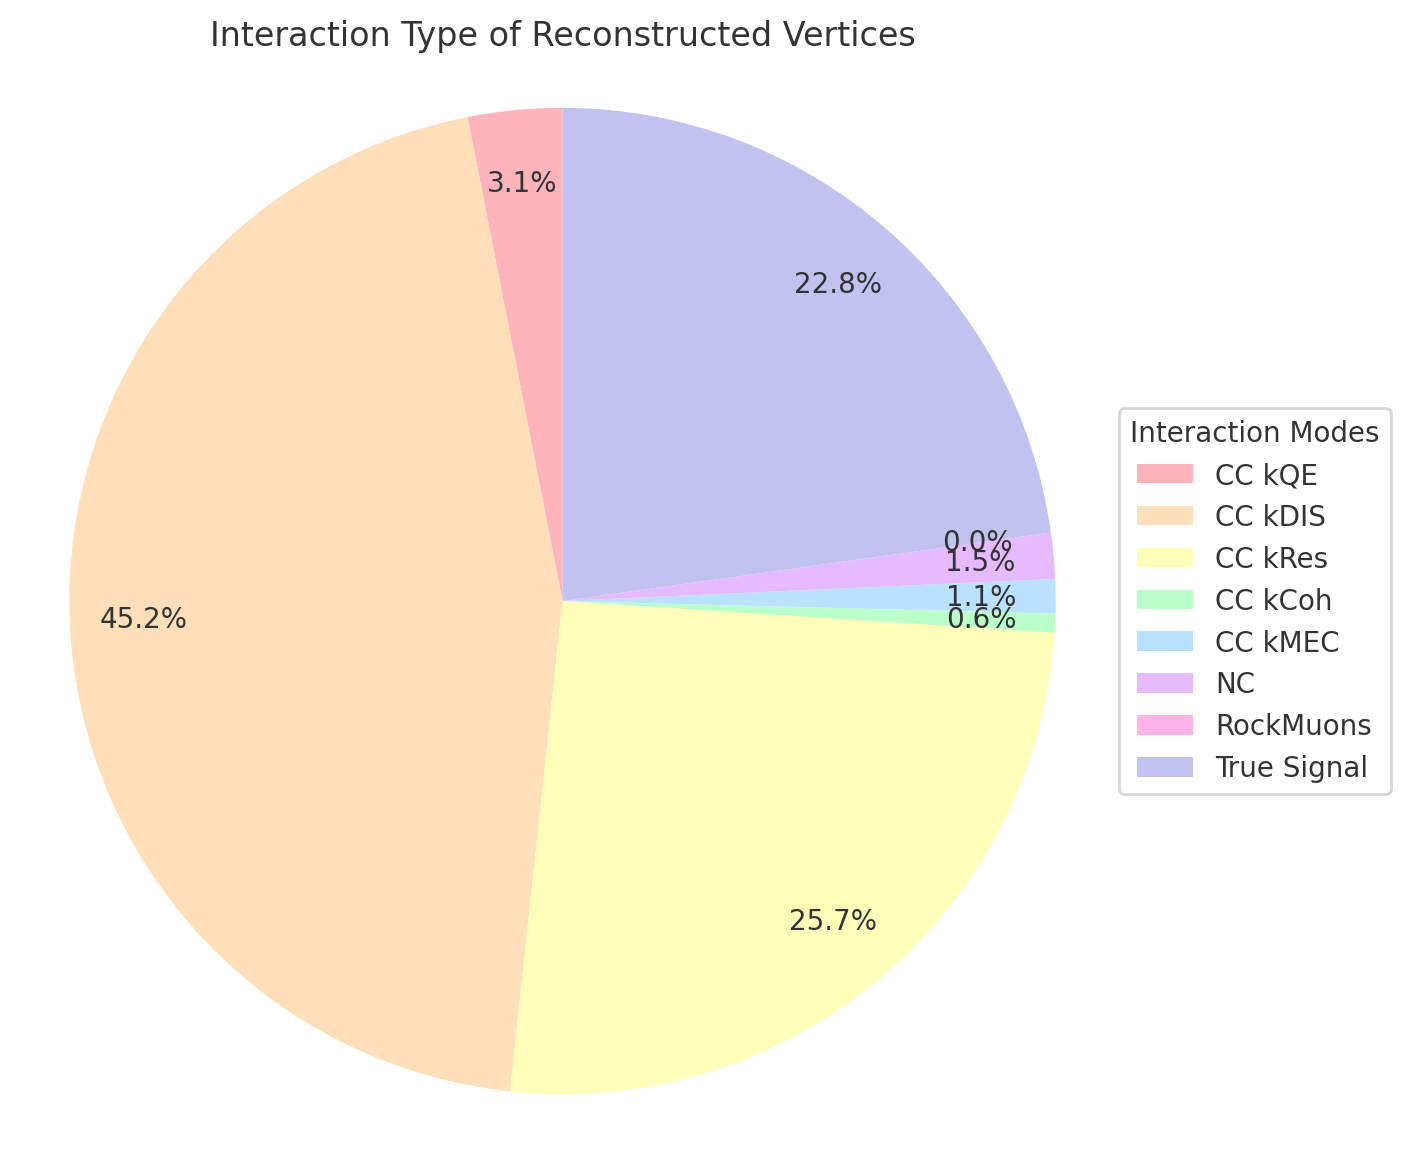

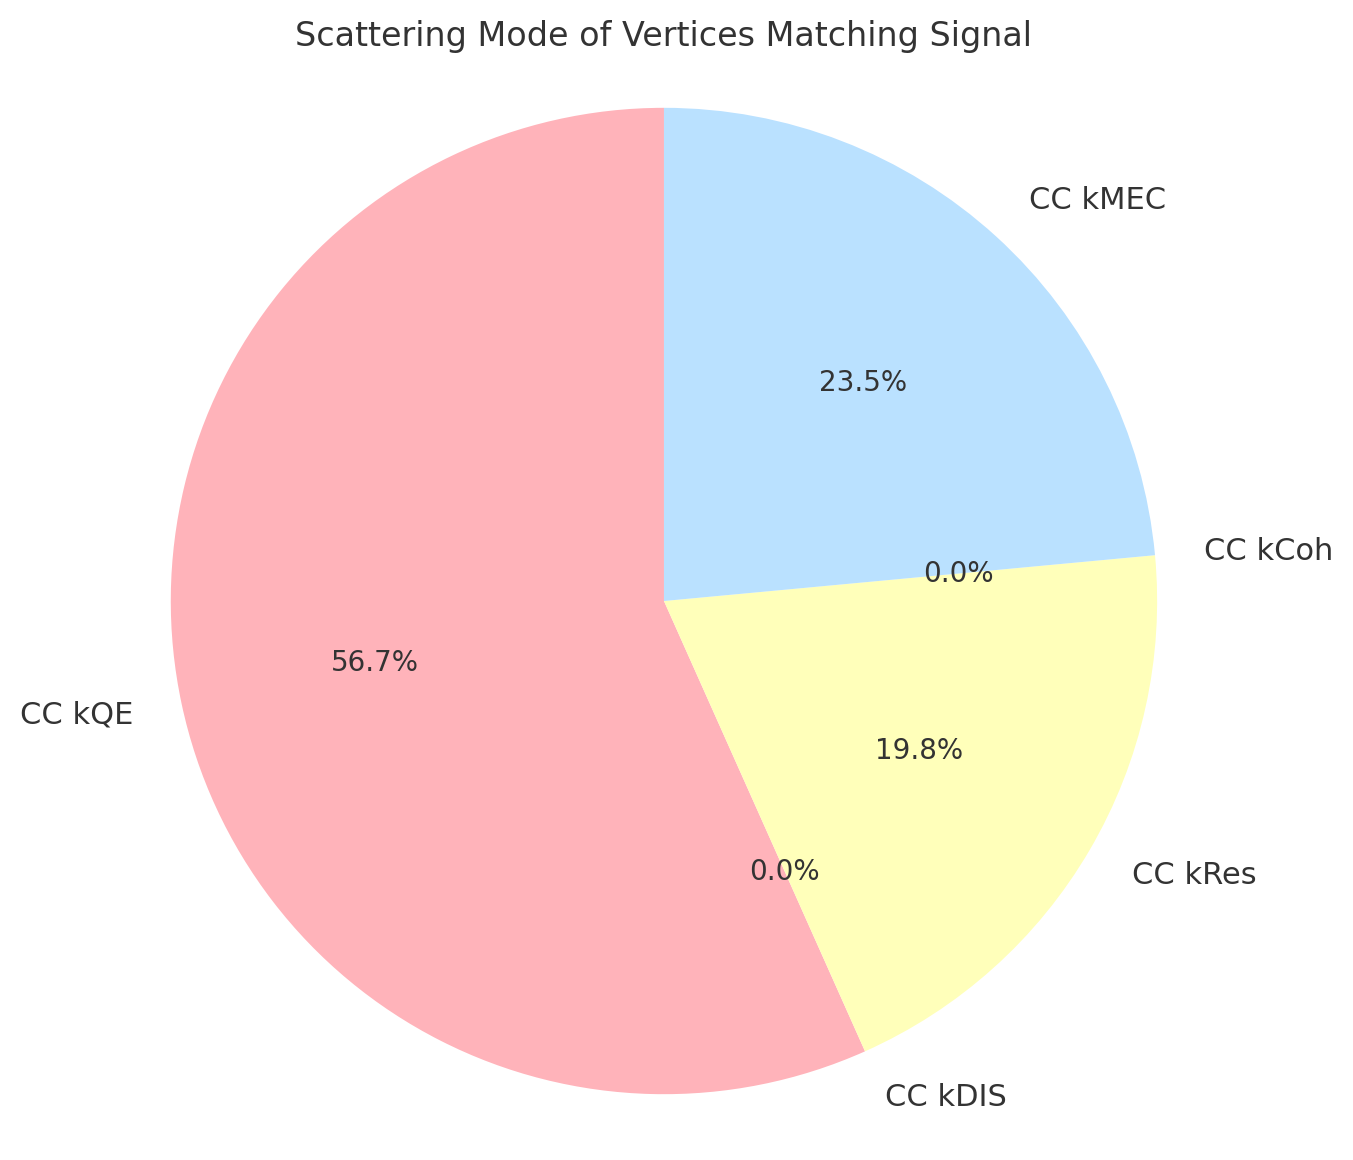

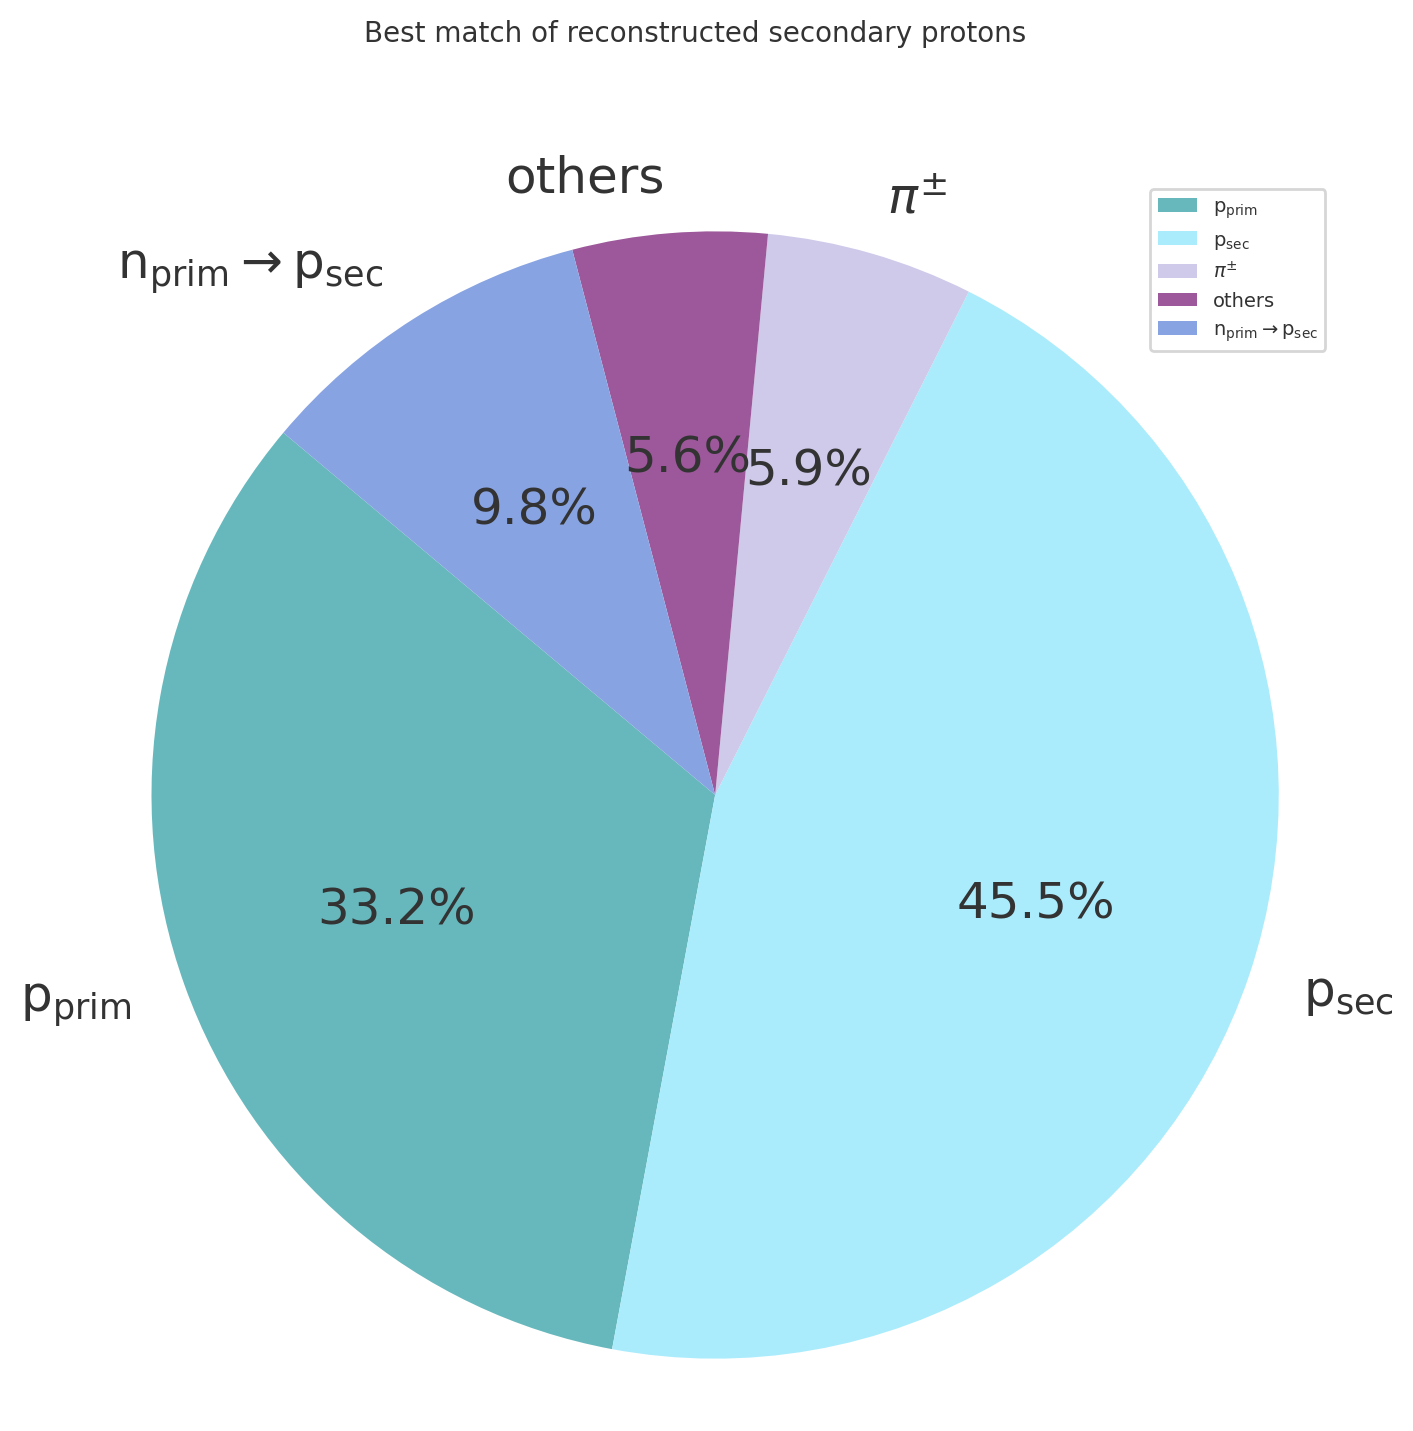

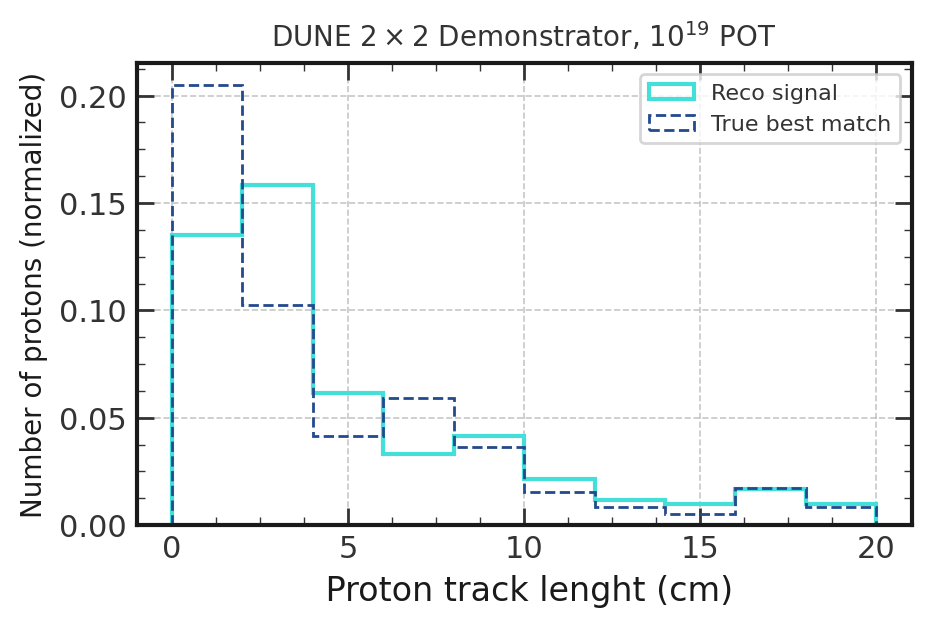

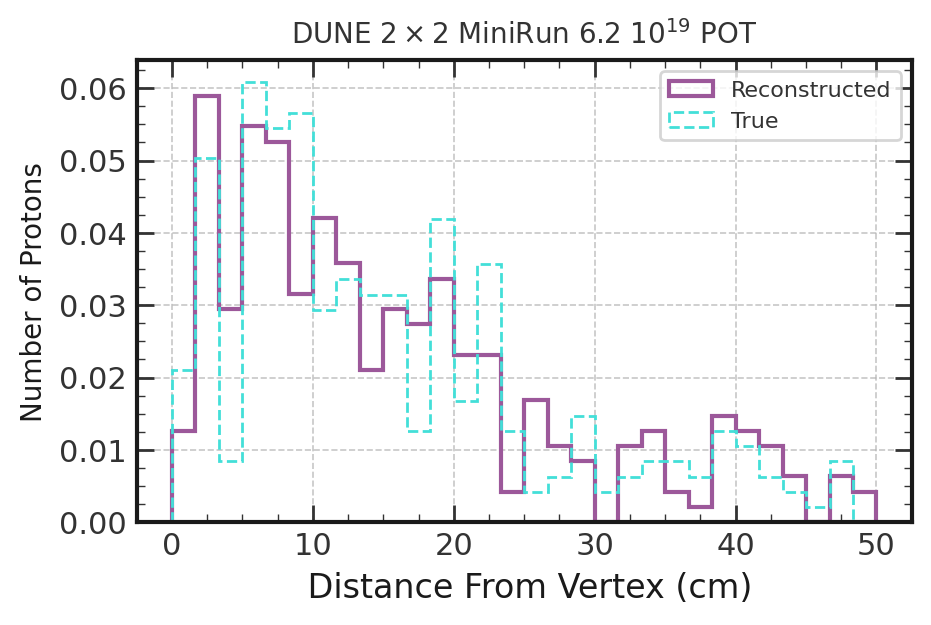

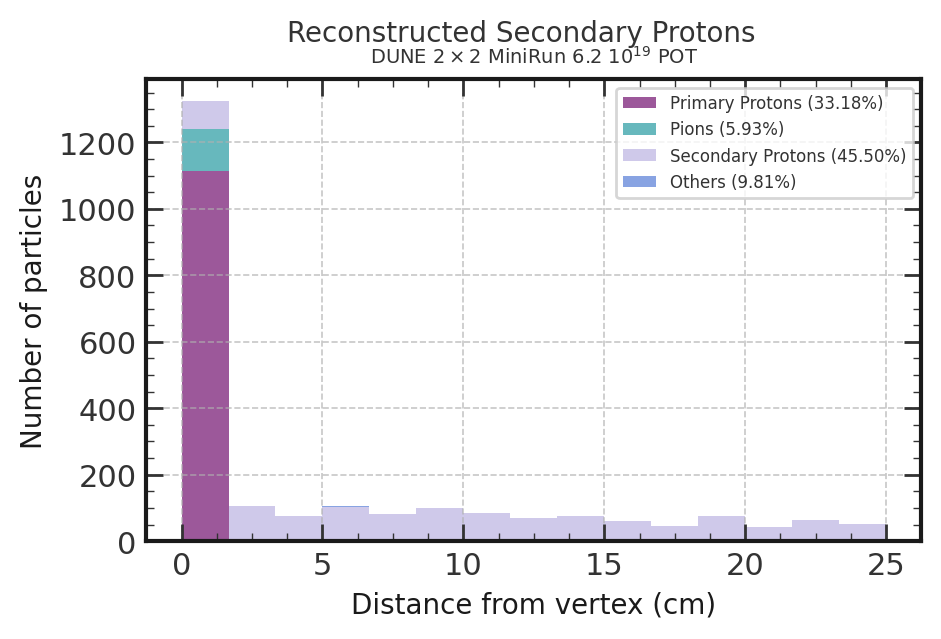

Results are saved in /global/homes/g/gkufatty/projects/neutron-multiplicity/analysis/results/neutron_analysis_Case 2_2025-03-25.pdf
All case results saved successfully at /global/homes/g/gkufatty/projects/neutron-multiplicity/analysis/results/Case 2.


In [7]:
results_2 = [] # List to store the results for each mode
conditions ={
   # 'Case 0':[False, False,'nocuts', 0,0], 'Case 1':[False, False,'FV', 0,0] , 
    'Case 2':[False, False,'mx2', 0,0] #, 'Case 3':[False, False,'mx2', 0,0] , 
    #'Case 6':[True, False,'mx2', 0,0],'Case 7':[True, True,'mx2', 0,0] #, 'Case 5':[True, False,'mx2', 0,0]
}

num_prim=[]
num_sec=[]

num_true_prim=[]
num_true_sec=[]
  

for case,condition in conditions.items():
    
    analysis = NeutrinoAnalysis()
    pdg_tab = ParticleCode()

    ixn_dict= {
        'file_number': [], 'event_number': [], 'ixn_number': [], 'true_ixn_number': [], 'cc': [], 'nprim': [], 'nsec': [], 'nneutron': [], 'nproton': [],
        'npip': [], 'npim': [], 'npi0': [], 'mode': [], 'match': [], 'nprim_reco':[], 'nsec_reco': [],  'prim_pdgs_vtx':[], 'sec_pdgs_vtx':[],
        'prim_bm_type':[], 'sec_bm_type':[], 'prim_bm_pdg':[], 'sec_bm_pdg':[], 'prim_E_vtx':[]
    }

    reco_proton_dic = {
        'best_match_idx': [] , 'best_match_pdg': [], 'best_match_type': [], 'best_match_length':[], 'best_match_distance':[],'best_match_energy':[], 
        'reco_distance':[], 'reco_energy':[], 'reco_length':[],'parent_id' :[],'vtx_t': [], 'vtx_r': [],'ev': []
    }

    sample_dic = {
        'best_match_idx': [] , 'best_match_pdg': [], 'best_match_type': [], 'best_match_length':[], 'best_match_distance':[],'best_match_energy':[], 
        'reco_distance':[], 'reco_energy':[], 'reco_length':[],'parent_id' :[],'vtx_t': [], 'vtx_r': [],'ev': []
    }

    prim_dic = {'E': []}
    sec_dic = {'E': [], 'pdg': [], 'track_neutron': []}
    multi, single, inx,secprotons, secprotons_true  = 0, 0,0,0,0
    
    for ev in range(int(len(df))):
        ev_data = df.iloc[ev]
        neutrino_selector = NeutrinoSelection(ev_data, pdg_tab, QE_true = True, QE_reco=condition[0], exclusive=condition[1], mode= condition[2] ,proton_threshold=2)
        reco_vertices, muon_track = neutrino_selector.reco_neutrino_signal() 
        true_interactions = neutrino_selector.true_neutrino_signal()
        analysis.num_vertices += np.sum(reco_vertices)
        analysis.num_interactions += np.sum(true_interactions)
        
        for vtx_index, value in enumerate(reco_vertices): 
            if value:  
                match, best_match_idx, match_vertices_signal = neutrino_selector.matching(vtx_index)
                if best_match_idx is not None:
                    neutrino_selector.save_inx_info(vtx_index)
                    #get inx and vtx data  
                    true_data = caf_reader.get_true_ixn_data(ev_data, best_match_idx)
                    reco_data = caf_reader.get_reco_ixn_data(ev_data, vtx_index)
                    neutron_selector = NeutronSelection( pdg_tab,ev_data, vtx_index, reco_data, muon_track, tpc_dist = 5, radius=condition[3], cyl=condition[4])
                    reco_dic = neutron_selector.part_scanner()
                    num_recoprotons = len(reco_dic['best_match_type'])
                    
                    for index in range(num_recoprotons):
                        bm_ixn=reco_dic['best_match_ixn'][index]
                        bm_type=reco_dic['best_match_type'][index]
                        bm_idx=reco_dic['best_match_idx'][index]
                        parent_id = reco_dic['parent_id'][index]
                        reco_energy=reco_dic['energy'][index]
                        track_length=reco_dic['length'][index]
                        vtx_distance=reco_dic['distance'][index]
                        bm_truth_data = caf_reader.get_true_ixn_data(ev_data, bm_ixn)
                        bm_dic = neutron_selector.get_bm_truth_data(bm_truth_data,bm_type, bm_idx)
                        #save the bm true info
                        reco_proton_dic['best_match_pdg'].append(bm_dic['pdg'])
                        reco_proton_dic['best_match_type'].append(bm_dic['type'])
                        reco_proton_dic['best_match_energy'].append(bm_dic['energy'])
                        reco_proton_dic['best_match_length'].append(bm_dic['length'])
                        reco_proton_dic['best_match_distance'].append(bm_dic['distance'])
                        reco_proton_dic['best_match_idx'].append(bm_idx)
                        reco_proton_dic['vtx_t'].append(bm_ixn)
                        reco_proton_dic['parent_id'].append(parent_id)
                        #reco info
                        reco_proton_dic['reco_energy'].append(reco_energy)
                        reco_proton_dic['reco_length'].append(track_length)
                        reco_proton_dic['reco_distance'].append(vtx_distance)
                        reco_proton_dic['vtx_r'].append(vtx_index)
                        reco_proton_dic['ev'].append(ev)
                        #filter the proton secondaries
                        if (bm_dic['pdg']==pdg_tab.proton) and (bm_type ==3): 
                            secprotons+=1
                            neutron_induced=neutron_selector.was_neutron_induced(bm_ixn, parent_id)
                            if neutron_induced:
                                sample_dic['best_match_pdg'].append(bm_dic['pdg'])
                                sample_dic['best_match_type'].append(bm_dic['type'])
                                sample_dic['best_match_energy'].append(bm_dic['energy'])
                                sample_dic['best_match_length'].append(bm_dic['length'])
                                sample_dic['best_match_distance'].append(bm_dic['distance'])
                                sample_dic['best_match_idx'].append(bm_idx)
                                sample_dic['vtx_t'].append(bm_ixn)
                                sample_dic['parent_id'].append(parent_id)
                                #reco info
                                sample_dic['reco_energy'].append(reco_energy)
                                sample_dic['reco_length'].append(track_length)
                                sample_dic['reco_distance'].append(vtx_distance)
                                sample_dic['vtx_r'].append(vtx_index)
                                sample_dic['ev'].append(ev)
                    if match: 
                        analysis.count_match_FV += 1
                        analysis.insignal_counters[ev_data['rec.mc.nu.mode'][best_match_idx]] += 1
                    else:
                        scattering_counters, current_counters = analysis.type_interaction(ev_data, best_match_idx)

        # Save interaction data
        for key in ixn_dict.keys():
            ixn_dict[key].extend(neutrino_selector.ixn_dict[key])
            
        #true neutron multiplicity for all true interactions
        for vtx_t, interaction_value in enumerate(true_interactions):
            if interaction_value:
                secprotons_true += np.sum(ev_data['rec.mc.nu.sec.pdg']==pdg_tab.proton)
                inx +=1 
                sec_dic['track_neutron'] = []
                prim_dic = neutrino_selector.particles_inx( vtx_t, 'prim', prim_dic)
                sec_dic = neutrino_selector.particles_inx(vtx_t,'sec', sec_dic)
                neutron_particle_count = Counter(sec_dic['track_neutron'])
                for count in neutron_particle_count.values():
                    if count > 1: multi += 1
                    elif count == 1: single += 1
        pdg_counter = Counter(sec_dic['pdg'])
      
    # Compute efficiency and purity
    efficiency, purity = analysis.efficiency_purity()
    # Display results
    analysis.display_summary()
    analysis.plot_interactions()
    analysis.plot_signal_interactions()
    
    # Generate the PDF with all plots of neutron selection
    global_analyzer_pdf = GlobalAnalyzer(reco_proton_dic, sample_dic, case)
    global_analyzer_pdf.particle_predictions()
    global_analyzer_pdf.plot_track_lenght()
    global_analyzer_pdf.plot_part_dis()
    pdf_filename = global_analyzer_pdf.save_pdf()
    print(f'Results are saved in {pdf_filename}')
       
    results_2.append({
        'case':f'QE:{neutrino_selector.QE_reco} - Exc:{neutrino_selector.exclusive}',
        'conditions': condition,
        'sph_radius': f' {neutron_selector.radius} cm',
        'cyl_radius': f'{neutron_selector.cyl} cm',
        'True inx':  analysis.num_interactions,
        'Reco inx':analysis.num_vertices,
        'Matched inx': analysis.count_match_FV,
        'Purity inx':  round(analysis.purity,4),
        'Efficiency inx': round(analysis.efficiency,4),
        'TrueNeutrons': len(prim_dic['E']),
        'True n-particles': len(sec_dic['E']),
        'True n-proton': pdg_counter[pdg_tab.proton],
        'True n-neutron': pdg_counter[pdg_tab.neutron],
        'True n-photon': pdg_counter[pdg_tab.photon],
        'TrueSingle': single,
        'TrueMulti': multi,
        'RecoSecProtons': len(reco_proton_dic['reco_energy']), 
        'MatchedSecProtons': secprotons,
        'Reco n-protons': len(sample_dic['reco_length']), 
        'Efficiency p': secprotons/secprotons_true,
        'Purity p': secprotons/len(reco_proton_dic['best_match_pdg']),
        'Efficiency n-p': len(sample_dic['reco_energy'])/pdg_counter[pdg_tab.proton],
        'Purity n-p': len(sample_dic['reco_energy'])/ len(reco_proton_dic['best_match_pdg'])    
    })
    # Convert the results list to a DataFrame

    reco_proton__df = pd.DataFrame(reco_proton_dic) 
    sample_dic_df = pd.DataFrame(sample_dic)
    file_name = f"/global/homes/g/gkufatty/projects/neutron-multiplicity/analysis/results/{case}"
    reco_proton__df.to_csv(f'{file_name}_reco_proton.csv', index=False)
    sample_dic_df.to_csv(f'{file_name}_sample.csv', index = False)
    
results_df = pd.DataFrame(results_2)
results_df.to_csv(f'/global/homes/g/gkufatty/projects/neutron-multiplicity/analysis/results/results.csv', index=False)
print(f"All case results saved successfully at {file_name}.")

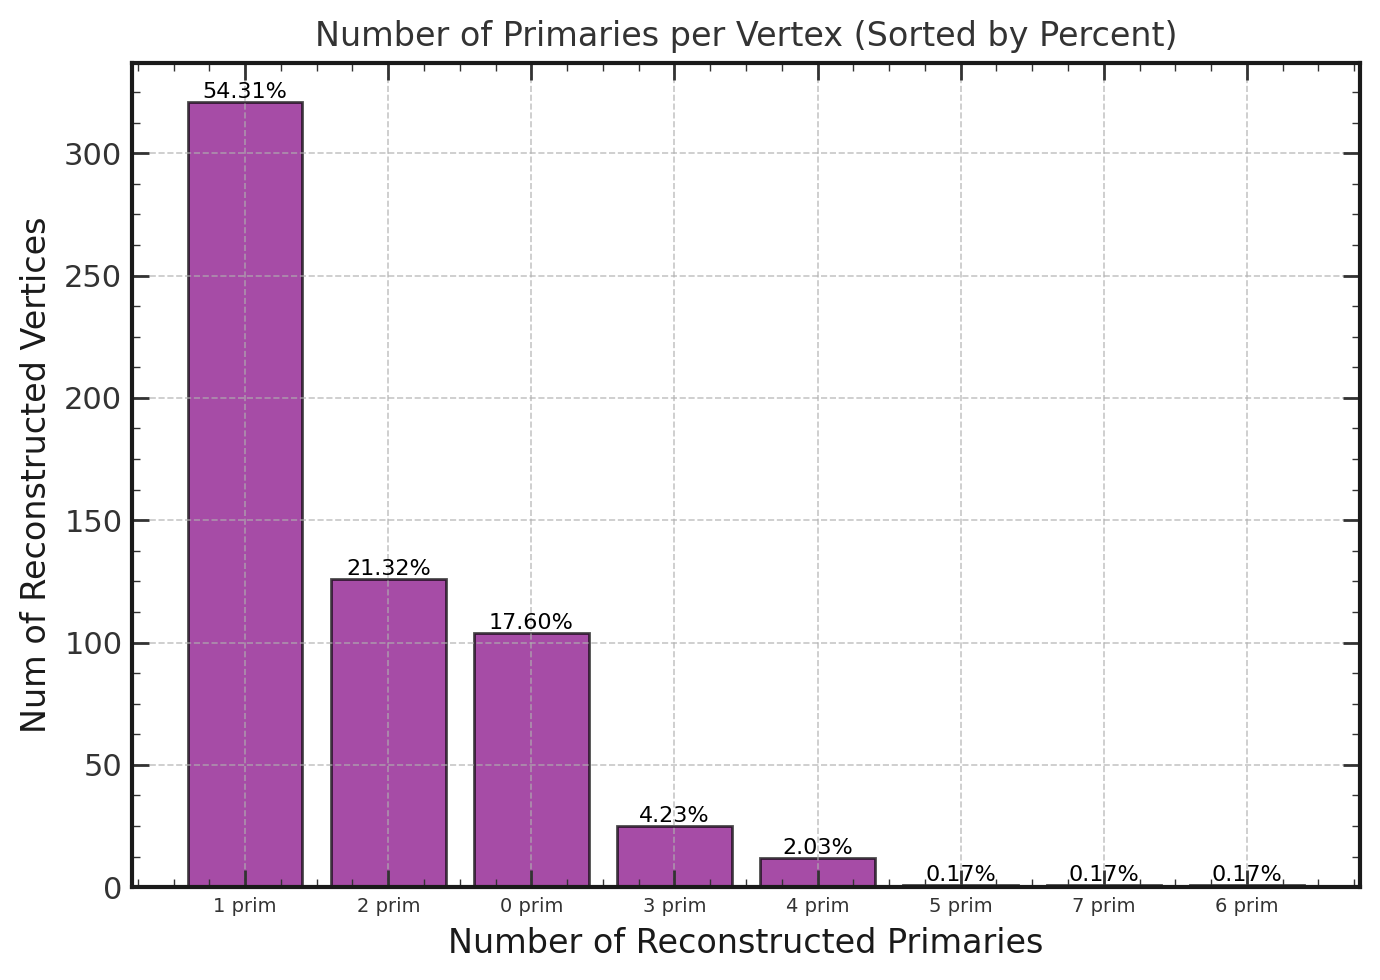

In [8]:
class StudyInteraction():
    
    def __init__(self, ixn_dict):
        self.ixn_dict = ixn_dict 
        self.matched = np.array(self.ixn_dict['match'])
        self.prim_reco = np.array(self.ixn_dict['nprim_reco'])
        self.sec_reco = np.array(self.ixn_dict['nsec_reco'])
        
    def plot_num_part(self):
        labels_prim = []
        num_prim = []
        
        prim_counter = Counter(self.prim_reco[self.matched == 1])

        total_count = sum(prim_counter.values())

        # Create list of (key, value, percentage)
        prim_data = []
        for key, value in prim_counter.items():
            percent = (value / total_count) * 100
            prim_data.append((key, value, percent))

        # Sort by percentage (descending or ascending as you prefer)
        sorted_prim_data = sorted(prim_data, key=lambda x: x[2], reverse=True)  # reverse=False for ascending

        # Now build labels and counts from sorted data
        for key, value, percent in sorted_prim_data:
            labels_prim.append(f'{key} prim')
            num_prim.append(value)

        # Plotting
        plt.figure(figsize=(7, 5))
        bars = plt.bar(labels_prim, num_prim, color='purple', alpha=0.7, edgecolor='black')

        for bar, (_, value, percent) in zip(bars, sorted_prim_data):
            plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{percent:.2f}%', 
                    ha='center', va='bottom', fontsize=8, color='black')

        plt.xlabel('Number of Reconstructed Primaries')
        plt.ylabel('Num of Reconstructed Vertices')
        plt.title('Number of Primaries per Vertex (Sorted by Percent)')
        plt.xticks(rotation=0, ha='center', fontsize=7)
        plt.tight_layout()
        plt.show()


        # labels_sec=[]
        # num_sec=[]
        # for key, value in Counter(self.sec_reco[self.matched==1]).items():
        #     labels_sec.append(str(f'{key} sec'))
        #     num_sec.append(value) 
        # plt.figure(figsize=(8, 5))
        # bars_sec = plt.bar(labels_sec, num_sec, color='purple', alpha=0.7, edgecolor='black')
        # # Add percentages on top of bars
        # total_count= np.sum(tuple(Counter(self.sec_reco[self.matched==1]).values()))
        # for bar, value in zip(bars_sec, num_sec):
        #     percent_sec = (value / total_count) * 100  # Calculate percentage
        #     plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{percent_sec:.2f}%', 
        #             ha='center', va='bottom', fontsize=8, color='black')
        # # Labels and title
        # plt.xlabel('Number of Reconstructed Secondaries')
        # plt.ylabel('Num of Reconstructed Vertices')
        # #plt.yscale('log')
        # plt.title('Number of Secondaries per Vertex')
        # plt.xticks(rotation=0, ha='center', fontsize = 7)
        # plt.tight_layout()
        # plt.show()
                
x=StudyInteraction(ixn_dict)
x.plot_num_part()

In [19]:
    # ixn_dict= {
    #     'file_number': [], 'event_number': [], 'ixn_number': [], 'true_ixn_number': [], 'cc': [], 'nprim': [], 'nsec': [], 'nneutron': [], 'nproton': [],
    #     'npip': [], 'npim': [], 'npi0': [], 'mode': [], 'match': [], 'nprim_reco':[], 'nsec_reco': [],  'prim_pdgs_vtx':[], 'sec_pdgs_vtx':[],
    #     'prim_bm_type':[], 'sec_bm_type':[], 'prim_bm_pdg':[], 'sec_bm_pdg':[], 'prim_E_vtx':[]
    # }


matched = np.array(ixn_dict['match'])
prim_reco = np.array(ixn_dict['nprim_reco'])
sec_reco = np.array(ixn_dict['nsec_reco'])
prim_pgs_reco = (np.array(ixn_dict['prim_pdgs_vtx'], dtype=object))[(matched==1)&(prim_reco==0)]
sec_pgs_reco = (np.array(ixn_dict['sec_pdgs_vtx'], dtype=object))[(matched==1)&(sec_reco==0)]
pgs_true = (np.array(ixn_dict['prim_bm_pdg'], dtype=object))[(matched==1)&(prim_reco ==0)]
event = (np.array(ixn_dict['event_number'], dtype=object))[(matched==1)&(prim_reco ==0)]
ixn = (np.array(ixn_dict['ixn_number'], dtype=object))[(matched==1)&(prim_reco ==0)]
 
len(ixn), len(event), len(pgs_true)
ixn[0], event[0]
len(prim_pgs_reco), len(sec_pgs_reco)

(sec_pgs_reco)

array([list([]), list([]), list([]), list([]), list([]), list([]),
       list([]), list([]), list([]), list([]), list([]), list([]),
       list([]), list([]), list([]), list([]), list([]), list([]),
       list([]), list([]), list([]), list([]), list([]), list([]),
       list([]), list([]), list([]), list([]), list([]), list([]),
       list([]), list([]), list([]), list([]), list([]), list([]),
       list([]), list([]), list([]), list([]), list([]), list([]),
       list([]), list([]), list([]), list([]), list([]), list([]),
       list([]), list([]), list([]), list([]), list([]), list([]),
       list([]), list([]), list([]), list([]), list([]), list([]),
       list([]), list([]), list([]), list([]), list([]), list([]),
       list([]), list([]), list([]), list([]), list([]), list([]),
       list([]), list([]), list([]), list([]), list([]), list([]),
       list([]), list([]), list([]), list([]), list([]), list([]),
       list([]), list([]), list([]), list([]), list([]), list(

In [19]:
def plot_num_part(self):
    labels_prim = []
    num_prim = []

    # Counter returns dictionary of counts {num_primaries: count}
    prim_counter = Counter(self.prim_reco[self.matched == 1])

    # Sort by the numeric key (the number of primaries)
    sorted_items = sorted(prim_counter.items(), key=lambda x: x[0])

    for key, value in sorted_items:
        labels_prim.append(f'{key} prim')  # Still use the string label for display
        num_prim.append(value)

    plt.figure(figsize=(7, 5))
    bars = plt.bar(labels_prim, num_prim, color='purple', alpha=0.7, edgecolor='black')

    total_count = sum(num_prim)
    for bar, value in zip(bars, num_prim):
        percent = (value / total_count) * 100
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{percent:.2f}%', 
                 ha='center', va='bottom', fontsize=8, color='black')

    plt.xlabel('Number of Reconstructed Primaries')
    plt.ylabel('Num of Reconstructed Vertices')
    plt.title('Number of Primaries per Vertex')
    plt.xticks(rotation=0, ha='center', fontsize=7)
    plt.tight_layout()
    plt.show()

    # Secondary particles plotting stays the same, but you can apply the same sorting logic there if needed.


In [52]:
matched = np.array(ixn_dict['match'])
prim_reco = np.array(ixn_dict['nprim_reco'])
sec_reco = np.array(ixn_dict['nsec_reco'])

true_type = np.array(ixn_dict['prim_bm_type'], dtype=object)[(matched==1)&(prim_reco ==2)]
pgs_true = (np.array(ixn_dict['prim_bm_pdg'], dtype=object))[(matched==1)&(prim_reco ==2)]
#matched reco vertices interactions with two reco prim particles
prim_pgs_reco = (np.array(ixn_dict['prim_pdgs_vtx'], dtype=object))[(matched==1)&(prim_reco==2)]

# pgs_true =[np.sort(element) for element in pgs_true]
# #pgs_true = [abs(lst) for lst in pgs_true]
# pgs_true = [tuple(lst) for lst in pgs_true]
len(pgs_true), len(prim_pgs_reco)

(464, 464)

PIDS for one primary vertices [        11         13         22        211       2112       2212
 1000010020]


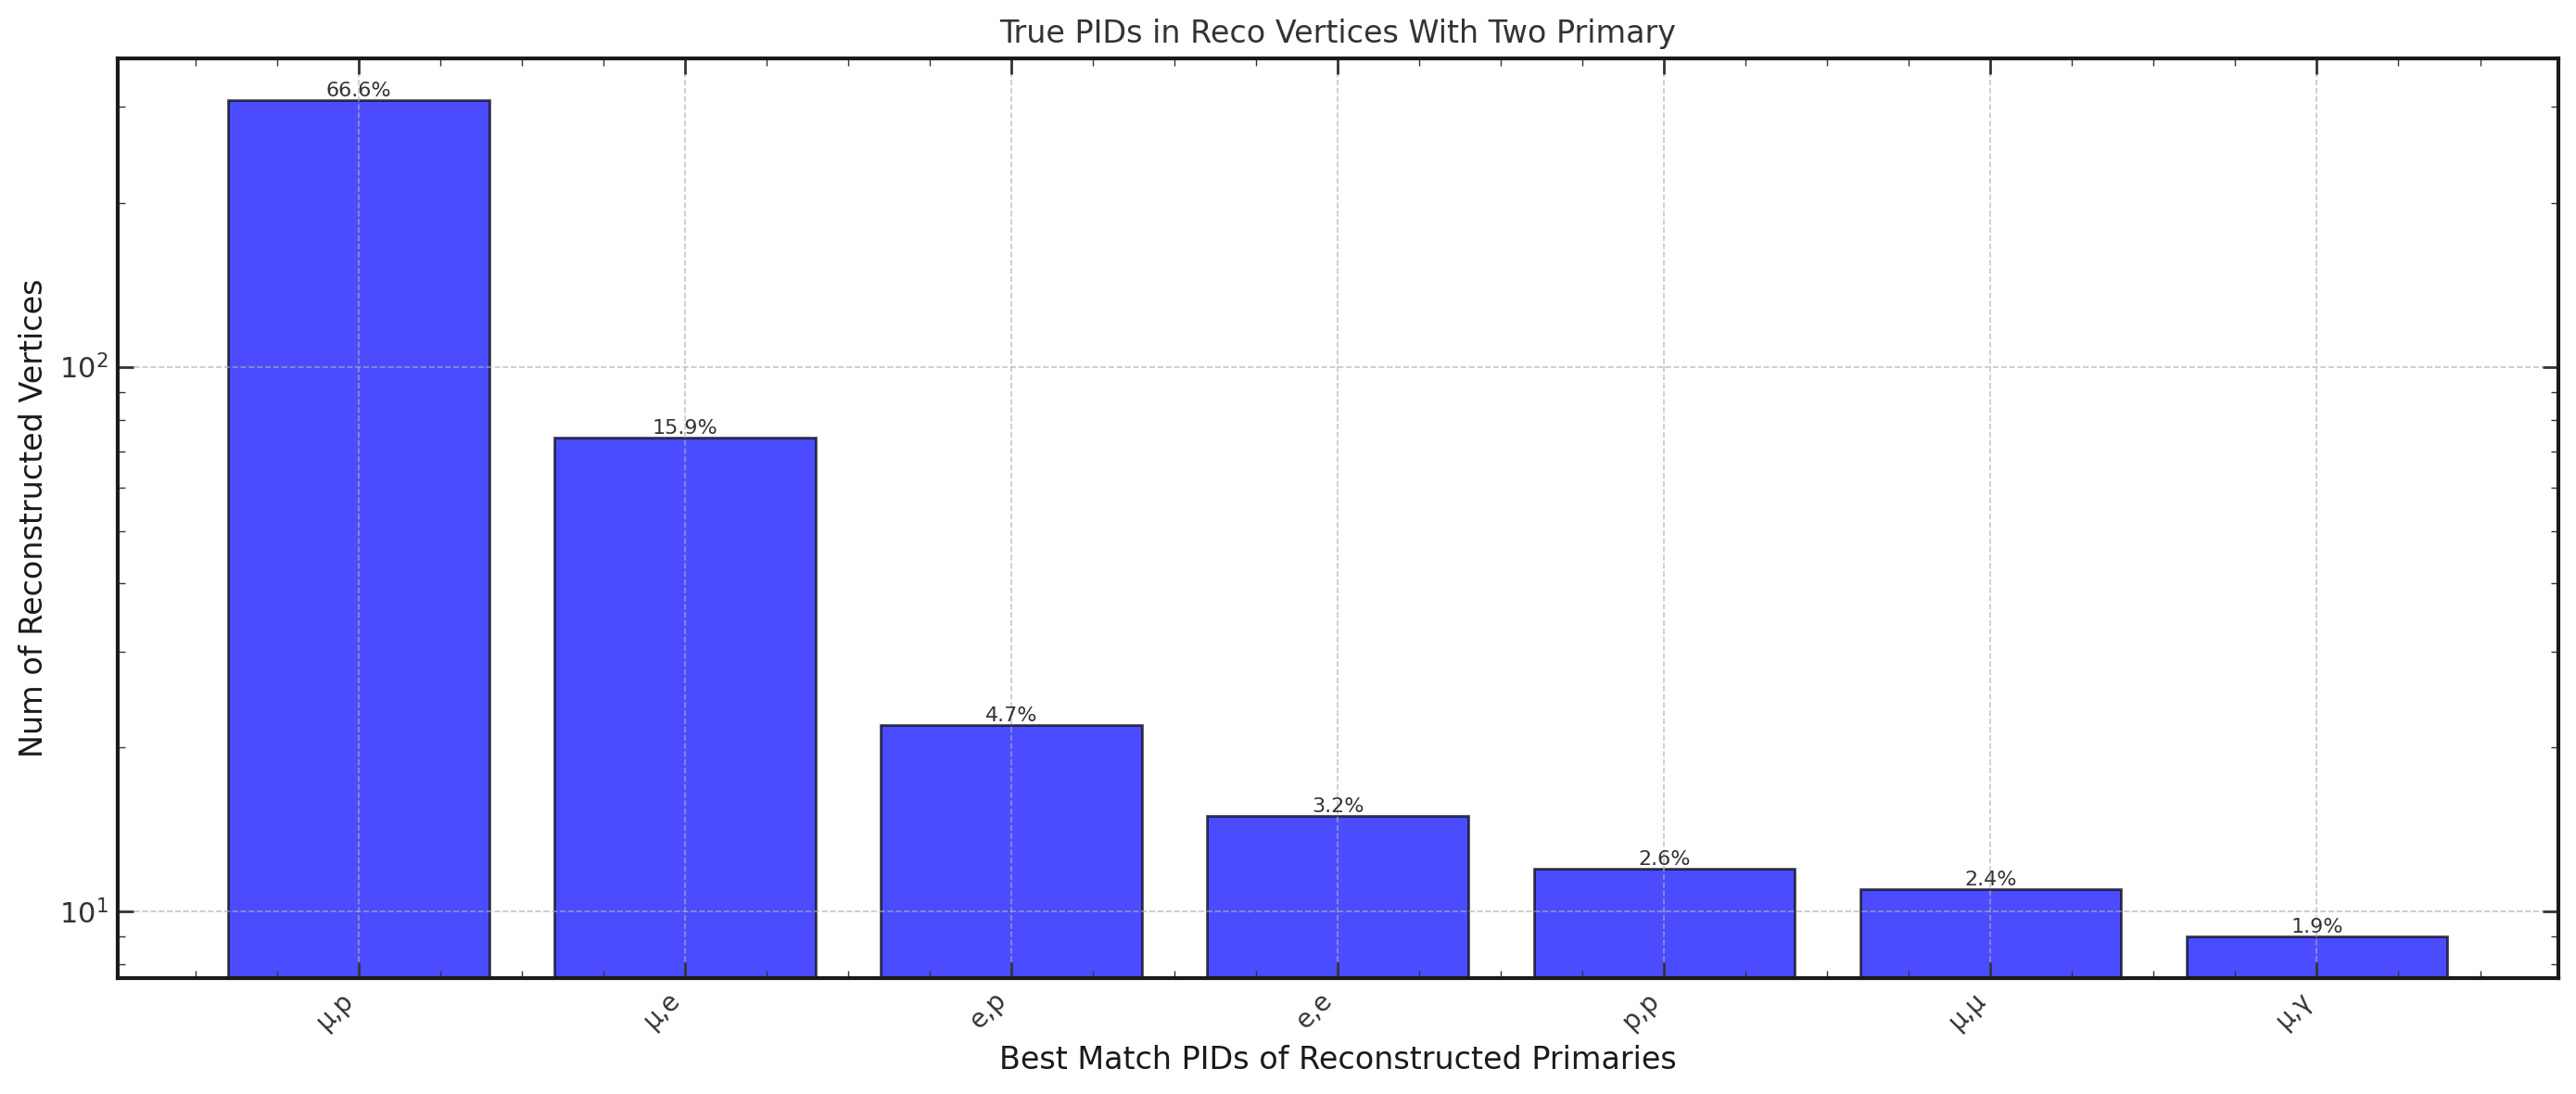

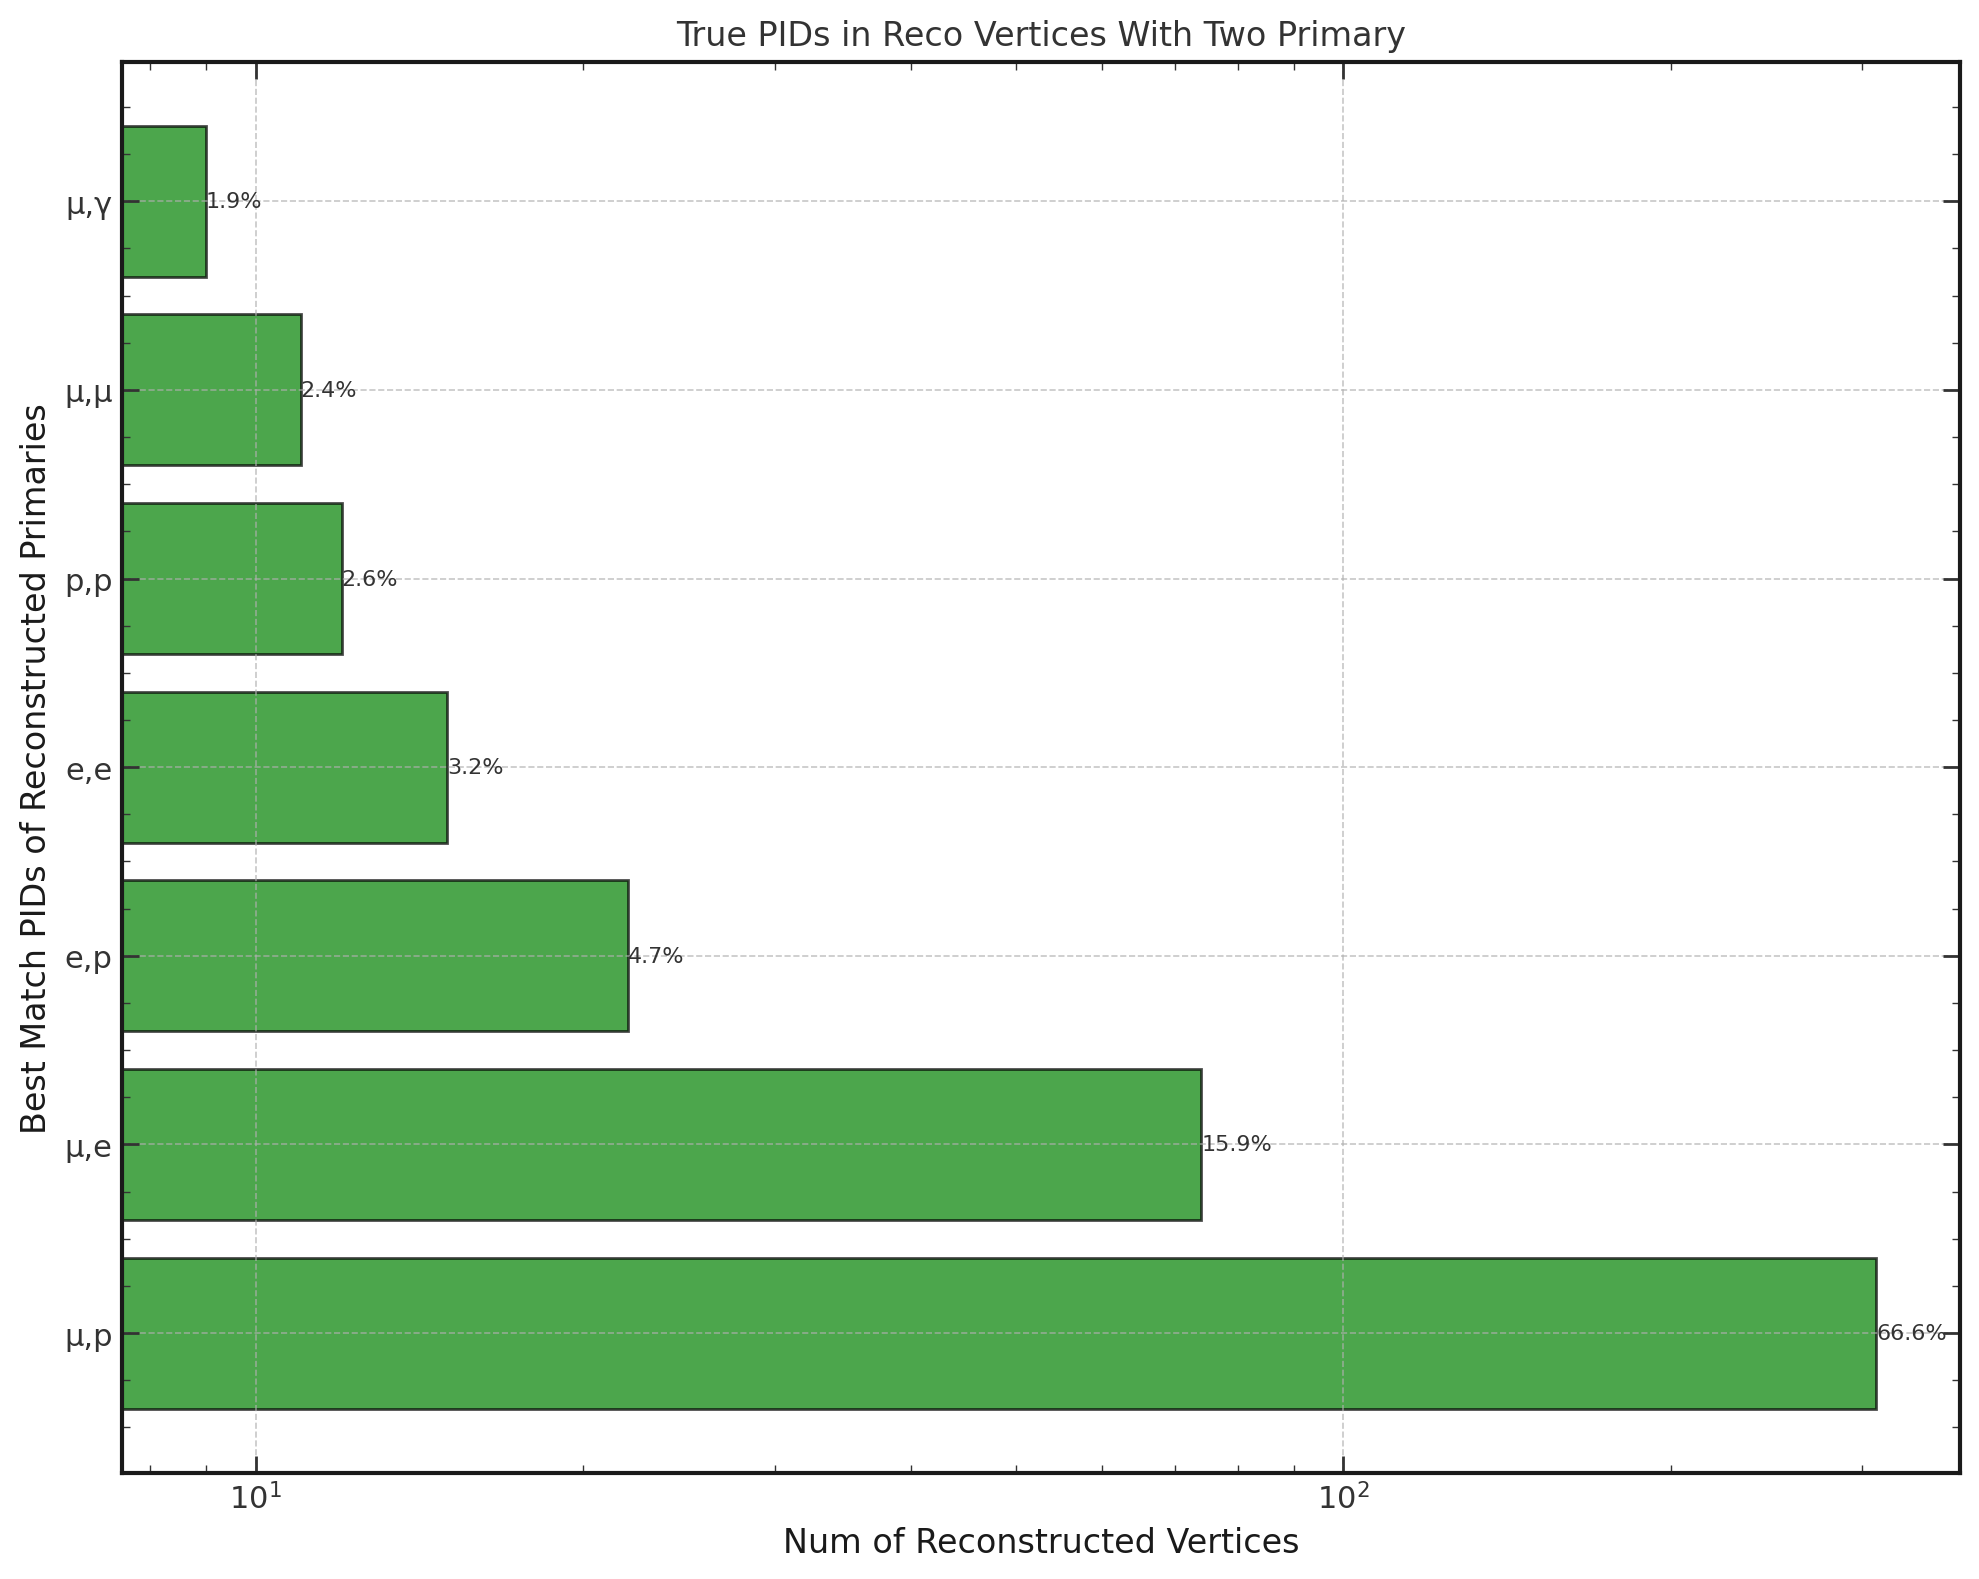

In [ ]:
matched = np.array(ixn_dict['match'])
prim_reco = np.array(ixn_dict['nprim_reco'])
sec_reco = np.array(ixn_dict['nsec_reco'])
true_type = np.array(ixn_dict['prim_bm_type'], dtype=object)[(matched==1)&(prim_reco ==2)]
pgs_true = (np.array(ixn_dict['prim_bm_pdg'], dtype=object))[(matched==1)&(prim_reco ==2)]
Energy =  (np.array(ixn_dict['prim_E_vtx'], dtype=object))[(matched==1)&(prim_reco ==2)]

# pgs_true =[np.sort(element) for element in pgs_true]
# #pgs_true = [abs(lst) for lst in pgs_true]
# pgs_true = [tuple(lst) for lst in pgs_true]

pgs_true_cleaned = []
for element in pgs_true:
    # Check if element is None
    if element is None:
        pgs_true_cleaned.append(tuple())  # or skip it with continue
        continue
    # Filter out any None values inside the iterable
    clean_element = [x for x in element if x is not None]
    # Sort and convert to tuple
    pgs_true_cleaned.append(tuple(np.sort(clean_element)))

pgs_true = pgs_true_cleaned
pgs_true = [tuple(abs(x) for x in lst) for lst in pgs_true]



# Count occurrences of each unique tuple
pids=[]
counter = Counter(pgs_true)
for i in counter.keys():
    pids.extend(i)
print(f'PIDS for one primary vertices {np.unique(pids)}')
# Safely sort, ignoring None values

# Define a mapping of PDG codes to particle names
# pdg_to_name = {
#     11: 'Electron',
#     13: 'Muon',
#     -11: 'Electron',
#     -13: 'Muon',
#     2212: 'Proton',
#     211: 'Pion',
#     321: 'Kaon',
#     22: 'Photon'
# }

pdg_to_name = {
    11: 'e',
    13: 'μ',
    2212: 'p',
    211: 'π',
    321: 'K',
    22: 'γ'
}

labels = []
num = []
for key, value in counter.items():
    # if pdg_tab.muon not in key: 
    #     continue
    # else:
    labels.append(str(key))  # Convert tuple to string for labeling
    num.append(value)
        
# Convert PDG tuples to human-readable particle names
labels_named = []
for key in labels:
    pdg_codes = eval(key)  # Convert string representation of tuple back to tuple
    named_particles = [pdg_to_name.get(pdg, f'PDG {pdg}') for pdg in pdg_codes]  # Replace PDG codes with names
    labels_named.append(",".join(named_particles))  # Create a readable label

total_count = np.sum(num)
labels_filtered = []
num_filtered = []
percent_filtered = []

for label, count in zip(labels_named, num):
    percent = (count / total_count) * 100
    if percent >= 1:
        labels_filtered.append(label)
        num_filtered.append(count)
        percent_filtered.append(percent)


sorted_data = sorted(zip(num_filtered, labels_filtered, percent_filtered), reverse=True)
num_sorted, labels_sorted, percent_sorted = zip(*sorted_data)

# === VERTICAL BAR PLOT ===
plt.figure(figsize=(14, 6))  # Wider figure for readability
bars = plt.bar(labels_sorted, num_sorted, color='blue', alpha=0.7, edgecolor='black')

# Add percentages on top of bars
for bar, percent in zip(bars, percent_sorted):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{percent:.1f}%', 
             ha='center', va='bottom', fontsize=8)

plt.xlabel('Best Match PIDs of Reconstructed Primaries')
plt.ylabel('Num of Reconstructed Vertices')
plt.yscale('log')
plt.title('True PIDs in Reco Vertices With Two Primary')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()
plt.show()

# === OPTIONAL: HORIZONTAL BAR PLOT ===
plt.figure(figsize=(10, 8))  # Taller figure for horizontal layout
bars = plt.barh(labels_sorted, num_sorted, color='green', alpha=0.7, edgecolor='black')

for bar, percent in zip(bars, percent_sorted):
    plt.text(bar.get_width(), bar.get_y() + bar.get_height() / 2, f'{percent:.1f}%', 
             va='center', fontsize=8)

plt.xlabel('Num of Reconstructed Vertices')
plt.ylabel('Best Match PIDs of Reconstructed Primaries')
plt.xscale('log')
plt.title('True PIDs in Reco Vertices With Two Primary')
plt.tight_layout()
plt.show()

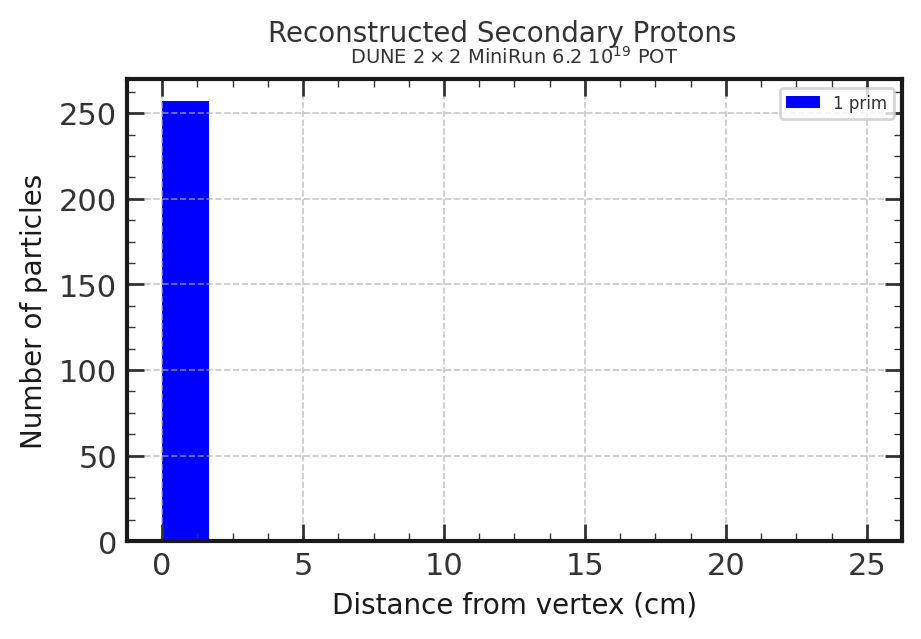

In [125]:
matched = np.array(ixn_dict['match'])
prim_reco = np.array(ixn_dict['nprim_reco'])
sec_reco = np.array(ixn_dict['nsec_reco'])
#matched reco vertices interactions with two reco prim particles
prim_pgs_reco = (np.array(ixn_dict['prim_pdgs_vtx'], dtype=object))[(matched==1)&(prim_reco==2)]
true_type = np.array(ixn_dict['prim_bm_type'], dtype=object)[(matched==1)&(prim_reco ==2)]
pgs_true = (np.array(ixn_dict['prim_bm_pdg'], dtype=object))[(matched==1)&(prim_reco ==2)]
Energy =  (np.array(ixn_dict['prim_E_vtx'], dtype=object))[(matched==1)&(prim_reco ==2)]

Energy_protons=[]
# Iterate over vertices
for reco_pdgs, energy_list in zip(prim_pgs_reco, Energy):
    # Iterate over particles in each vertex
    for pdg, energy in zip(reco_pdgs, energy_list):
        if pdg == pdg_tab.proton:
            Energy_protons.append(energy)

Energy_protons = np.array(Energy_protons)
Energy_protons = [E for E in Energy_protons]
# Display proton energies

plt.hist(
    Energy_protons,
    bins=15,
    stacked=True,
    range=[0, 25],
    label=labels[:len(Energy_protons)],  # Match labels to dataset size
    color='blue'
)

plt.xlabel('Distance from vertex (cm)', fontsize=10)
plt.ylabel('Number of particles', fontsize=10)
plt.title(r'DUNE $2\times 2$ MiniRun 6.2 $10^{19}$ POT', fontsize=7)
plt.suptitle('Reconstructed Secondary Protons', fontsize=10)
plt.legend(loc='upper right', fontsize=6)
plt.show()


True Type for one primary vertices: [1 3]


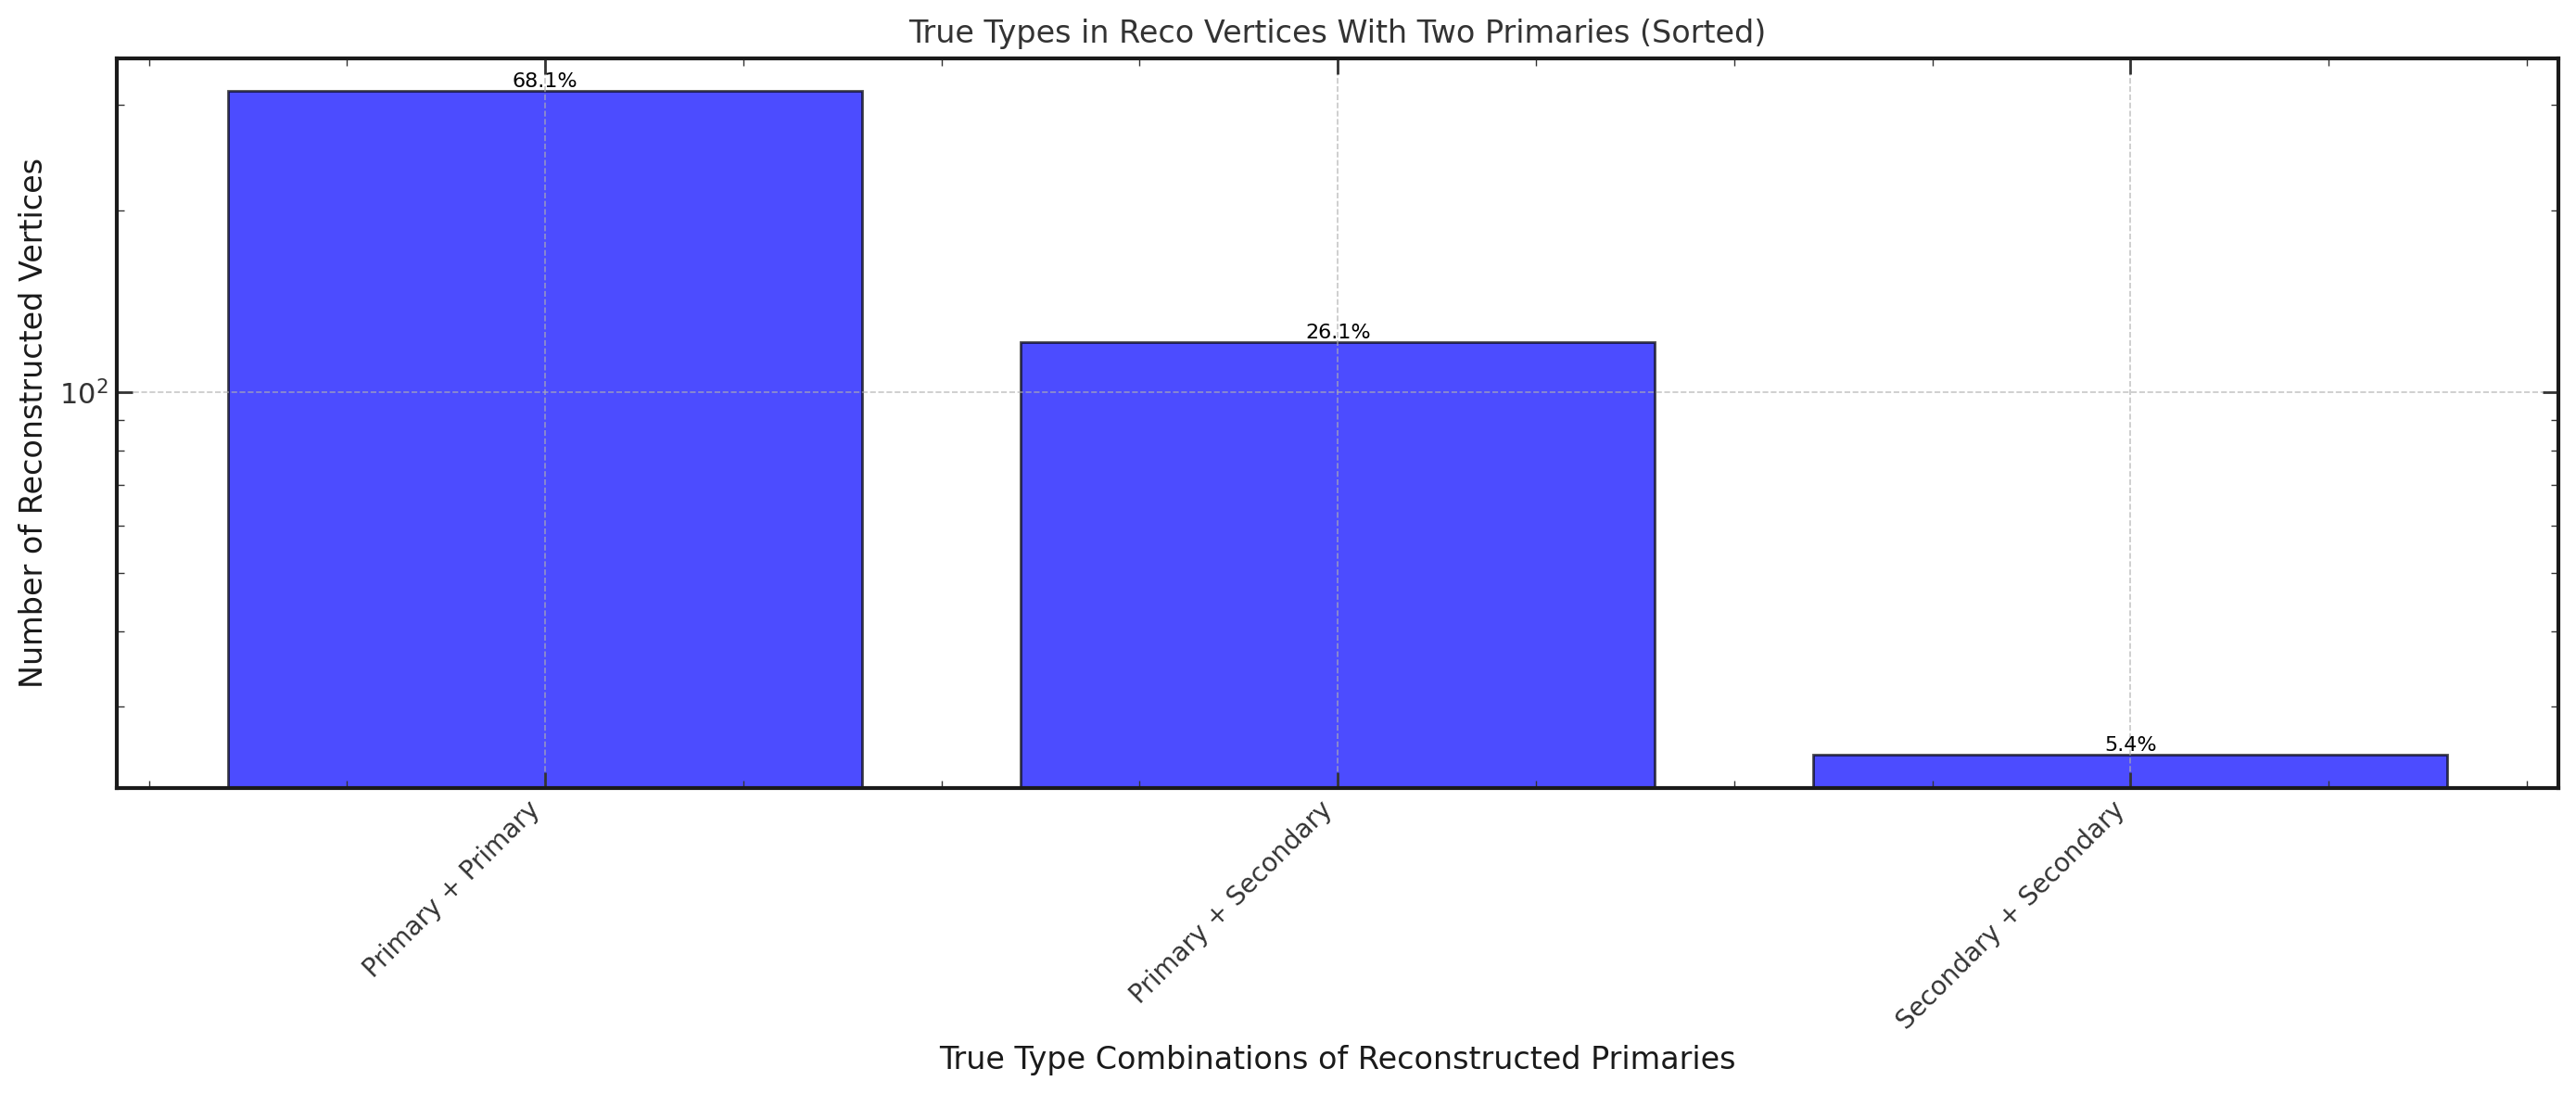

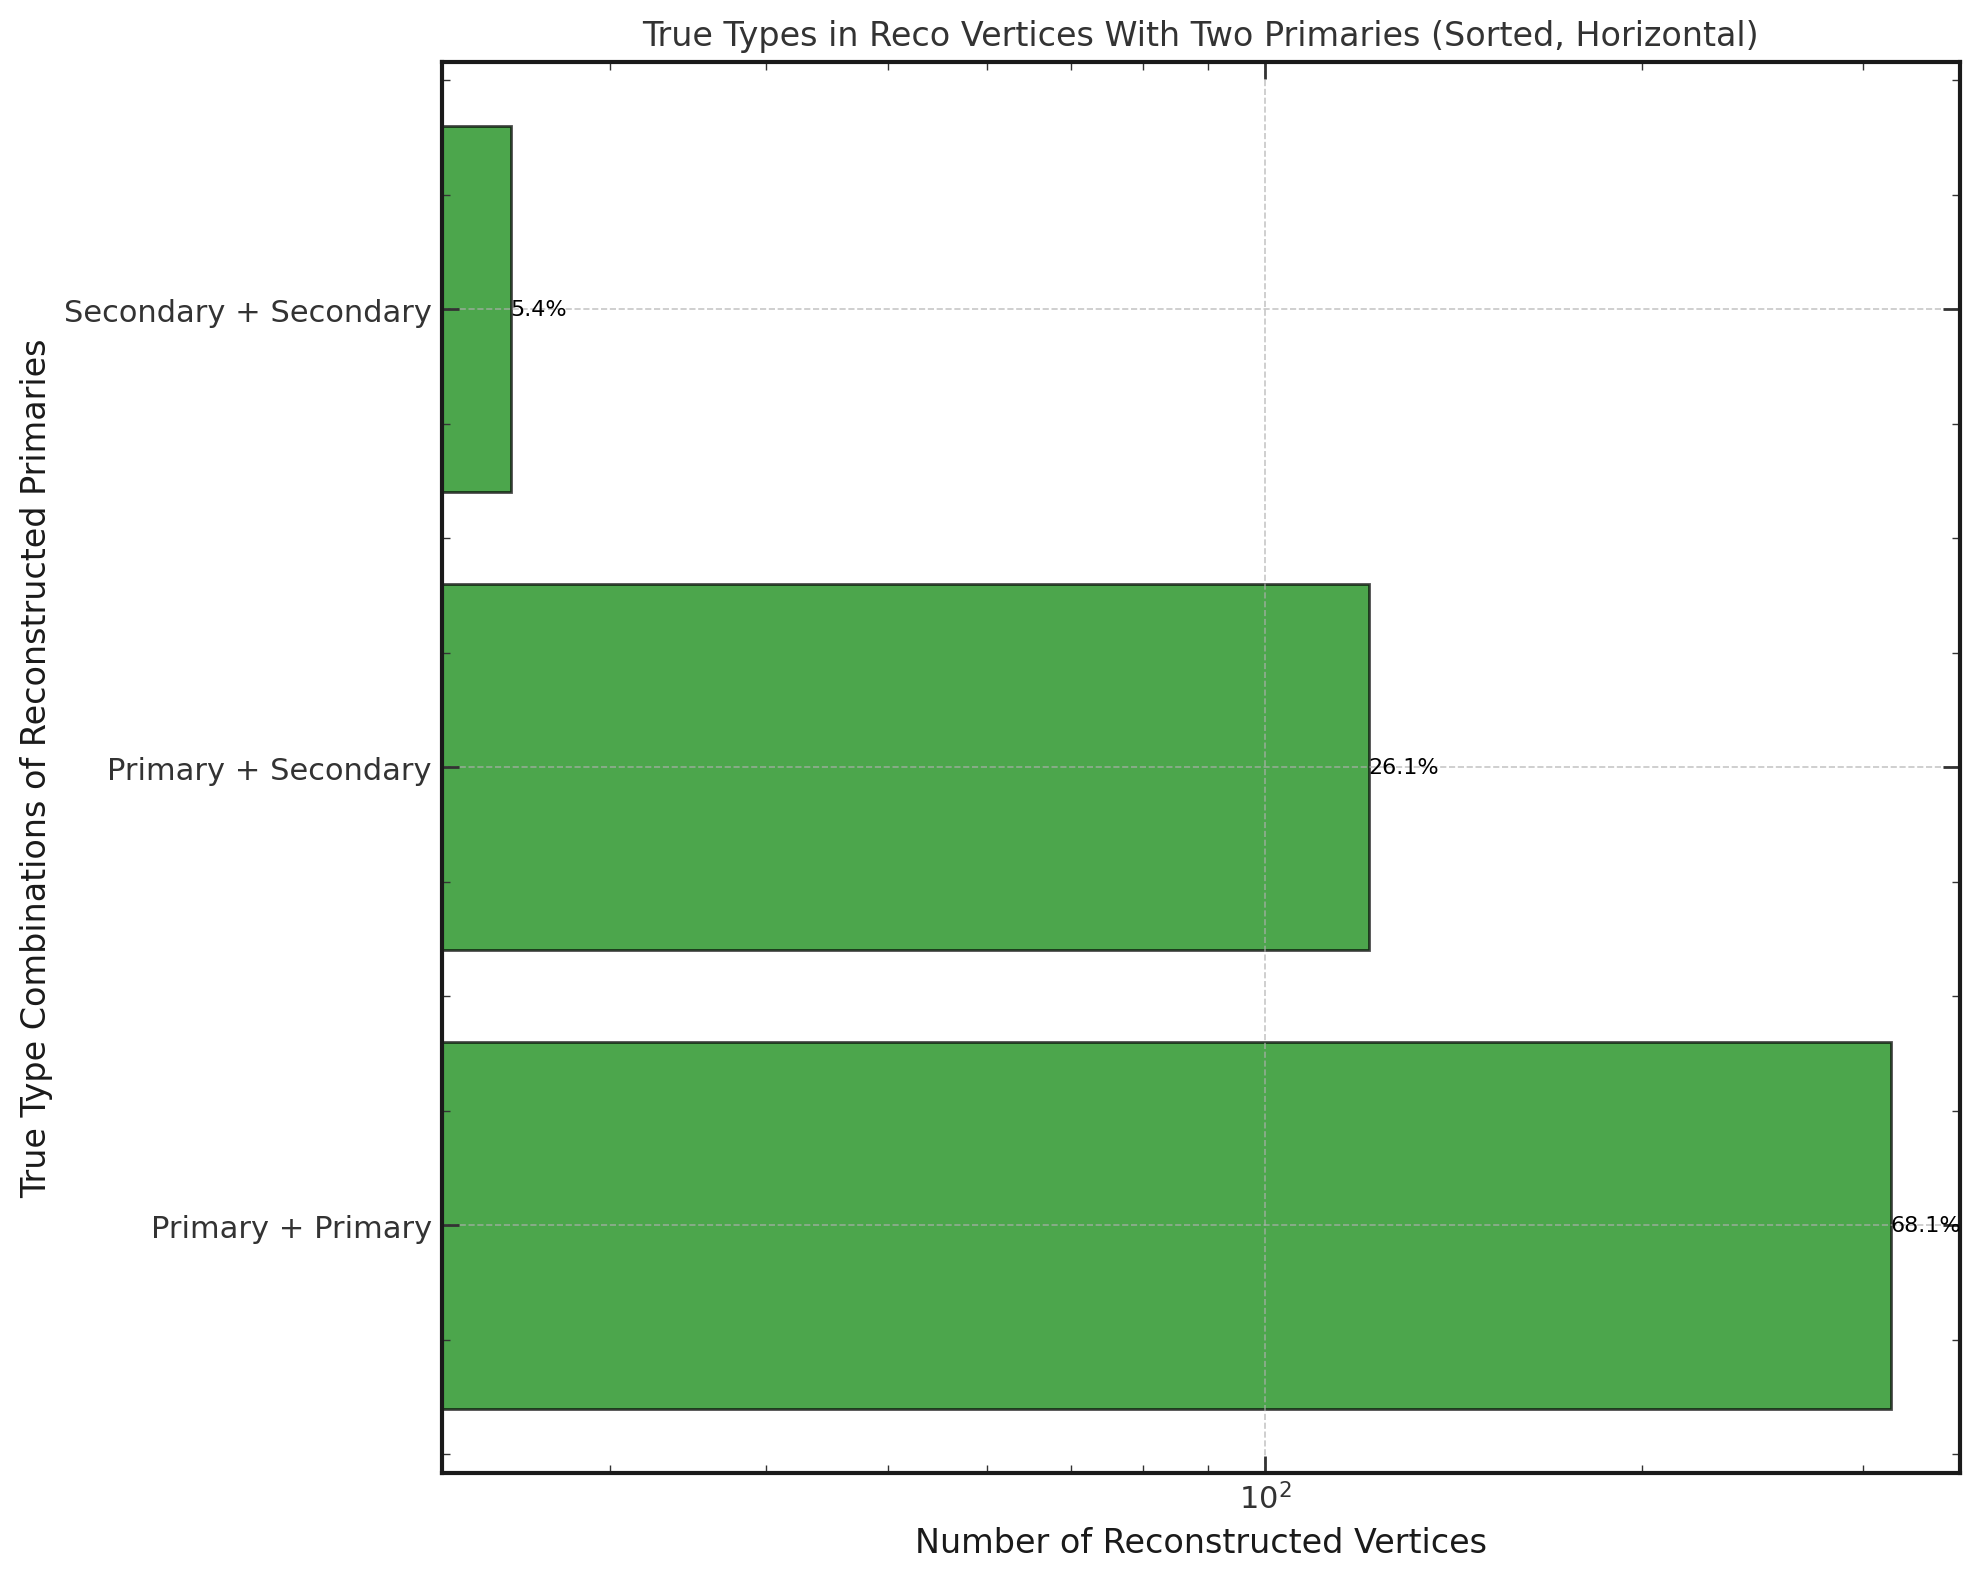

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Example selection logic based on ixn_dict (replace with your actual data)
matched = np.array(ixn_dict['match'])
prim_reco = np.array(ixn_dict['nprim_reco'])
sec_reco = np.array(ixn_dict['nsec_reco'])

# Filtered arrays
true_type = np.array(ixn_dict['prim_bm_type'], dtype=object)[(matched == 1) & (prim_reco == 2)]
pgs_true = np.array(ixn_dict['prim_bm_pdg'], dtype=object)[(matched == 1) & (prim_reco == 2)]

# Process true_type: sort elements, convert to tuples for counting
true_type_sorted = []
for element in true_type:
    if element is None:
        continue
    clean_element = [x for x in element if x is not None]
    true_type_sorted.append(tuple(np.sort(clean_element)))

# Count occurrences of each unique tuple
counter = Counter(true_type_sorted)

# Collect all PDG codes for listing unique values
pids = []
for key in counter.keys():
    pids.extend(key)
print(f'True Type for one primary vertices: {np.unique(pids)}')

# Define a mapping of Type codes to particle types
pdg_to_name = {
    1: 'Primary',
    3: 'Secondary',
}

# Create lists of labels and counts
labels = []
num = []
for key, value in counter.items():
    labels.append(str(key))  # Convert tuple to string for labeling
    num.append(value)

# Convert Type tuples to human-readable names
labels_named = []
for key in labels:
    type_codes = eval(key)  # Convert string representation of tuple back to tuple
    named_types = [pdg_to_name.get(code, f'Type {code}') for code in type_codes]
    labels_named.append(" + ".join(named_types))  # Join the names

# ===============================
# ✅ Filter out values below 1%
# ===============================
total_count = np.sum(num)
labels_filtered = []
num_filtered = []
percent_filtered = []

for label, count in zip(labels_named, num):
    percent = (count / total_count) * 100
    if percent >= 1:
        labels_filtered.append(label)
        num_filtered.append(count)
        percent_filtered.append(percent)

# ===============================
# ✅ Sort by descending count
# ===============================
sorted_data = sorted(zip(num_filtered, labels_filtered, percent_filtered), reverse=True)
num_sorted, labels_sorted, percent_sorted = zip(*sorted_data)

# === VERTICAL BAR PLOT ===
plt.figure(figsize=(14, 6))  # Wider figure for readability
bars = plt.bar(labels_sorted, num_sorted, color='blue', alpha=0.7, edgecolor='black')



labels=[]
num=[]
for key, value in Counter(prim_reco[matched==1]).items():
    labels.append(str(f'{key} prim'))
    num.append(value)

# Plot histogram with updated labels
plt.figure(figsize=(7, 5))
bars = plt.bar(labels, num, color='purple', alpha=0.7, edgecolor='black')

# # Add percentages on top of bars
total_count= np.sum(tuple(Counter(prim_reco[matched==1]).values()))
for bar, value in zip(bars, num):
    percent = (value / total_count) * 100  # Calculate percentage
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{percent:.2f}%', 
             ha='center', va='bottom', fontsize=8, color='black')

# Labels and title
plt.xlabel('Number of Reconstructed Primaries')
plt.ylabel('Num of Reconstructed Vertices')
plt.yscale('log')
plt.title('Number of Primaries per Vertex')
plt.xticks(rotation=0, ha='center', fontsize = 7)
plt.tight_layout()
plt.show()

labels2=[]
num2=[]
for key, value in Counter(sec_reco[matched==1]).items():
    labels2.append(str(f'{key} sec'))
    num2.append(value)

# Plot histogram with updated labels
plt.figure(figsize=(8, 5))
bars2 = plt.bar(labels2, num2, color='purple', alpha=0.7, edgecolor='black')

# # Add percentages on top of bars
total_count= np.sum(tuple(Counter(sec_reco[matched==1]).values()))
for bar2, value in zip(bars2, num2):
    percent = (value / total_count) * 100  # Calculate percentage
    plt.text(bar2.get_x() + bar2.get_width() / 2, bar2.get_height(), f'{percent:.2f}%', 
             ha='center', va='bottom', fontsize=8, color='black')

# Labels and title
plt.xlabel('Number of Reconstructed Secondaries')
plt.ylabel('Num of Reconstructed Vertices')
plt.yscale('log')
plt.title('Number of Secondaries per Vertex')
plt.xticks(rotation=0, ha='center', fontsize = 7)
plt.tight_layout()
plt.show()

# Add percentages on top of bars
for bar, percent in zip(bars, percent_sorted):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{percent:.1f}%', 
             ha='center', va='bottom', fontsize=8, color='black')

# Labels and title
plt.xlabel('True Type Combinations of Reconstructed Primaries')
plt.ylabel('Number of Reconstructed Vertices')
plt.yscale('log')
plt.title('True Types in Reco Vertices With Two Primaries (Sorted)')
plt.xticks(rotation=45, ha='right', fontsize=10)

plt.tight_layout()
plt.show()

# === OPTIONAL: HORIZONTAL BAR PLOT ===
plt.figure(figsize=(10, 8))
bars = plt.barh(labels_sorted, num_sorted, color='green', alpha=0.7, edgecolor='black')

for bar, percent in zip(bars, percent_sorted):
    plt.text(bar.get_width(), bar.get_y() + bar.get_height() / 2, f'{percent:.1f}%', 
             va='center', fontsize=8, color='black')

plt.xlabel('Number of Reconstructed Vertices')
plt.ylabel('True Type Combinations of Reconstructed Primaries')
plt.xscale('log')
plt.title('True Types in Reco Vertices With Two Primaries (Sorted, Horizontal)')
plt.tight_layout()
plt.show()


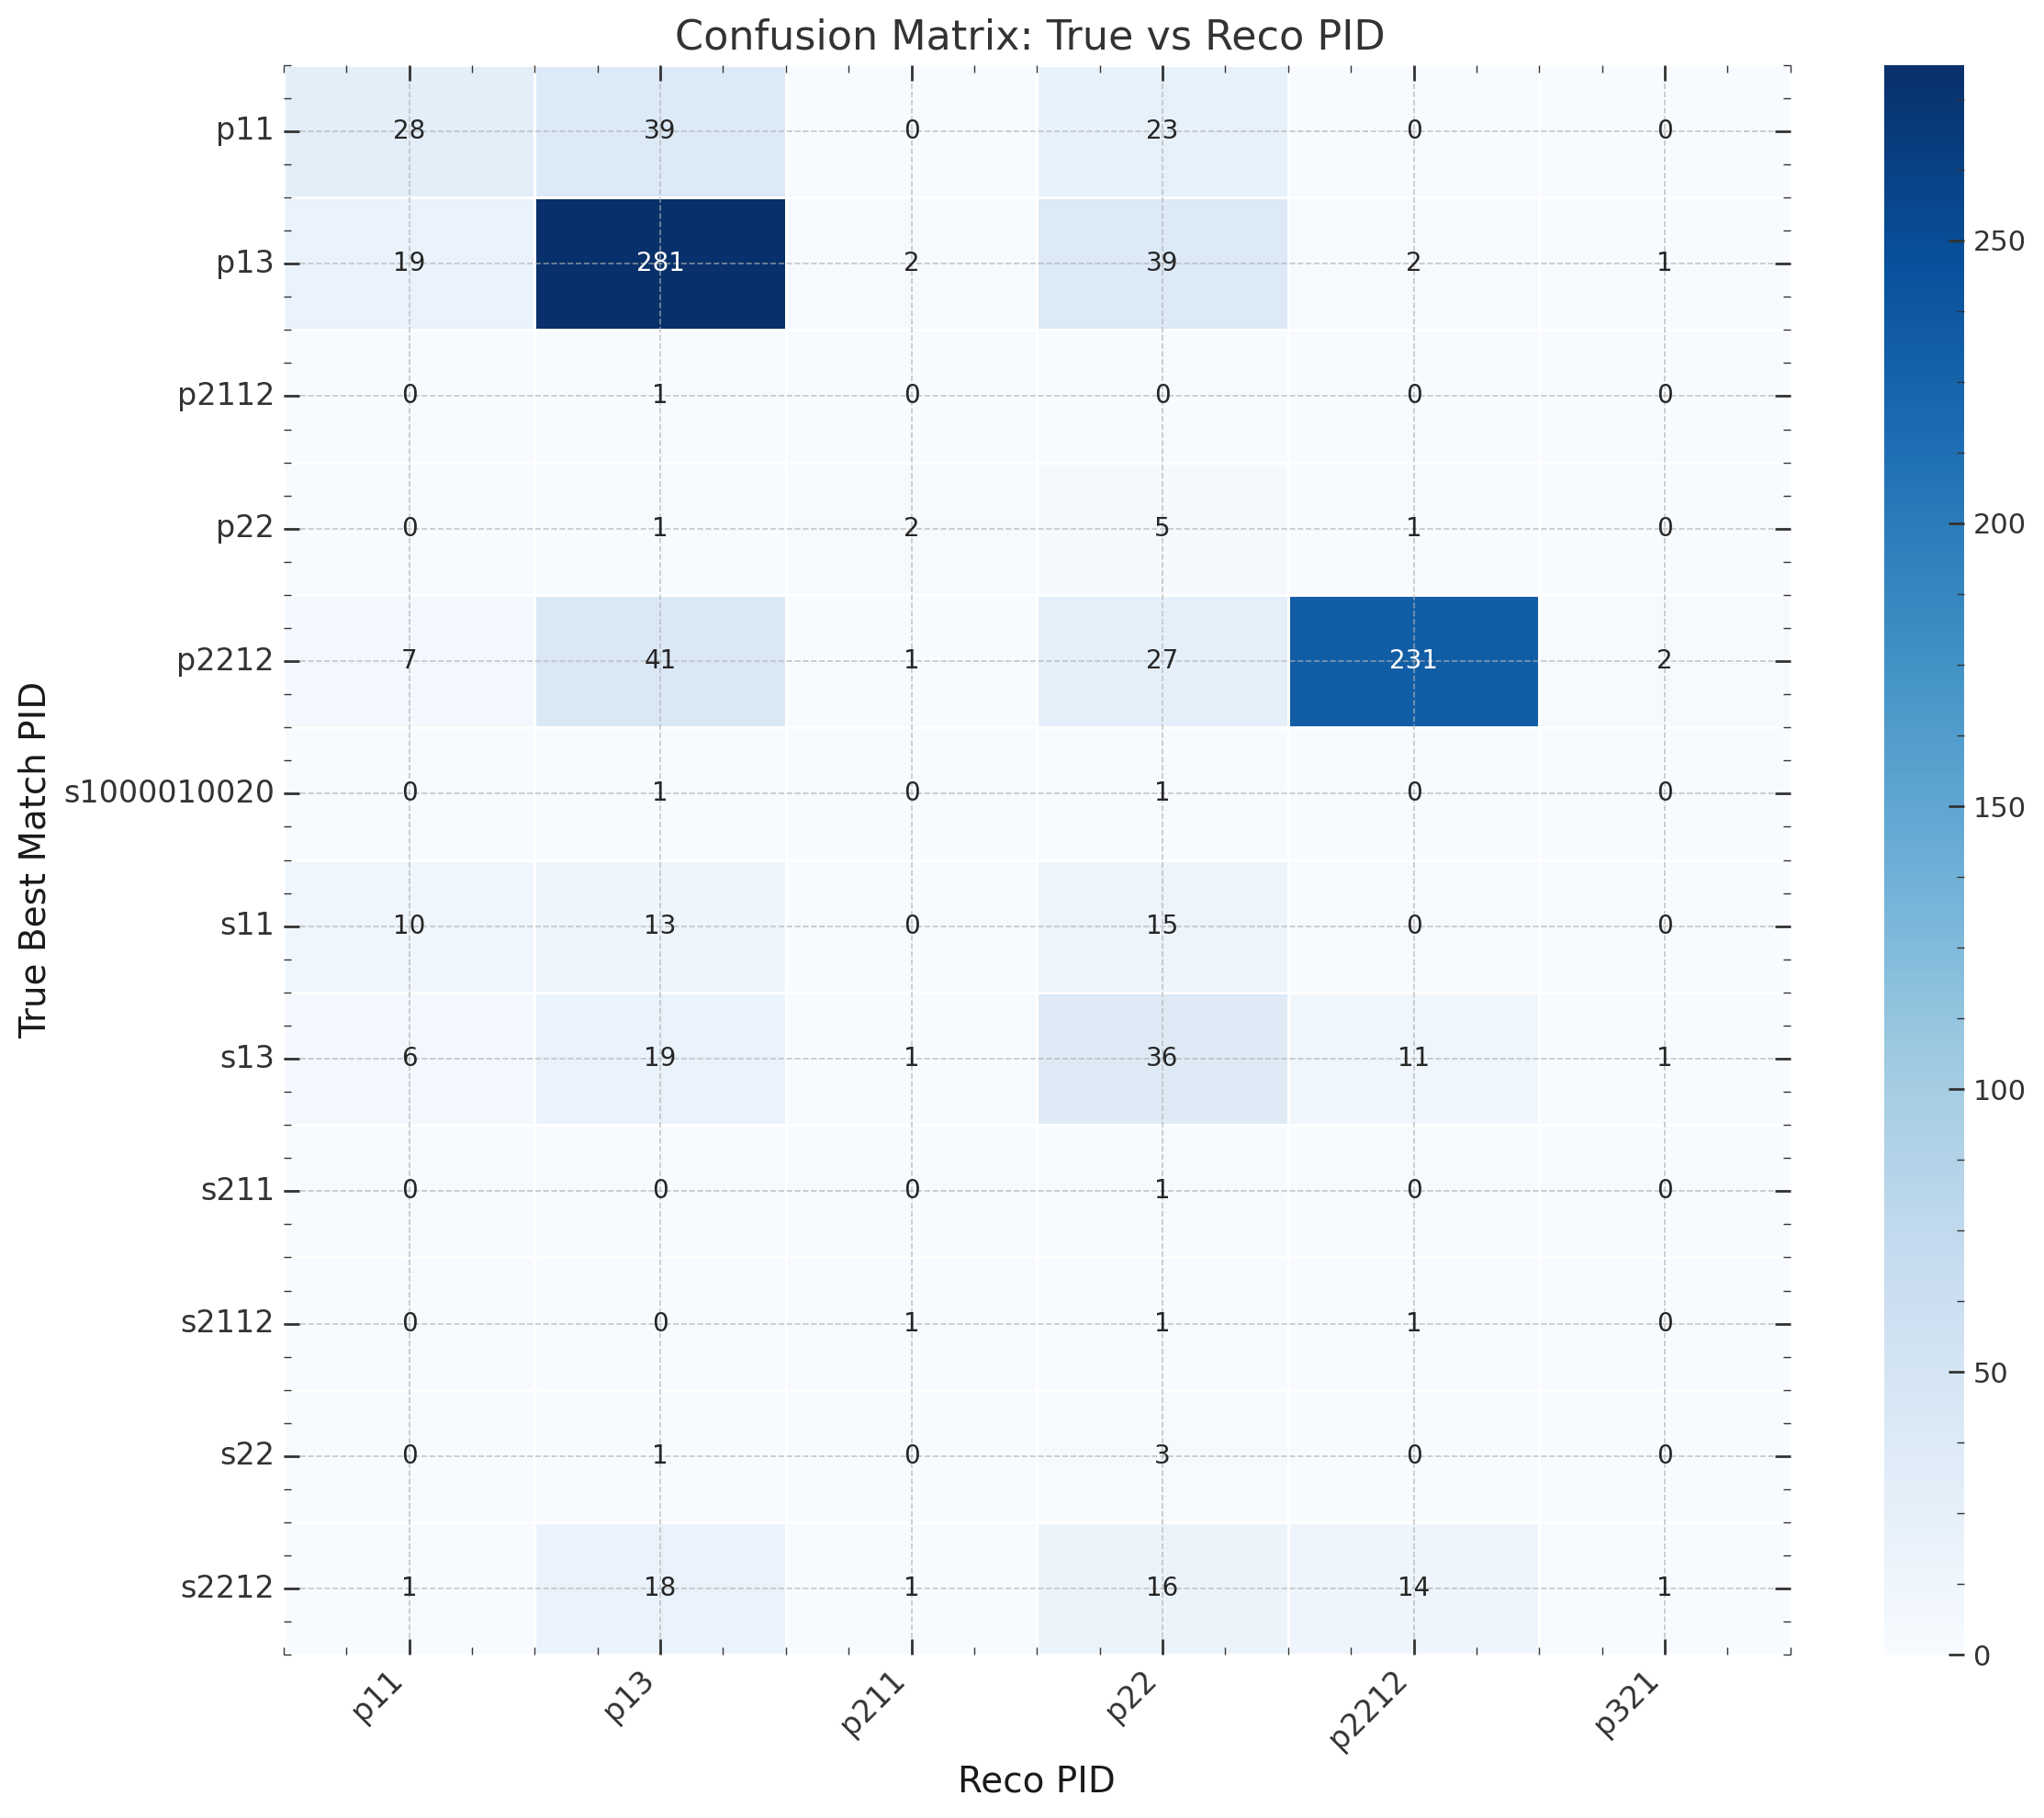

In [87]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix

# Get unique true and reco labels
unique_true_labels = sorted(set(true_labels))
unique_reco_labels = sorted(set(reco_labels))

# Create the confusion matrix with both label sets combined
combined_labels = sorted(set(unique_true_labels + unique_reco_labels))
cm_full = confusion_matrix(true_labels, reco_labels, labels=combined_labels)

# Slice the submatrix: rows = true_labels, columns = reco_labels
true_indices = [combined_labels.index(label) for label in unique_true_labels]
reco_indices = [combined_labels.index(label) for label in unique_reco_labels]

cm_submatrix = cm_full[np.ix_(true_indices, reco_indices)]

# Convert to DataFrame for easy plotting
df_cm = pd.DataFrame(cm_submatrix, index=unique_true_labels, columns=unique_reco_labels)

# Plot using seaborn
plt.figure(figsize=(12, 10))
sns.heatmap(df_cm, annot=True, fmt="d", cmap="Blues", linewidths=0.5)

plt.title('Confusion Matrix: True vs Reco PID ', fontsize=16)
plt.xlabel('Reco PID', fontsize=14)
plt.ylabel('True Best Match PID', fontsize=14)

plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()


In [ ]:
matched = np.array(ixn_dict['match'])
prim_reco = np.array(ixn_dict['nprim_reco'])
sec_reco = np.array(ixn_dict['nsec_reco'])
true_type = np.array(ixn_dict['prim_bm_type'], dtype=object)[(matched==1)&(prim_reco ==2)]
pgs_true = (np.array(ixn_dict['prim_bm_pdg'], dtype=object))[(matched==1)&(prim_reco ==2)]



true_type =[np.sort(element) for element in true_type]
#pgs_true = [abs(lst) for lst in pgs_true]
true_type = [tuple(lst) for lst in true_type]
# Count occurrences of each unique tuple
pids=[]
counter = Counter(true_type)
for i in counter.keys():
    pids.extend(i)
print(f'True Type for one primary vertices {np.unique(pids)}')

# Define a mapping of PDG codes to particle names
pdg_to_name = {
    1: 'Primary',
    3: 'Secondary',
}

labels = []
num = []
for key, value in counter.items():
    # if pdg_tab.muon not in key: 
    #     continue
    # else:
    labels.append(str(key))  # Convert tuple to string for labeling
    num.append(value)
        
# Convert PDG tuples to human-readable particle names
labels_named = []
for key in labels:
    pdg_codes = eval(key)  # Convert string representation of tuple back to tuple
    named_particles = [pdg_to_name.get(pdg, f'PDG {pdg}') for pdg in pdg_codes]  # Replace PDG codes with names
    labels_named.append(" + ".join(named_particles))  # Create a readable label

# Plot histogram with updated labels
plt.figure(figsize=(8, 5))
bars = plt.bar(labels_named, num, color='blue', alpha=0.7, edgecolor='black')

# # Add percentages on top of bars
total_count= np.sum(tuple(counter.values()))
for bar, value in zip(bars, num):
    percent = (value / total_count) * 100  # Calculate percentage
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{percent:.1f}%', 
             ha='center', va='bottom', fontsize=8, color='black')

# Labels and title
plt.xlabel('Best Match Type of Reconstructed Primaries')
plt.ylabel('Num of Reconstructed Vertices')
plt.yscale('log')
plt.title('True Type in Reco Vertices With Two Primary')
plt.xticks(rotation=0, ha='center', fontsize = 7)

# Show plot
plt.tight_layout()
plt.show()

TypeError: '<' not supported between instances of 'int' and 'NoneType'

In [49]:
import numpy as np

# Extract arrays from dictionary
matched = np.array(ixn_dict['match'])
prim_reco = np.array(ixn_dict['nprim_reco'])
sec_reco = np.array(ixn_dict['nsec_reco'])

# Filtered arrays
true_type = np.array(ixn_dict['prim_bm_type'], dtype=object)[(matched == 1) & (prim_reco == 2)]
pgs_true = np.array(ixn_dict['prim_bm_pdg'], dtype=object)[(matched == 1) & (prim_reco == 2)]
prim_pgs_reco = np.array(ixn_dict['prim_pdgs_vtx'], dtype=object)[(matched == 1) & (prim_reco == 2)]

# Process arrays: sort, abs, convert to tuple
pgs_true = [tuple(np.sort(np.abs(lst))) for lst in pgs_true]
true_type = [tuple(np.sort(lst)) for lst in true_type]
prim_pgs_reco = [tuple(np.sort(lst)) for lst in prim_pgs_reco]

# Collect labels
true_labels = []
reco_labels=[]
for reco_pdgs, true_pdgs, type_vals in zip(prim_pgs_reco, pgs_true, true_type):
    for m, n, p in zip(reco_pdgs, true_pdgs, type_vals):
        if p == 1:
            true_labels.append(f'p{n}')  # Append label (can modify as needed)
        if p == 3:
            true_labels.append(f's{n}')  # Append label (can modify as needed)
        reco_labels.append(f'p{m}')



cm = confusion_matrix(true_labels, reco_labels)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)

TypeError: bad operand type for abs(): 'NoneType'

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Extract arrays from dictionary
matched = np.array(ixn_dict['match'])
prim_reco = np.array(ixn_dict['nprim_reco'])
sec_reco = np.array(ixn_dict['nsec_reco'])

# Filtered arrays
true_type = np.array(ixn_dict['prim_bm_type'], dtype=object)[(matched == 1) & (prim_reco == 2)]
pgs_true = np.array(ixn_dict['prim_bm_pdg'], dtype=object)[(matched == 1) & (prim_reco == 2)]
prim_pgs_reco = np.array(ixn_dict['prim_pdgs_vtx'], dtype=object)[(matched == 1) & (prim_reco == 2)]

# Process arrays: sort, abs, convert to tuple
pgs_true = [tuple(np.sort(np.abs(lst))) for lst in pgs_true]
true_type = [tuple(np.sort(lst)) for lst in true_type]
prim_pgs_reco = [tuple(np.sort(lst)) for lst in prim_pgs_reco]

# Collect labels
true_labels = []
reco_labels = []

for reco_pdgs, true_pdgs, type_vals in zip(prim_pgs_reco, pgs_true, true_type):
    for m, n, p in zip(reco_pdgs, true_pdgs, type_vals):
        if p == 1:
            true_labels.append(f'p{n}')  # Primary
        elif p == 3:
            true_labels.append(f's{n}')  # Secondary
        
        reco_labels.append(f'p{m}')      # Reco particle

# Get the unique sorted labels to use in display_labels
all_labels = sorted(list(set(true_labels + reco_labels)))

# Compute confusion matrix with consistent label ordering
cm = confusion_matrix(true_labels, reco_labels, labels=all_labels)

# Display the confusion matrix with your labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=all_labels)
disp.plot(cmap=plt.cm.es)
plt.xticks(rotation=45)  # Optional: rotate x labels for better readability
plt.title("Confusion Matrix with Custom Labels")
plt.show()


TypeError: bad operand type for abs(): 'NoneType'

In [57]:

# Convert lists to numpy arrays
matched = np.array(ixn_dict['match'])

# Apply filtering to get only matched interactions
true_type = np.array(ixn_dict['prim_bm_type'], dtype=object)[matched == 1]
pgs_true = np.array(ixn_dict['bm_pdg'], dtype=object)[matched == 1]

# Initialize lists to store results
prim_pdgs_list = []
sec_pdgs_list = []

# Iterate over matched PDG codes and their corresponding types
for pdgs, types in zip(pgs_true, true_type): 
    prim_pdgs_list.append(np.array(pdgs)[np.array(types) == 1])  # Select PDGs where type == 1
    sec_pdgs_list.append(np.array(pdgs)[np.array(types) == 3])  # Select PDGs where type == 3

# Convert lists to numpy arrays
prim_pdgs_array = np.array(prim_pdgs_list, dtype=object)
sec_pdgs_array = np.array(sec_pdgs_list, dtype=object)

# Display results
prim_pdgs_array, sec_pdgs_array


KeyError: 'bm_pdg'

In [ ]:
pdg_tab = ParticleCode()
matched = np.array(ixn_dict['match'])
prim_true =np.array(ixn_dict['nprim'])
prim_reco = np.array(ixn_dict['nprim_reco'])
sec_true =np.array(ixn_dict['nsec'])
sec_reco = np.array(ixn_dict['nsec_reco'])



#matched reco vertices interactions with two reco prim particles
prim_pgs_reco = (np.array(ixn_dict['prim_pdgs_vtx'], dtype=object))[(matched==1)&(prim_reco==2)]
sec_pgs_reco = (np.array(ixn_dict['prim_pdgs_vtx'], dtype=object))[(matched==1)&(prim_reco==2)]


# #matched reco vertices interactions with two reco prim particles
# prim_pgs_reco =[np.sort(element) for element in prim_pgs_reco]
# prim_pgs_reco = [tuple(lst) for lst in prim_pgs_reco]
# #np.unique(prim_pgs_reco)
# Counter(prim_pgs_reco)
(prim_pgs_reco)


array([list([13, 2212]), list([2212, 13]), list([2212, 13]),
       list([2212, 13]), list([2212, 13]), list([13, 13]),
       list([2212, 13]), list([2212, 13]), list([2212, 13]),
       list([22, 22]), list([13, 13]), list([22, 11]), list([2212, 13]),
       list([2212, 13]), list([13, 13]), list([22, 22]), list([2212, 13]),
       list([22, 22]), list([13, 13]), list([2212, 13]), list([2212, 13]),
       list([2212, 13]), list([22, 22]), list([22, 22]), list([13, 13]),
       list([2212, 13]), list([2212, 13]), list([22, 22]),
       list([2212, 13]), list([13, 2212]), list([22, 22]), list([22, 13]),
       list([2212, 13]), list([2212, 13]), list([13, 321]),
       list([2212, 13]), list([2212, 13]), list([2212, 13]),
       list([2212, 13]), list([13, 13]), list([13, 2212]),
       list([2212, 13]), list([22, 11]), list([11, 13]), list([2212, 13]),
       list([22, 2212]), list([13, 13]), list([2212, 13])], dtype=object)

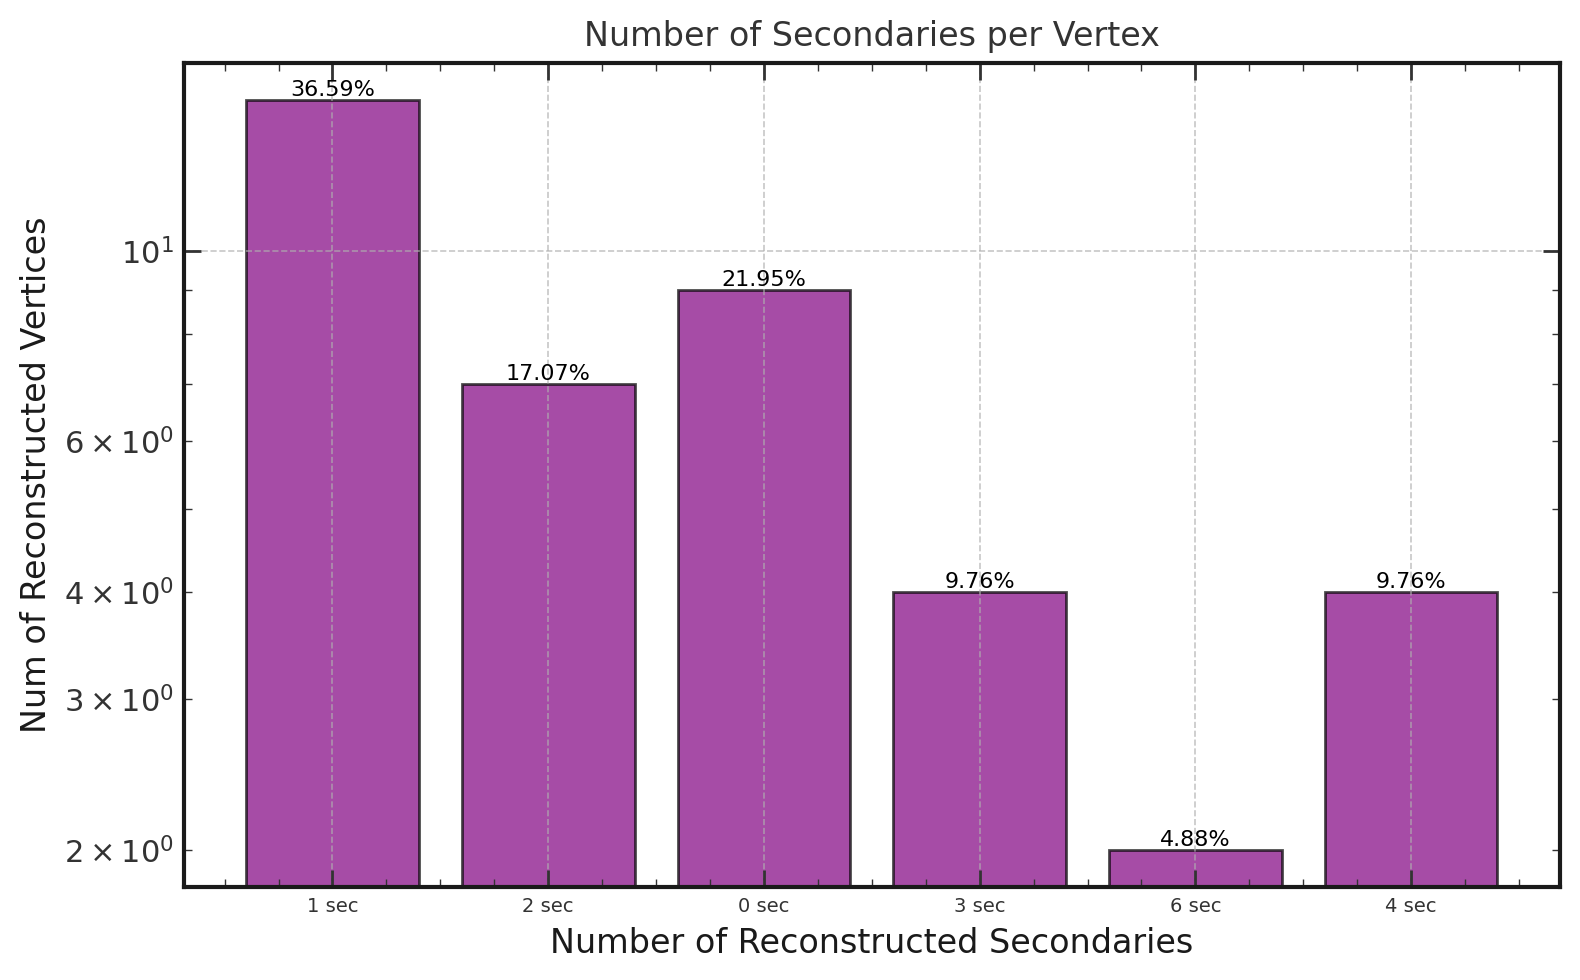

In [16]:
matched = np.array(ixn_dict['match'])
prim_reco = np.array(ixn_dict['nprim_reco'])
sec_reco = np.array(ixn_dict['nsec_reco'])

labels2=[]
num2=[]
for key, value in Counter(sec_reco[matched==1]).items():
    labels2.append(str(f'{key} sec'))
    num2.append(value)

# Plot histogram with updated labels
plt.figure(figsize=(8, 5))
bars2 = plt.bar(labels2, num2, color='purple', alpha=0.7, edgecolor='black')

# # Add percentages on top of bars
total_count= np.sum(tuple(Counter(sec_reco[matched==1]).values()))
for bar2, value in zip(bars2, num2):
    percent = (value / total_count) * 100  # Calculate percentage
    plt.text(bar2.get_x() + bar2.get_width() / 2, bar2.get_height(), f'{percent:.2f}%', 
             ha='center', va='bottom', fontsize=8, color='black')

# Labels and title
plt.xlabel('Number of Reconstructed Secondaries')
plt.ylabel('Num of Reconstructed Vertices')
plt.yscale('log')
plt.title('Number of Secondaries per Vertex')
plt.xticks(rotation=0, ha='center', fontsize = 7)
plt.tight_layout()
plt.show()

In [17]:
pdg_tab = ParticleCode()
matched = np.array(ixn_dict['match'])
prim_true =np.array(ixn_dict['nprim'])
prim_reco = np.array(ixn_dict['nprim_reco'])
sec_true =np.array(ixn_dict['nsec'])
sec_reco = np.array(ixn_dict['nsec_reco'])
matched = np.array(ixn_dict['match'])
prim_reco = np.array(ixn_dict['nprim_reco'])
sec_reco = np.array(ixn_dict['nsec_reco'])
true_type = np.array(ixn_dict['prim_bm_type'], dtype=object)[(matched==1)&(prim_reco ==2)]
pgs_true = (np.array(ixn_dict['prim_bm_pdg'], dtype=object))[(matched==1)&(prim_reco ==2)]



#matched reco vertices interactions with two reco prim particles
prim_pgs_reco = (np.array(ixn_dict['prim_pdgs_vtx'], dtype=object))[(matched==1)&(prim_reco==2)]
sec_pgs_reco = (np.array(ixn_dict['prim_pdgs_vtx'], dtype=object))[(matched==1)&(prim_reco==2)]


#matched reco vertices interactions with two reco prim particles
prim_pgs_reco =[np.sort(element) for element in prim_pgs_reco]
prim_pgs_reco = [tuple(lst) for lst in prim_pgs_reco]
#np.unique(prim_pgs_reco)
Counter(prim_pgs_reco)




Counter({(np.int32(13), np.int32(2212)): 8, (np.int32(13), np.int32(13)): 1})

PIDS for one primary vertices [  11   13   22  211  321 2212]


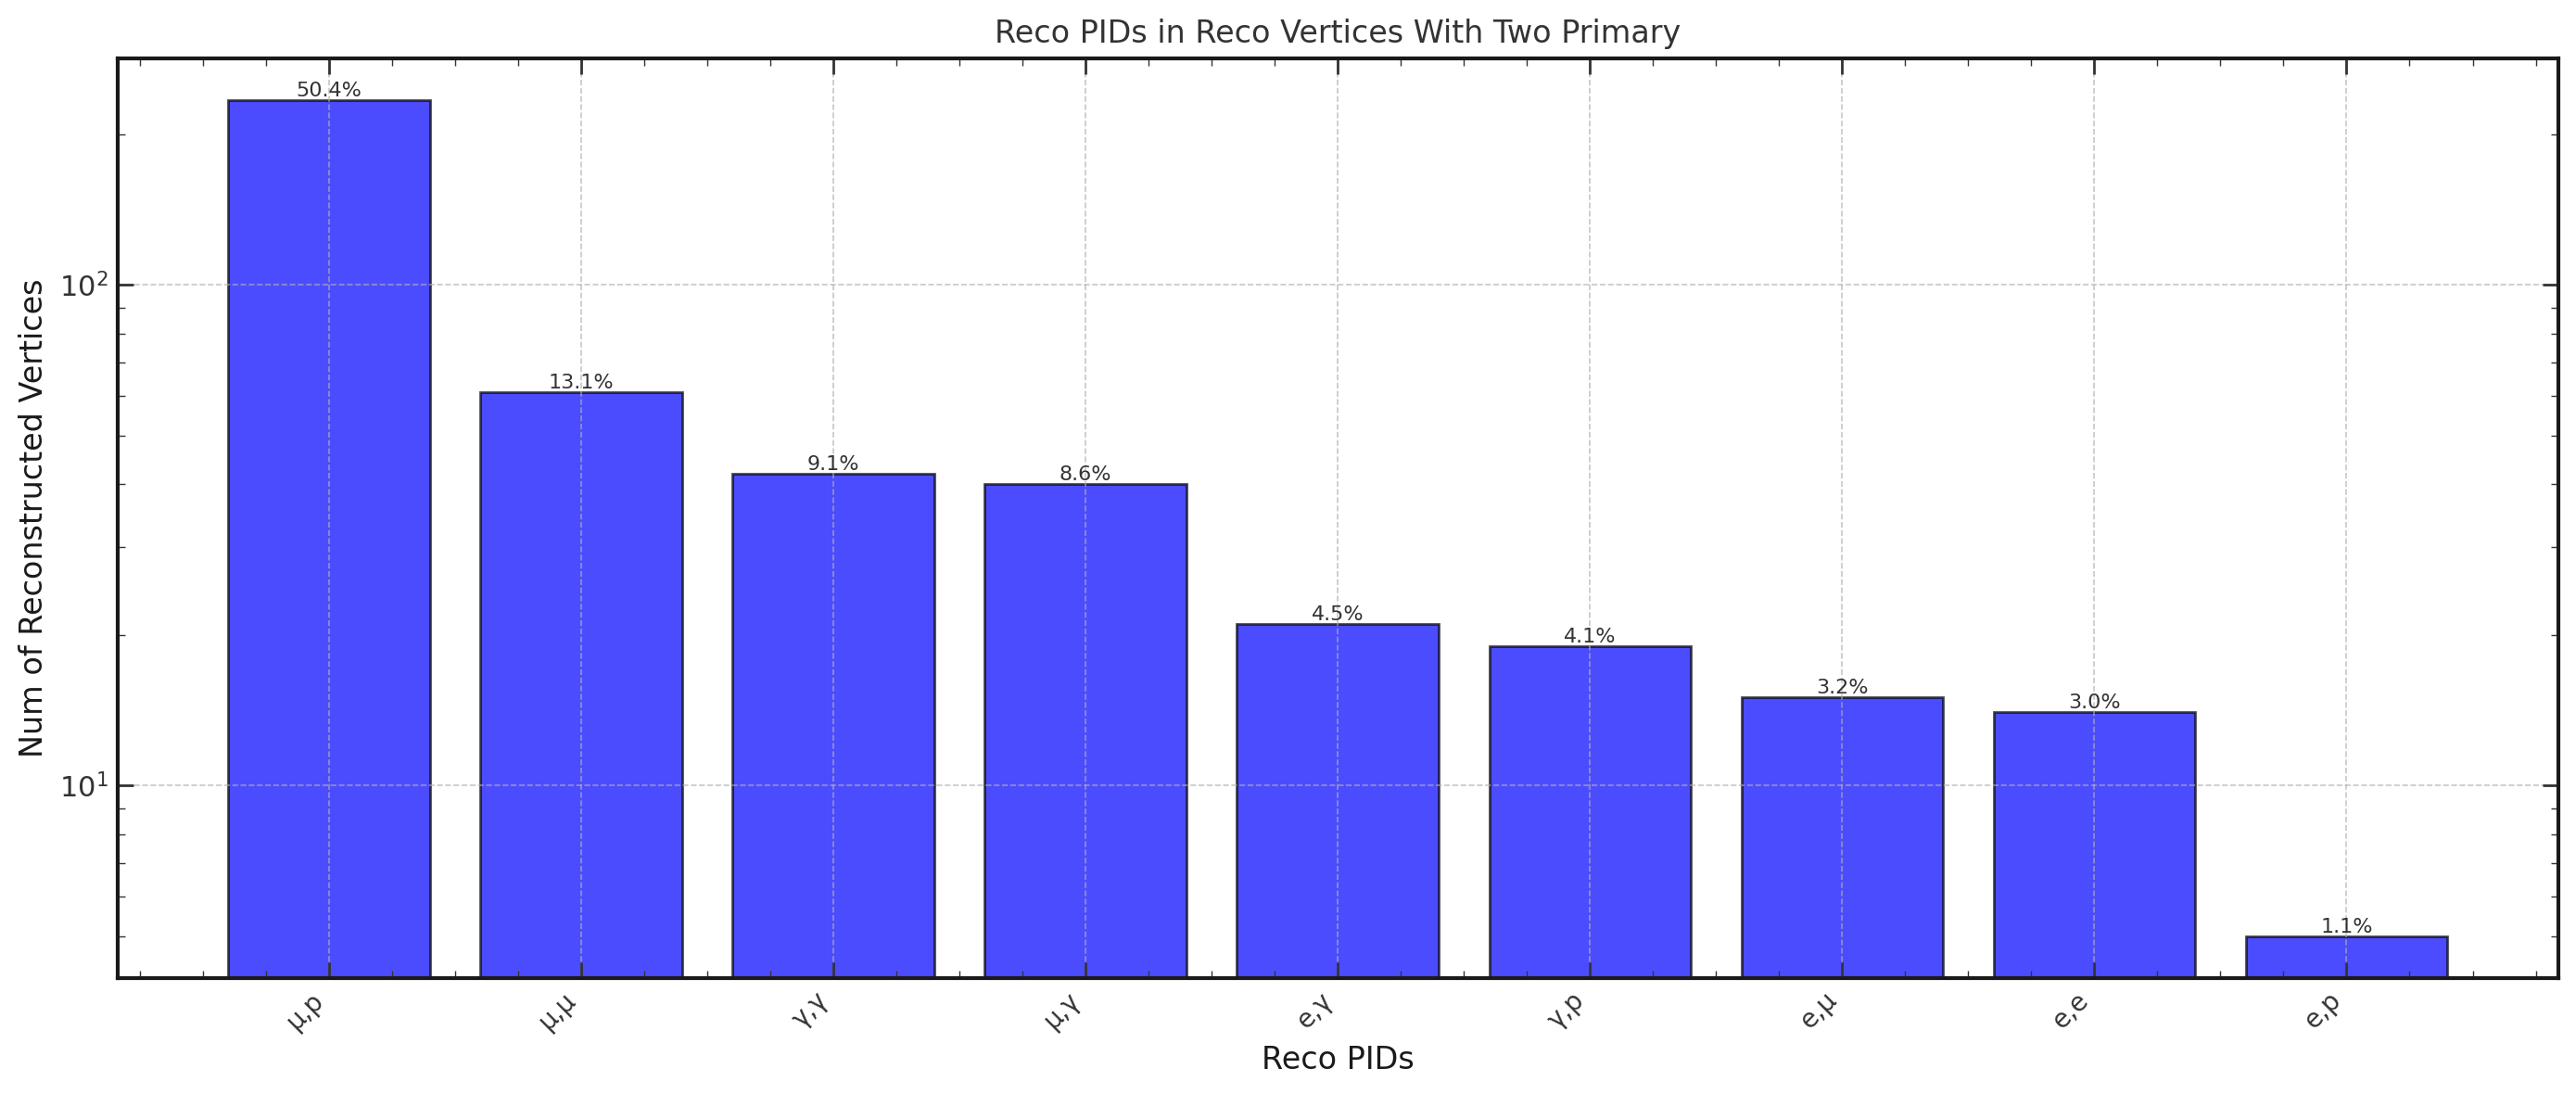

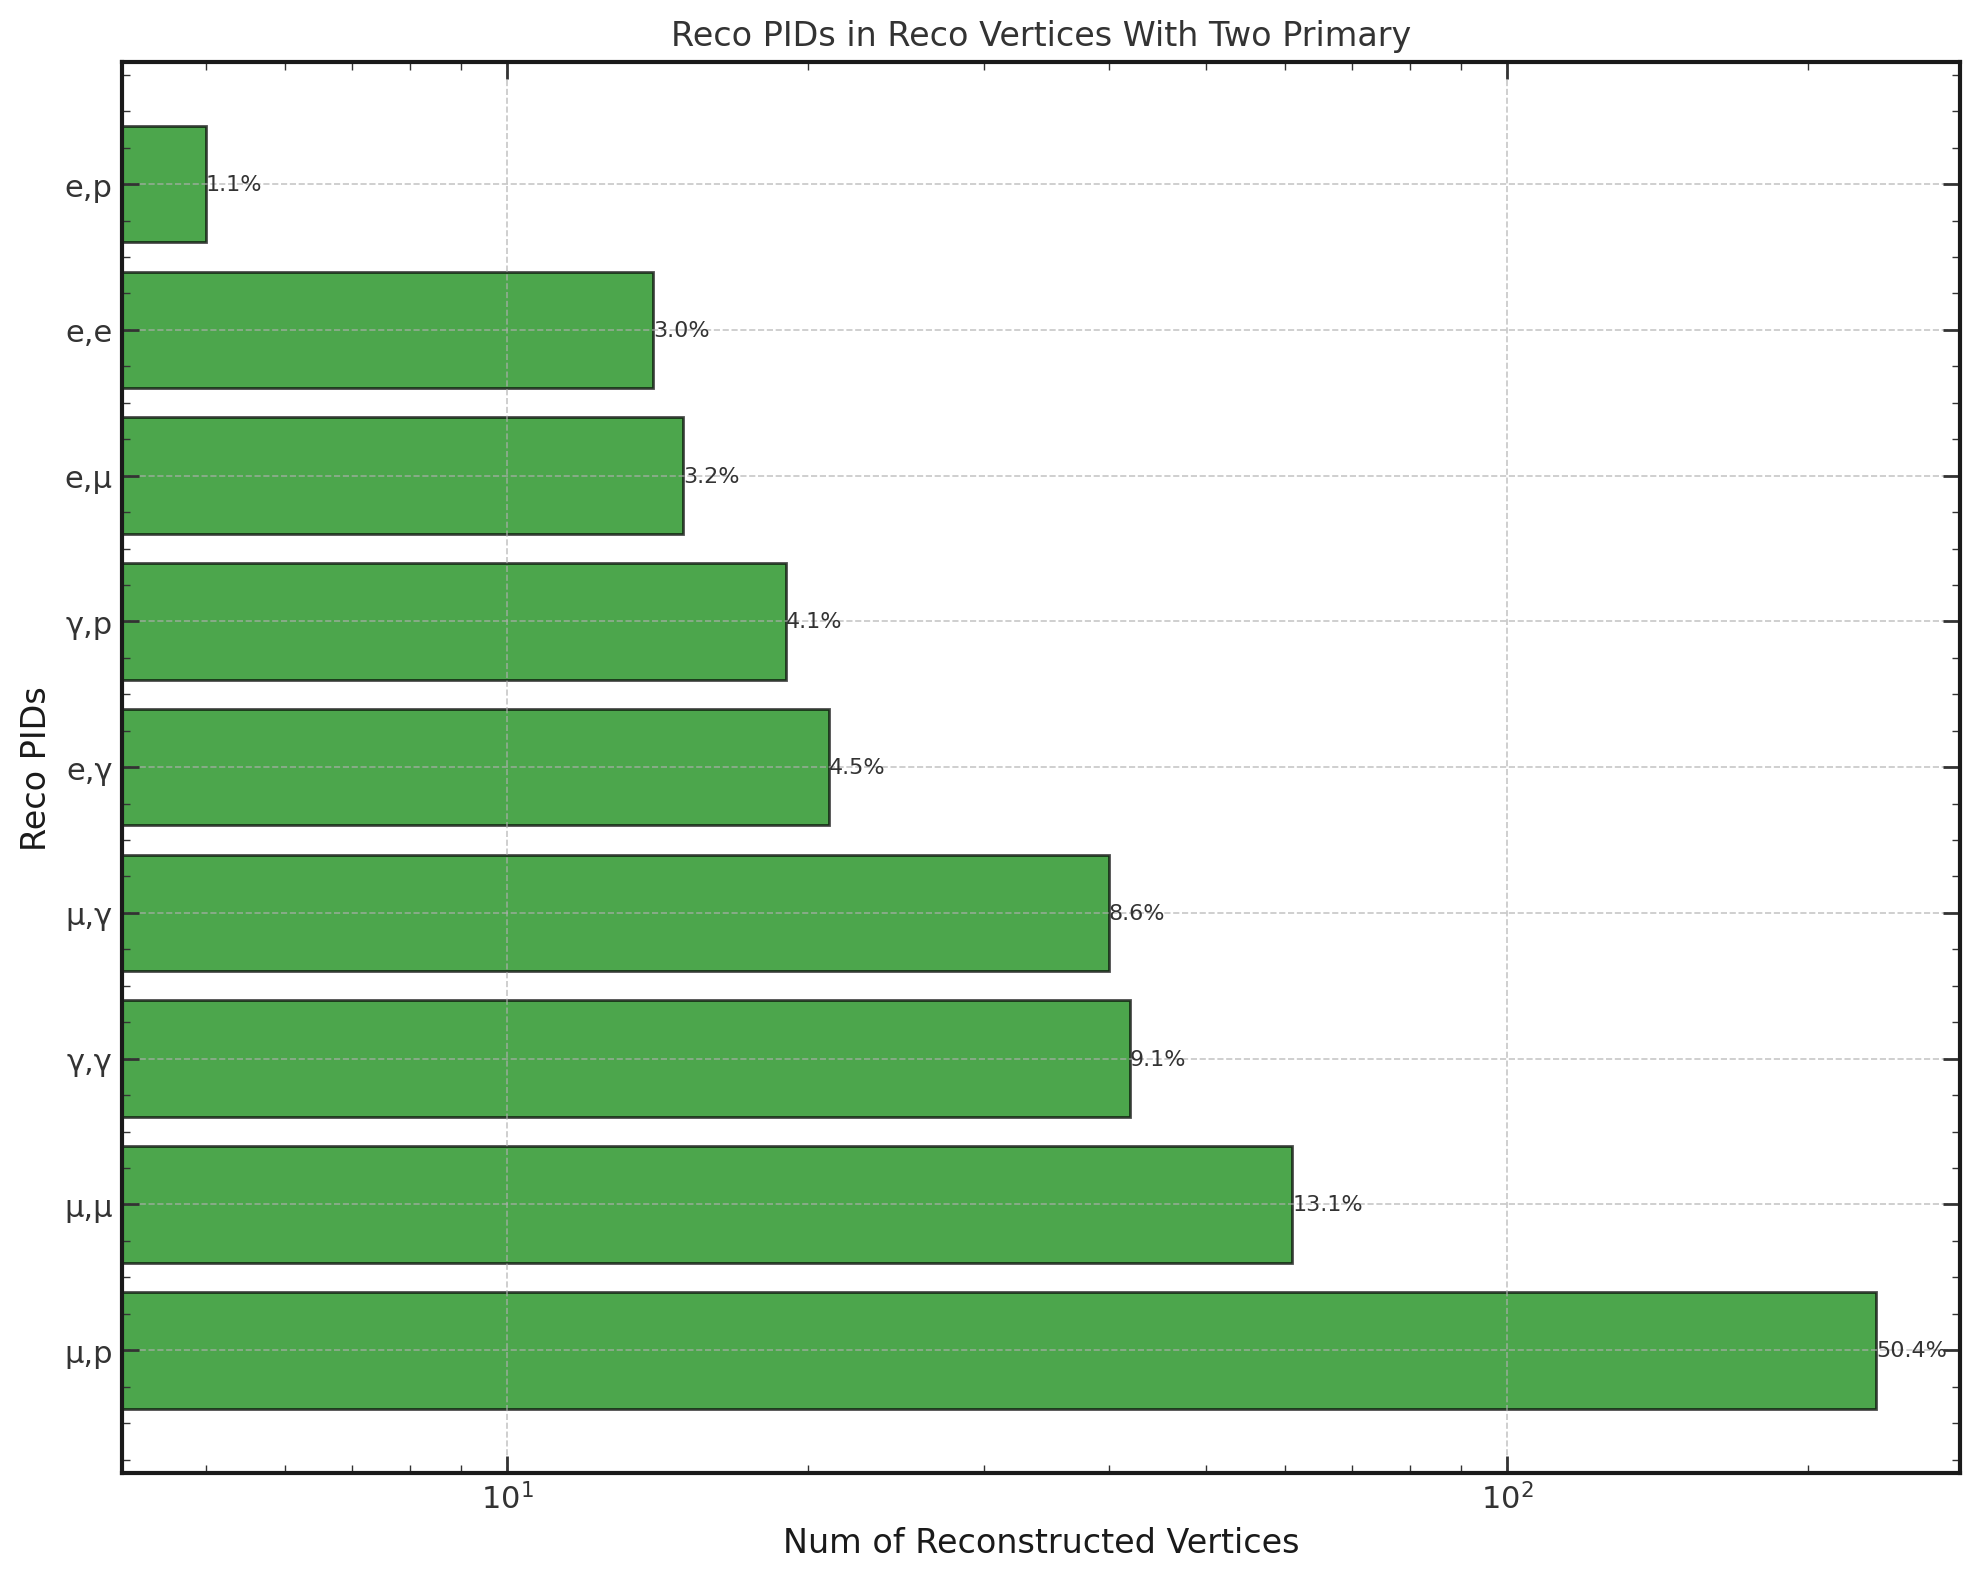

In [91]:
#matched reco vertices interactions with two reco prim particles
prim_pgs_reco = (np.array(ixn_dict['prim_pdgs_vtx'], dtype=object))[(matched==1)&(prim_reco==2)]
prim_pgs_reco =[np.sort(element) for element in prim_pgs_reco]
prim_pgs_reco = [tuple(lst) for lst in prim_pgs_reco]

# Count occurrences of each unique tuple
pids=[]
counter = Counter(prim_pgs_reco)
for i in counter.keys():
    pids.extend(i)
print(f'PIDS for one primary vertices {np.unique(pids)}')

# Define a mapping of PDG codes to particle names
# pdg_to_name = {
#     11: 'Electron',
#     13: 'Muon',
#     2212: 'Proton',
#     211: 'Pion',
#     321: 'Kaon',
#     22: 'Photon'
# }

# labels = []
# num = []
# for key, value in counter.items():
#     # if pdg_tab.muon not in key: 
#     #     continue
#     # else:
#     labels.append(str(key))  # Convert tuple to string for labeling
#     num.append(value)
        
# # Convert PDG tuples to human-readable particle names
# labels_named = []
# for key in labels:
#     pdg_codes = eval(key)  # Convert string representation of tuple back to tuple
#     named_particles = [pdg_to_name.get(pdg, f'PDG {pdg}') for pdg in pdg_codes]  # Replace PDG codes with names
#     labels_named.append(" + ".join(named_particles))  # Create a readable label

# # Plot histogram with updated labels
# plt.figure(figsize=(8, 5))
# bars = plt.bar(labels_named, num, color='purple', alpha=0.7, edgecolor='black')

# # # Add percentages on top of bars
# total_count= np.sum(tuple(counter.values()))
# for bar, value in zip(bars, num):
#     percent = (value / total_count) * 100  # Calculate percentage
#     plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{percent:.1f}%', 
#              ha='center', va='bottom', fontsize=8, color='black')

# # Labels and title
# plt.xlabel('Reconstructed Primary PIDs')
# plt.ylabel('Num of Reconstructed Vertices')
# plt.yscale('log')
# plt.title('Reco PIDs in Reco Vertices With One Primary')
# plt.xticks(rotation=0, ha='center', fontsize = 7)

# # Show plot
# plt.tight_layout()
# plt.show()


pdg_to_name = {
    11: 'e',
    13: 'μ',
    2212: 'p',
    211: 'π',
    321: 'K',
    22: 'γ'
}

labels = []
num = []
for key, value in counter.items():
    # if pdg_tab.muon not in key: 
    #     continue
    # else:
    labels.append(str(key))  # Convert tuple to string for labeling
    num.append(value)
        
# Convert PDG tuples to human-readable particle names
labels_named = []
for key in labels:
    pdg_codes = eval(key)  # Convert string representation of tuple back to tuple
    named_particles = [pdg_to_name.get(pdg, f'PDG {pdg}') for pdg in pdg_codes]  # Replace PDG codes with names
    labels_named.append(",".join(named_particles))  # Create a readable label

total_count = np.sum(num)
labels_filtered = []
num_filtered = []
percent_filtered = []

for label, count in zip(labels_named, num):
    percent = (count / total_count) * 100
    if percent >= 1:
        labels_filtered.append(label)
        num_filtered.append(count)
        percent_filtered.append(percent)


sorted_data = sorted(zip(num_filtered, labels_filtered, percent_filtered), reverse=True)
num_sorted, labels_sorted, percent_sorted = zip(*sorted_data)

# === VERTICAL BAR PLOT ===
plt.figure(figsize=(14, 6))  # Wider figure for readability
bars = plt.bar(labels_sorted, num_sorted, color='blue', alpha=0.7, edgecolor='black')

# Add percentages on top of bars
for bar, percent in zip(bars, percent_sorted):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{percent:.1f}%', 
             ha='center', va='bottom', fontsize=8)

plt.xlabel('Reco PIDs')
plt.ylabel('Num of Reconstructed Vertices')
plt.yscale('log')
plt.title('Reco PIDs in Reco Vertices With Two Primary')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()
plt.show()

# === OPTIONAL: HORIZONTAL BAR PLOT ===
plt.figure(figsize=(10, 8))  # Taller figure for horizontal layout
bars = plt.barh(labels_sorted, num_sorted, color='green', alpha=0.7, edgecolor='black')

for bar, percent in zip(bars, percent_sorted):
    plt.text(bar.get_width(), bar.get_y() + bar.get_height() / 2, f'{percent:.1f}%', 
             va='center', fontsize=8)

plt.xlabel('Num of Reconstructed Vertices')
plt.ylabel('Reco PIDs')
plt.xscale('log')
plt.title('Reco PIDs in Reco Vertices With Two Primary')
plt.tight_layout()
plt.show()

PIDS for one primary vertices [  11   13   22  211  321 2212]


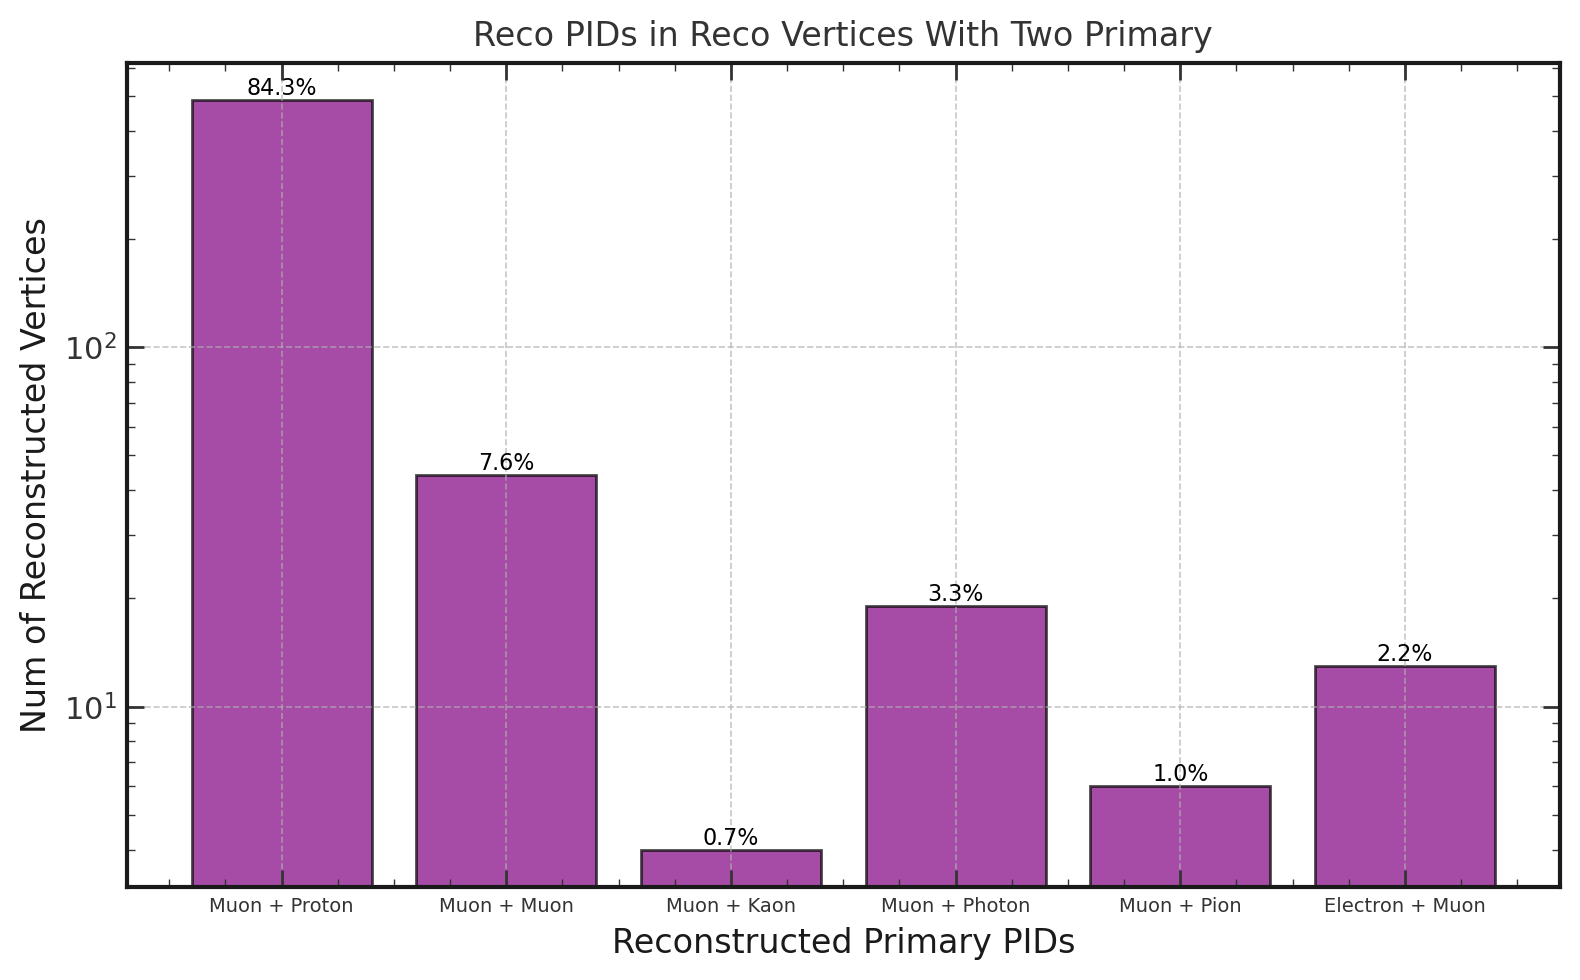

In [126]:
#matched reco vertices interactions with two reco prim particles
prim_pgs_reco = (np.array(ixn_dict['prim_pdgs_vtx'], dtype=object))[(matched==1)&(prim_reco==2)]
prim_pgs_reco =[np.sort(element) for element in prim_pgs_reco]
prim_pgs_reco = [tuple(lst) for lst in prim_pgs_reco]

# Count occurrences of each unique tuple
pids=[]
counter = Counter(prim_pgs_reco)
for i in counter.keys():
    pids.extend(i)
print(f'PIDS for one primary vertices {np.unique(pids)}')

# Define a mapping of PDG codes to particle names
pdg_to_name = {
    11: 'Electron',
    13: 'Muon',
    2212: 'Proton',
    211: 'Pion',
    321: 'Kaon',
    22: 'Photon'
}

labels = []
num = []
for key, value in counter.items():
    if pdg_tab.muon not in key: 
        continue
    else:
        labels.append(str(key))  # Convert tuple to string for labeling
        num.append(value)
        
# Convert PDG tuples to human-readable particle names
labels_named = []
for key in labels:
    pdg_codes = eval(key)  # Convert string representation of tuple back to tuple
    named_particles = [pdg_to_name.get(pdg, f'PDG {pdg}') for pdg in pdg_codes]  # Replace PDG codes with names
    labels_named.append(" + ".join(named_particles))  # Create a readable label

# Plot histogram with updated labels
plt.figure(figsize=(8, 5))
bars = plt.bar(labels_named, num, color='purple', alpha=0.7, edgecolor='black')

# # Add percentages on top of bars
total_count= np.sum(tuple(counter.values()))
for bar, value in zip(bars, num):
    percent = (value / total_count) * 100  # Calculate percentage
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{percent:.1f}%', 
             ha='center', va='bottom', fontsize=8, color='black')

# Labels and title
plt.xlabel('Reconstructed Primary PIDs')
plt.ylabel('Num of Reconstructed Vertices')
plt.yscale('log')
plt.title('Reco PIDs in Reco Vertices With Two Primary')
plt.xticks(rotation=0, ha='center', fontsize = 7)

# Show plot
plt.tight_layout()
plt.show()


PIDS for one primary vertices [  11   13   22  321 2212]


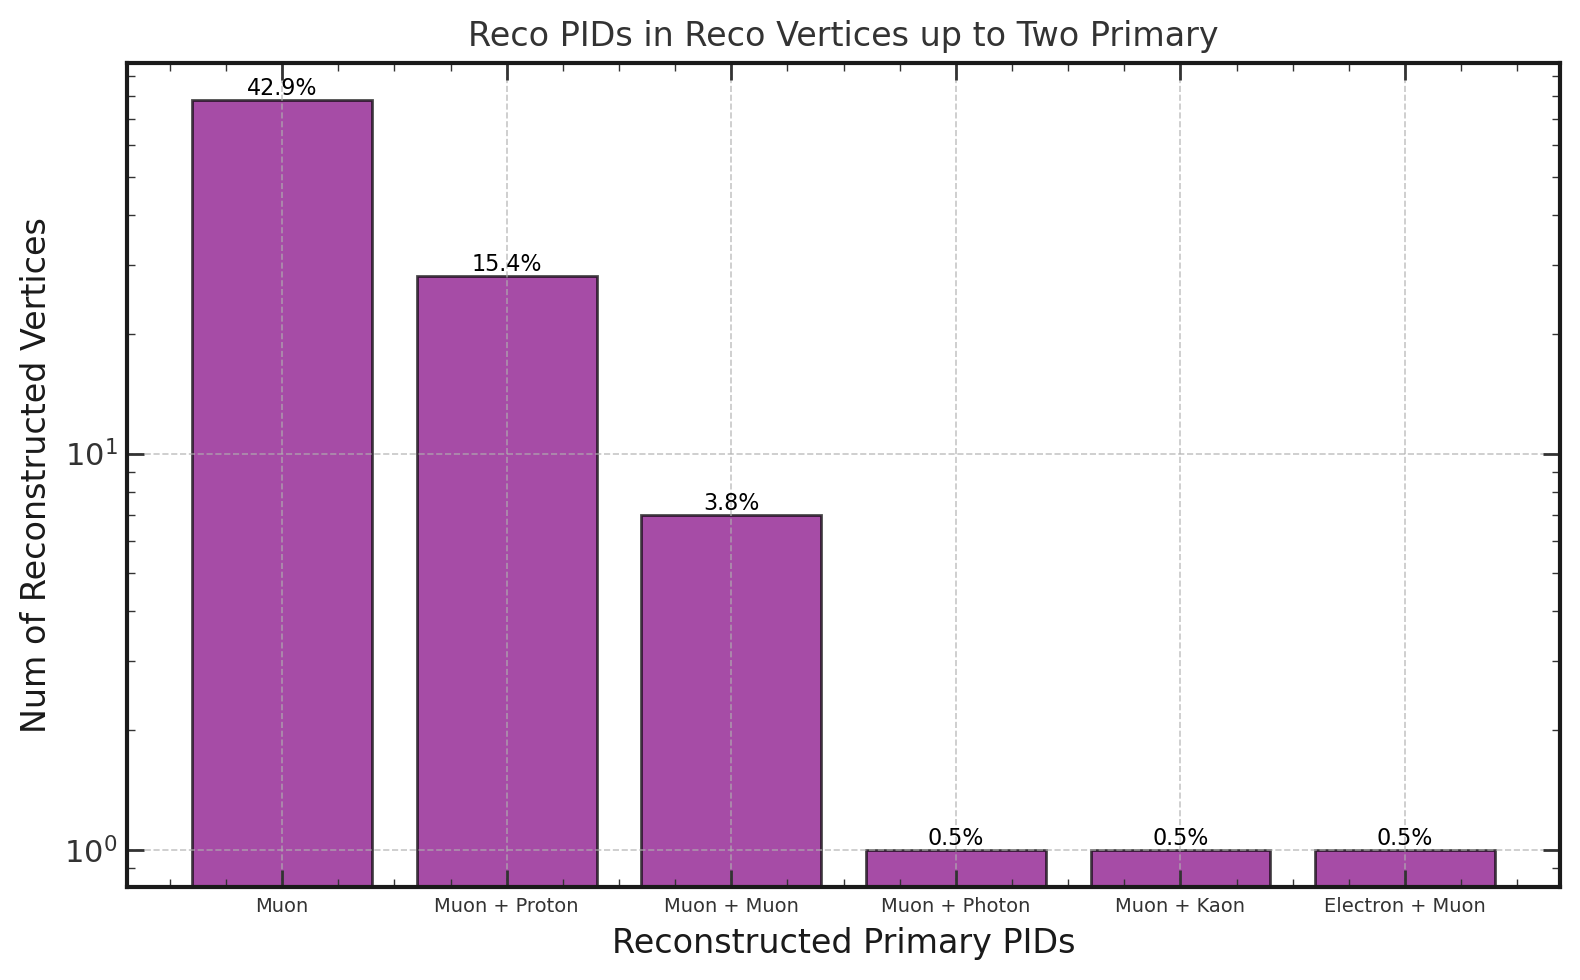

In [146]:
#matched reco vertices interactions with two reco prim particles
prim_pgs_reco = (np.array(ixn_dict['prim_pdgs_vtx'], dtype=object))[(matched==1)&(prim_reco<3)]
prim_pgs_reco =[np.sort(element) for element in prim_pgs_reco]
prim_pgs_reco = [tuple(lst) for lst in prim_pgs_reco]

# Count occurrences of each unique tuple
pids=[]
counter = Counter(prim_pgs_reco)
for i in counter.keys():
    pids.extend(i)
print(f'PIDS for one primary vertices {np.unique(pids)}')

# Define a mapping of PDG codes to particle names
pdg_to_name = {
    11: 'Electron',
    13: 'Muon',
    2212: 'Proton',
    211: 'Pion',
    321: 'Kaon',
    22: 'Photon'
}

labels = []
num = []
for key, value in counter.items():
    if pdg_tab.muon not in key: 
        continue
    else:
        labels.append(str(key))  # Convert tuple to string for labeling
        num.append(value)
        
# Convert PDG tuples to human-readable particle names
labels_named = []
for key in labels:
    pdg_codes = eval(key)  # Convert string representation of tuple back to tuple
    named_particles = [pdg_to_name.get(pdg, f'PDG {pdg}') for pdg in pdg_codes]  # Replace PDG codes with names
    labels_named.append(" + ".join(named_particles))  # Create a readable label

# Plot histogram with updated labels
plt.figure(figsize=(8, 5))
bars = plt.bar(labels_named, num, color='purple', alpha=0.7, edgecolor='black')

# # Add percentages on top of bars
total_count= np.sum(tuple(counter.values()))
for bar, value in zip(bars, num):
    percent = (value / total_count) * 100  # Calculate percentage
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{percent:.1f}%', 
             ha='center', va='bottom', fontsize=8, color='black')

# Labels and title
plt.xlabel('Reconstructed Primary PIDs')
plt.ylabel('Num of Reconstructed Vertices')
plt.yscale('log')
plt.title('Reco PIDs in Reco Vertices up to Two Primary')
plt.xticks(rotation=0, ha='center', fontsize = 7)

# Show plot
plt.tight_layout()
plt.show()

Counter({(13, 2212, 2212): 25, (13, 22, 22): 14, (13, 13, 2212): 14, (11, 13, 2212): 7, (13, 22, 2212): 7, (13, 13, 2212, 2212): 2, (11, 13, 13): 2, (11, 13, 211): 2, (13, 22, 22, 2212): 1, (13, 22, 22, 22): 1, (11, 13, 2212, 2212): 1, (13, 321, 2212, 2212): 1, (211, 2212, 2212): 1, (11, 22, 211): 1, (11, 13, 13, 2212): 1, (11, 11, 22, 2212): 1, (13, 211, 2212): 1, (13, 13, 13): 1, (11, 11, 13, 22): 1, (11, 11, 22, 211): 1, (11, 13, 22): 1})
PIDS for one primary vertices [  11   13   22  211  321 2212]


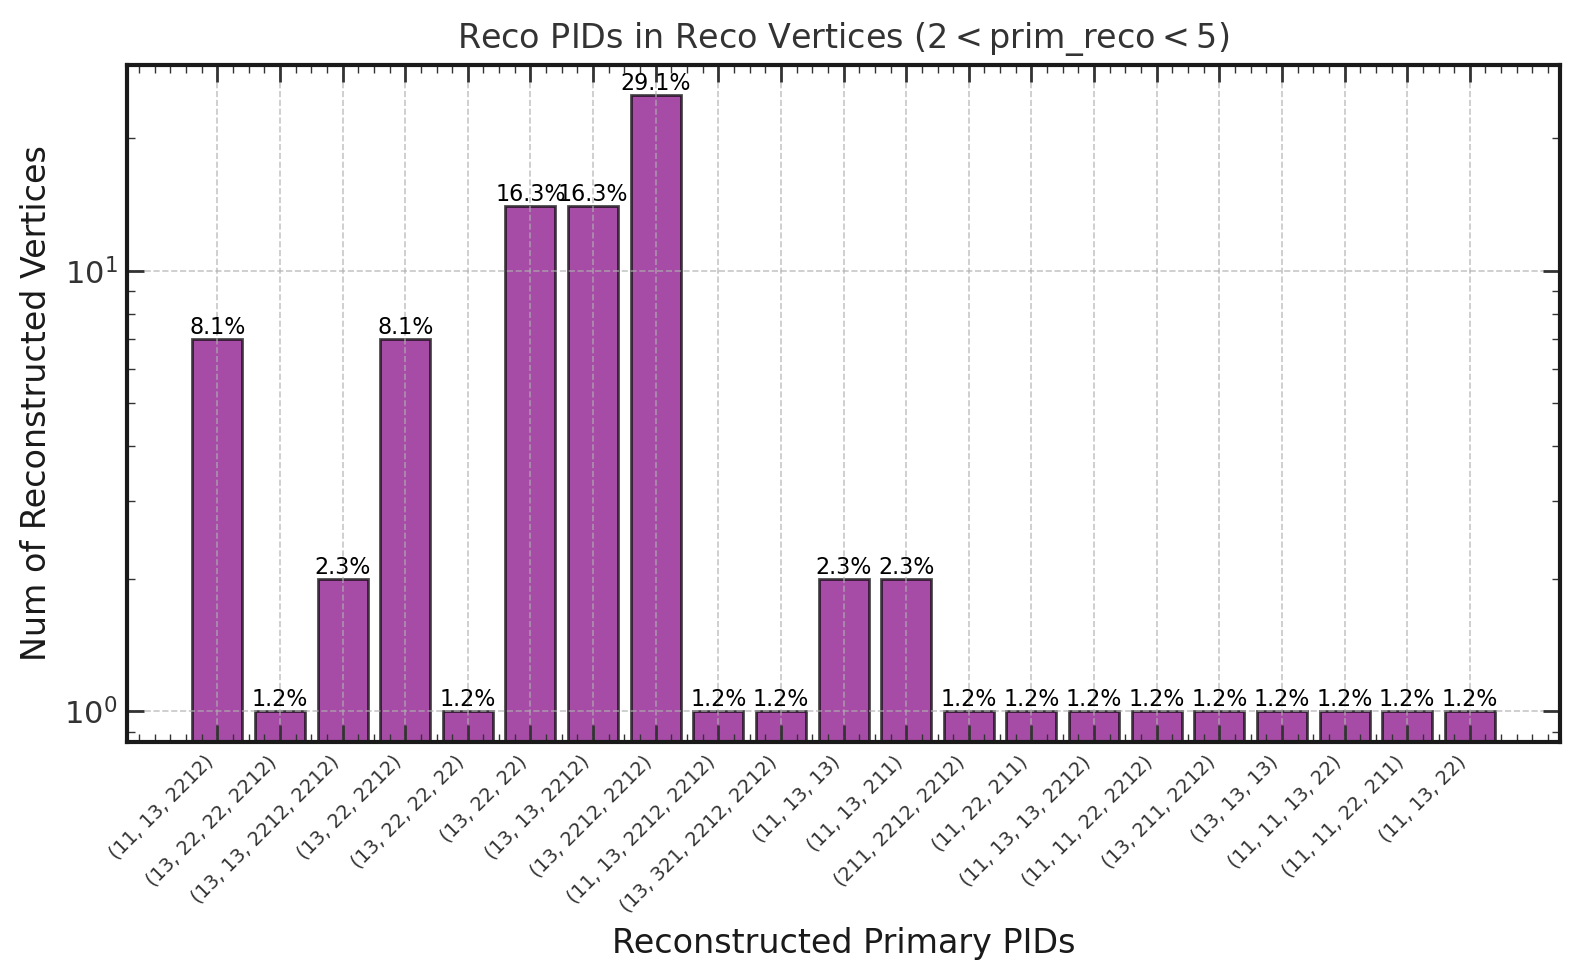

In [137]:
#matched reco vertices interactions with two reco prim particles
prim_pgs_reco = (np.array(ixn_dict['prim_pdgs_vtx'], dtype=object))[(matched==1)&(prim_reco>2)&(prim_reco<5)]
prim_pgs_reco =[np.sort(element) for element in prim_pgs_reco]
prim_pgs_reco = [tuple(lst) for lst in prim_pgs_reco]

# Count occurrences of each unique tuple
pids=[]
counter = Counter(prim_pgs_reco)
print(counter)
for i in counter.keys():
    pids.extend(i)
print(f'PIDS for one primary vertices {np.unique(pids)}')

# Define a mapping of PDG codes to particle names
pdg_to_name = {
    11: 'Electron',
    13: 'Muon',
    2212: 'Proton',
    211: 'Pion',
    321: 'Kaon',
    22: 'Photon'
}

labels = []
num = []
for key, value in counter.items():
    # if pdg_tab.muon not in key: 
    #     continue
    # else:
    labels.append(str(key))  # Convert tuple to string for labeling
    num.append(value)
        

# Plot histogram with updated labels
plt.figure(figsize=(8, 5))
bars = plt.bar(labels, num, color='purple', alpha=0.7, edgecolor='black')

# # Add percentages on top of bars
total_count= np.sum(tuple(counter.values()))
for bar, value in zip(bars, num):
    percent = (value / total_count) * 100  # Calculate percentage
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{percent:.1f}%', 
             ha='center', va='bottom', fontsize=8, color='black')

# Labels and title
plt.xlabel('Reconstructed Primary PIDs')
plt.ylabel('Num of Reconstructed Vertices')
plt.yscale('log')
plt.title(r'Reco PIDs in Reco Vertices ($2 < \text{prim_reco} < 5$)')
plt.xticks(rotation=45, ha='right', fontsize = 7)

# Show plot
plt.tight_layout()
plt.show()

In [19]:
results_df

,case,conditions,sph_radius,cyl_radius,True inx,Reco inx,Matched inx,Purity inx,Efficiency inx,TrueNeutrons,...,True n-photon,TrueSingle,TrueMulti,RecoSecProtons,MatchedSecProtons,Reco n-protons,Efficiency p,Purity p,Efficiency n-p,Purity n-p
0,QE:False - Exc:False,"[False, False, nocuts, 0, 0]",0 cm,0 cm,121,11083,113,0.0102,0.9339,365,...,2,25,5,2853,2028,229,7.090909,0.710831,9.541667,0.080266
1,QE:False - Exc:False,"[False, False, FV, 0, 0]",0 cm,0 cm,121,2913,113,0.0388,0.9339,365,...,2,25,5,1973,1299,175,4.541958,0.658388,7.291667,0.088697
2,QE:False - Exc:False,"[False, False, 2x2, 0, 0]",0 cm,0 cm,121,557,93,0.1670,0.7686,365,...,2,25,5,723,418,61,1.461538,0.578147,2.541667,0.084371
3,QE:False - Exc:False,"[False, False, mx2, 0, 0]",0 cm,0 cm,121,376,85,0.2261,0.7025,365,...,2,25,5,471,262,48,0.916084,0.556263,2.000000,0.101911
4,QE:True - Exc:False,"[True, False, mx2, 0, 0]",0 cm,0 cm,121,87,55,0.6322,0.4545,365,...,2,25,5,81,26,7,0.090909,0.320988,0.291667,0.086420
5,QE:True - Exc:True,"[True, True, mx2, 0, 0]",0 cm,0 cm,121,18,14,0.7778,0.1157,365,...,2,25,5,1,0,0,0.000000,0.000000,0.000000,0.000000


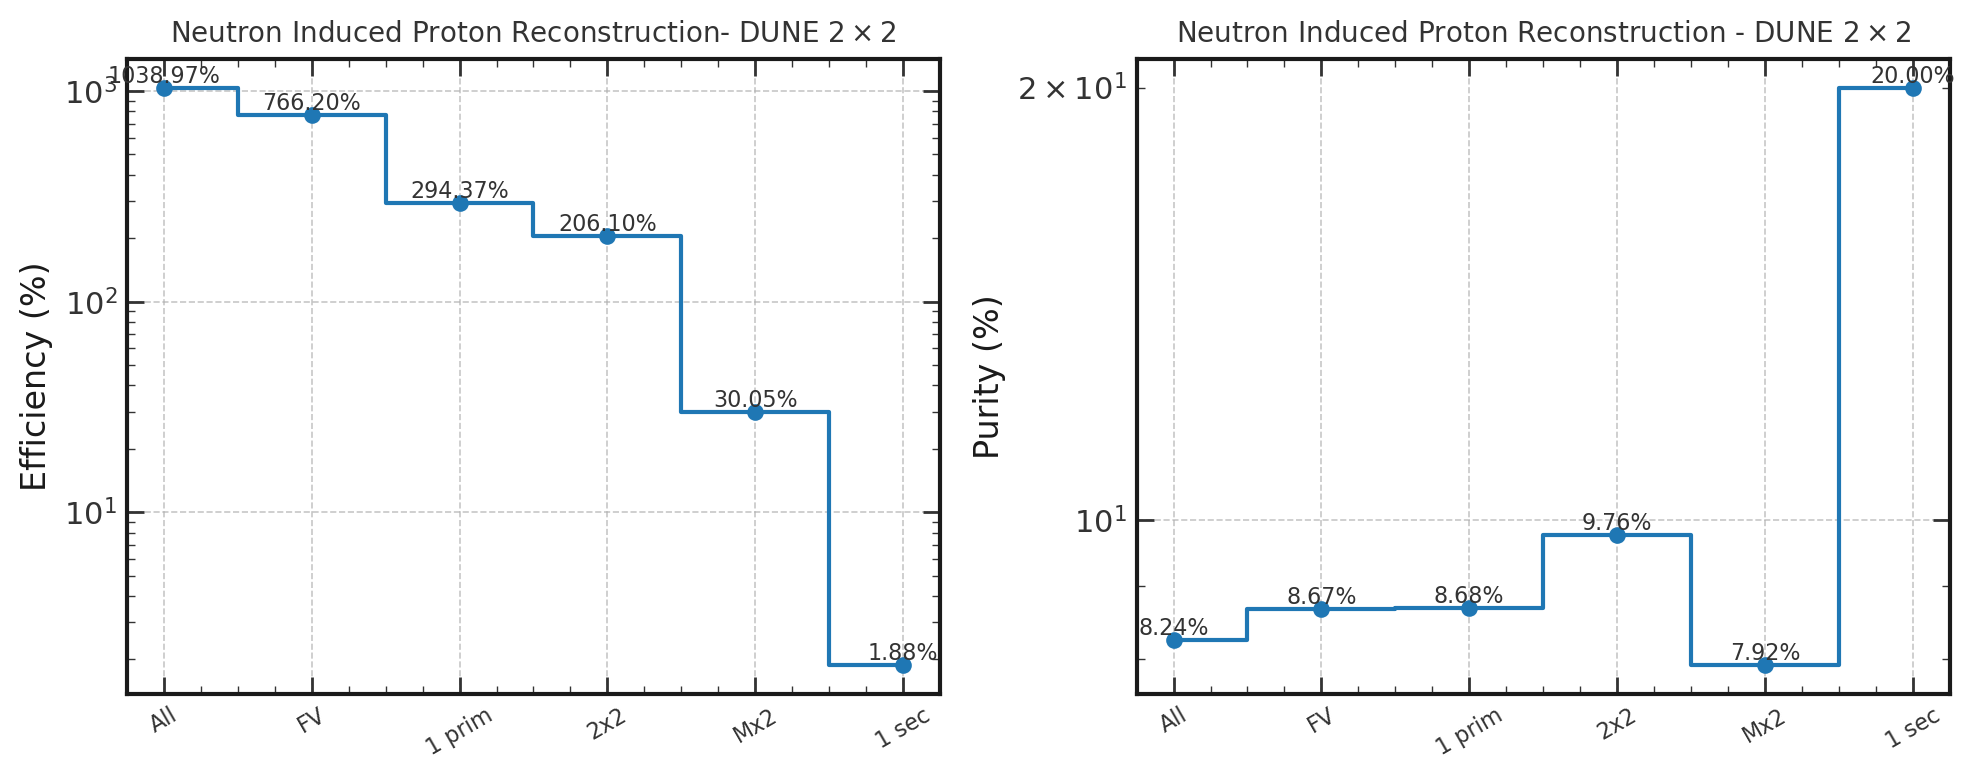

In [11]:
portions_eff=[results_df.iloc[0]['Efficiency n-p']*(100), results_df.iloc[1]['Efficiency n-p']*(100),results_df.iloc[2]['Efficiency n-p']*(100),results_df.iloc[3]['Efficiency n-p']*(100), results_df.iloc[4]['Efficiency n-p']*(100), results_df.iloc[5]['Efficiency n-p']*(100)]
portions_pur=[results_df.iloc[0]['Purity n-p']*(100), results_df.iloc[1]['Purity n-p']*(100),results_df.iloc[2]['Purity n-p']*(100),results_df.iloc[3]['Purity n-p']*(100), results_df.iloc[4]['Purity n-p']*(100), results_df.iloc[5]['Purity n-p']*(100)]
positions = [0, 1, 2, 3,4,5]
labels = [r'All', r'FV', r'1 prim', r'2x2', r'Mx2', r'1 sec']

# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
# Plot Efficiency
axes[0].step(positions, portions_eff, marker='o', label='Efficiency', where='mid')
axes[0].set_xticks(positions)
axes[0].set_xticklabels(labels, rotation=30, fontsize=8)
axes[0].set_yscale('log')
axes[0].set_title(r'Neutron Induced Proton Reconstruction- DUNE $2\times 2$', fontsize=10)
axes[0].set_ylabel('Efficiency (%)')
for i, value in enumerate(portions_eff):
    axes[0].text(positions[i], value, f'{value:.2f}%', ha='center', va='bottom', fontsize=8)

# Plot Purity
axes[1].step(positions, portions_pur, marker='o', label='Purity', where='mid')
axes[1].set_xticks(positions)
axes[1].set_xticklabels(labels, rotation=30, fontsize=8)
axes[1].set_yscale('log')
axes[1].set_title(r'Neutron Induced Proton Reconstruction - DUNE $2\times 2$', fontsize=10)
axes[1].set_ylabel('Purity (%)')
for i, value in enumerate(portions_pur):
    axes[1].text(positions[i], value, f'{value:.2f}%', ha='center', va='bottom', fontsize=8)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()


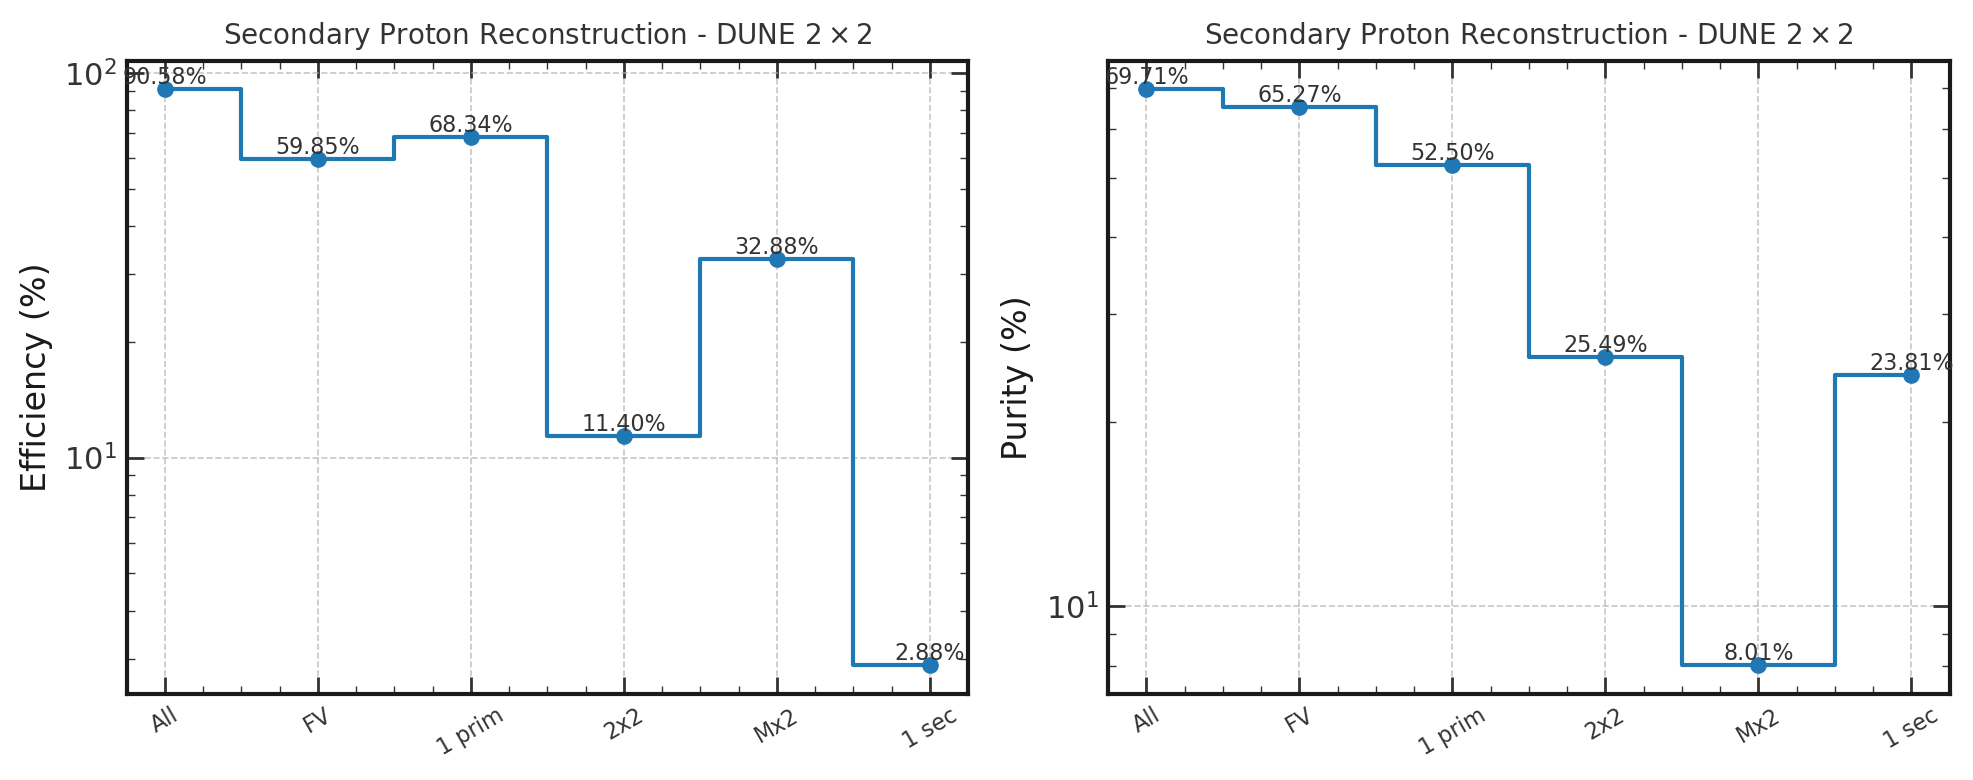

In [56]:
# Extract efficiency and purity values
portions_eff=[results_df.iloc[0]['Efficiency p']*(100), results_df.iloc[1]['Efficiency p']*(100),results_df.iloc[2]['Efficiency p']*(100),results_df.iloc[3]['Efficiency p']*(100), results_df.iloc[4]['Efficiency n-p']*(100), results_df.iloc[5]['Efficiency n-p']*(100)]
portions_pur=[results_df.iloc[0]['Purity p']*(100), results_df.iloc[1]['Purity p']*(100),results_df.iloc[2]['Purity p']*(100),results_df.iloc[3]['Purity p']*(100), results_df.iloc[4]['Purity n-p']*(100),results_df.iloc[5]['Purity n-p']*(100) ]
positions = [0, 1, 2, 3,4,5]
labels = [r'All', r'FV', r'1 prim', r'2x2', r'Mx2', r'1 sec']

# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Plot Efficiency
axes[0].step(positions, portions_eff, marker='o', label='Efficiency', where='mid')
axes[0].set_xticks(positions)
axes[0].set_xticklabels(labels, rotation=30, fontsize=8)
axes[0].set_yscale('log')
axes[0].set_title(r'Secondary Proton Reconstruction - DUNE $2\times 2$', fontsize=10)
axes[0].set_ylabel('Efficiency (%)')
for i, value in enumerate(portions_eff):
    axes[0].text(positions[i], value, f'{value:.2f}%', ha='center', va='bottom', fontsize=8)

# Plot Purity
axes[1].step(positions, portions_pur, marker='o', label='Purity', where='mid')
axes[1].set_xticks(positions)
axes[1].set_xticklabels(labels, rotation=30, fontsize=8)
axes[1].set_yscale('log')
axes[1].set_title(r'Secondary Proton Reconstruction - DUNE $2\times 2$', fontsize=10)
axes[1].set_ylabel('Purity (%)')
for i, value in enumerate(portions_pur):
    axes[1].text(positions[i], value, f'{value:.2f}%', ha='center', va='bottom', fontsize=8)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()


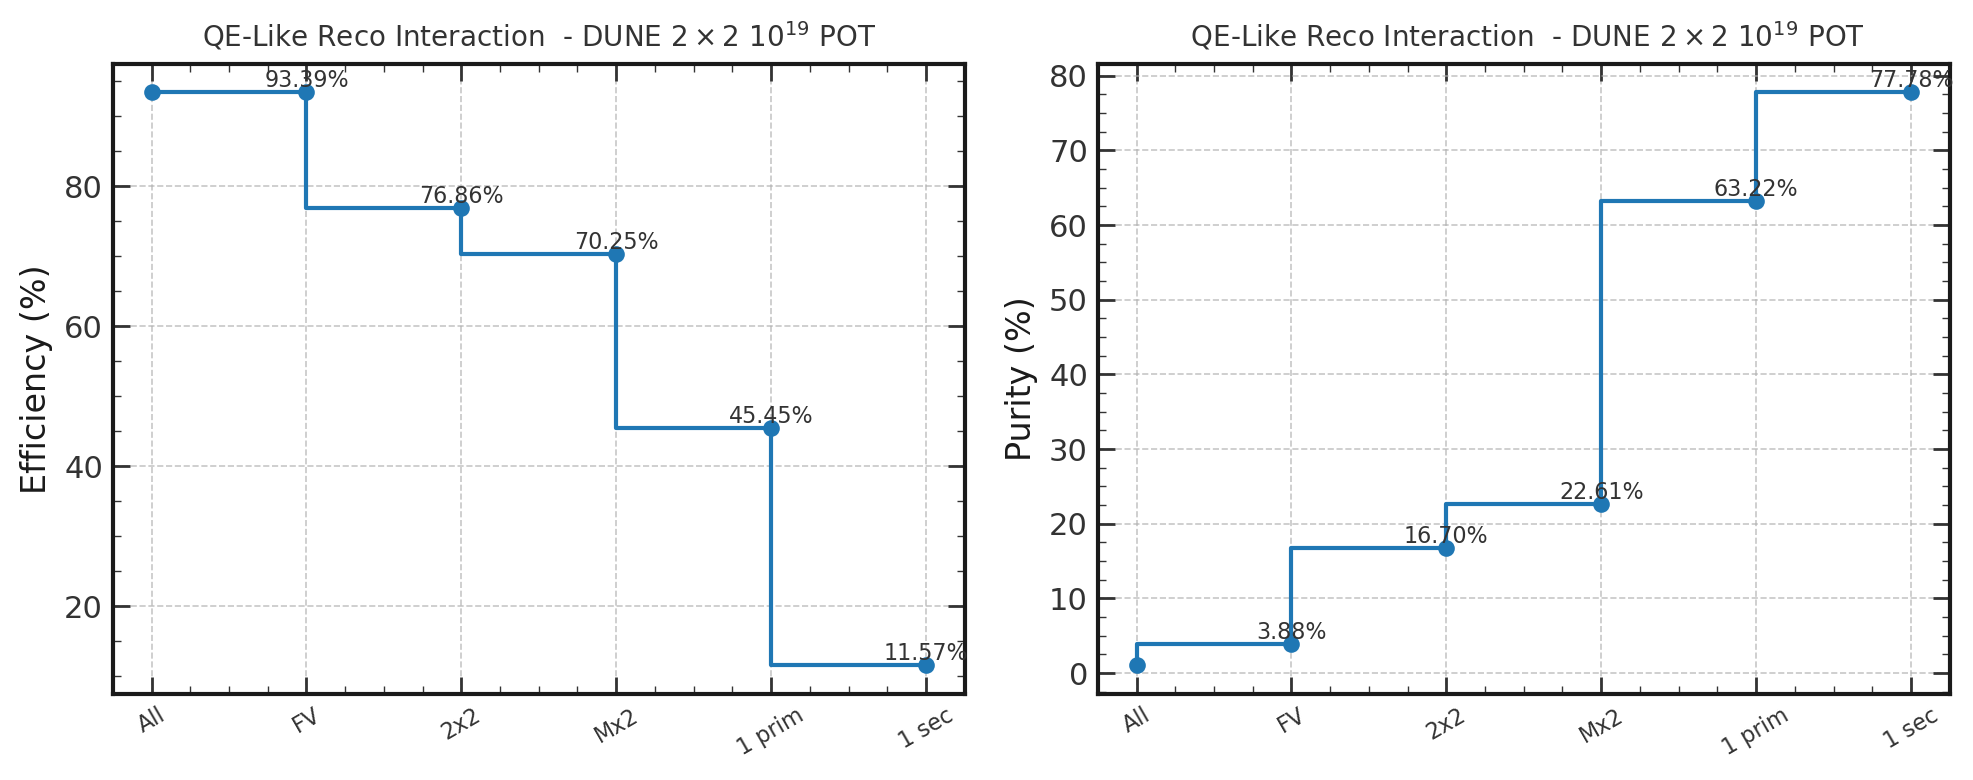

In [20]:
# Extract efficiency and purity values
portions_eff = [
    results_df.iloc[0]['Efficiency inx'] * 100,
    results_df.iloc[1]['Efficiency inx'] * 100,
    results_df.iloc[2]['Efficiency inx'] * 100,
    results_df.iloc[3]['Efficiency inx'] * 100,
    results_df.iloc[4]['Efficiency inx'] * 100,
    results_df.iloc[5]['Efficiency inx'] * 100
]

portions_pur = [
    results_df.iloc[0]['Purity inx'] * 100,
    results_df.iloc[1]['Purity inx'] * 100,
    results_df.iloc[2]['Purity inx'] * 100,
    results_df.iloc[3]['Purity inx'] * 100,
    results_df.iloc[4]['Purity inx'] * 100,
    results_df.iloc[5]['Purity inx'] * 100
]

positions = [0, 1, 2, 3,4,5]
labels = [r'All', r'FV', r'2x2', r'Mx2', r'1 prim', r'1 sec']
# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Plot Efficiency
axes[0].step(positions, portions_eff, marker='o', label='Efficiency')
axes[0].set_xticks(positions)
axes[0].set_xticklabels(labels, rotation=30, fontsize=8)
#axes[0].set_yscale('log')
axes[0].set_title(r'QE-Like Reco Interaction  - DUNE $2\times 2$ $ 10^{19}$ POT', fontsize=10)
axes[0].set_ylabel('Efficiency (%)')
for i, value in enumerate(portions_eff):
    if i == 0: continue
    axes[0].text(positions[i], value, f'{value:.2f}%', ha='center', va='bottom', fontsize=8)

# Plot Purity
axes[1].step(positions, portions_pur, marker='o', label='Purity')
axes[1].set_xticks(positions)
axes[1].set_xticklabels(labels, rotation=30, fontsize=8)
#axes[1].set_yscale('log')
axes[1].set_title(r' QE-Like Reco Interaction  - DUNE $2\times 2$ $ 10^{19}$ POT', fontsize=10)
axes[1].set_ylabel('Purity (%)')
for i, value in enumerate(portions_pur):
    if i == 0: continue
    axes[1].text(positions[i], value, f'{value:.2f}%', ha='center', va='bottom', fontsize=8)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()


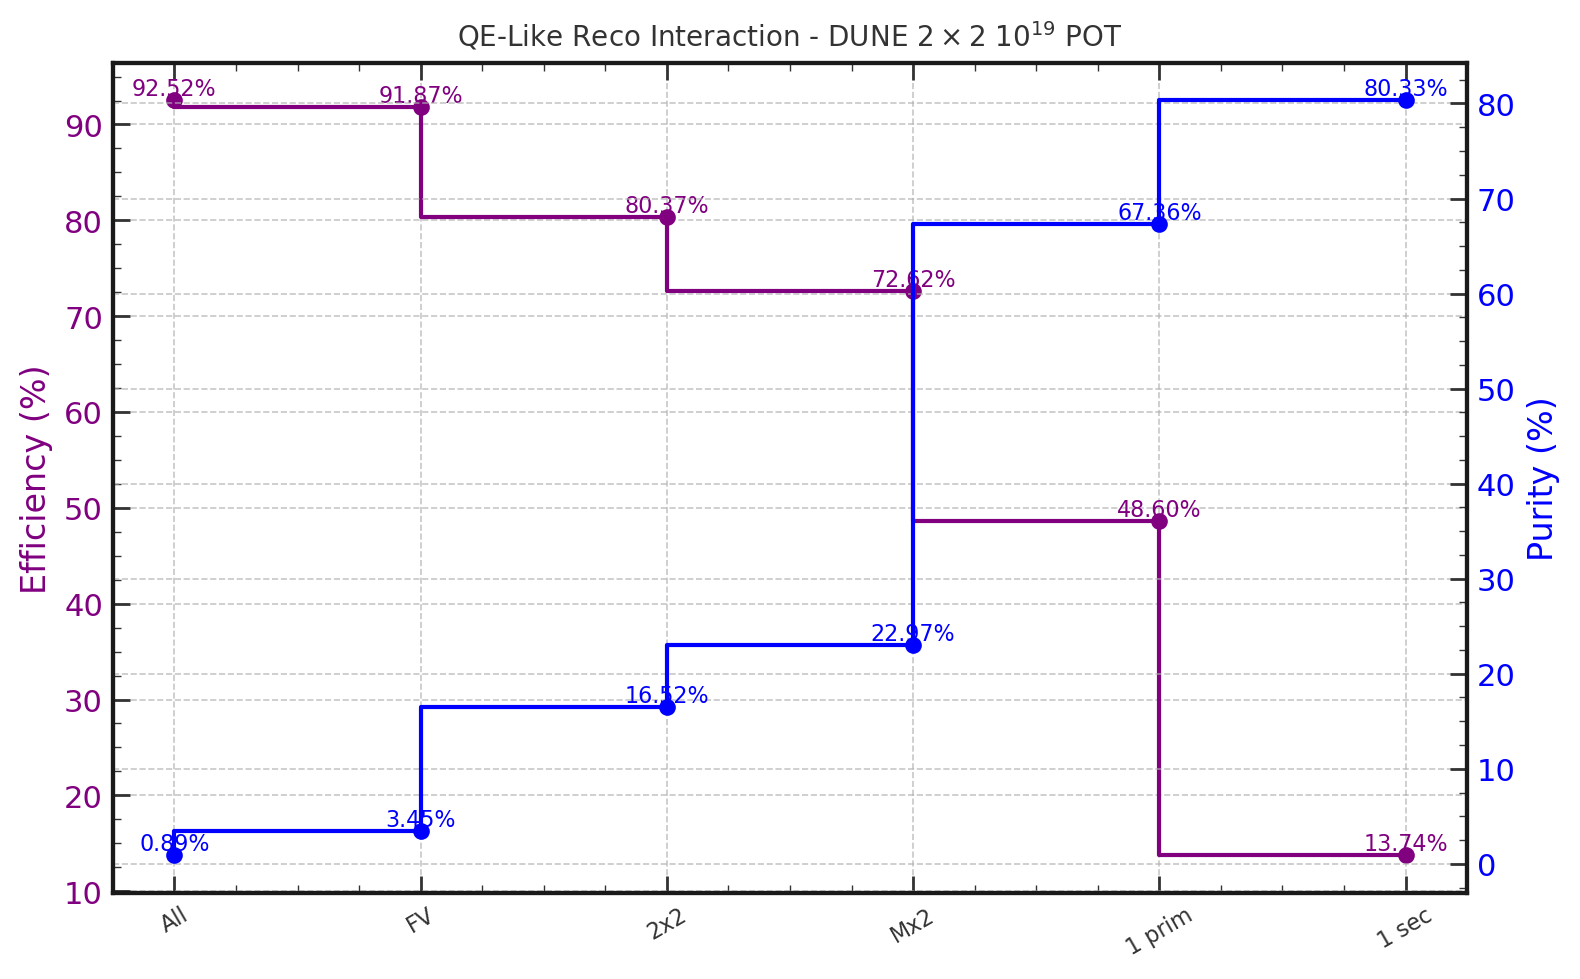

In [14]:
import matplotlib.pyplot as plt

# Define efficiency and purity values
portions_eff = [
    results_df.iloc[0]['Efficiency inx'] * 100,
    results_df.iloc[1]['Efficiency inx'] * 100,
    results_df.iloc[2]['Efficiency inx'] * 100,
    results_df.iloc[3]['Efficiency inx'] * 100,
    results_df.iloc[4]['Efficiency inx'] * 100,
    results_df.iloc[5]['Efficiency inx'] * 100
]

portions_pur = [
    results_df.iloc[0]['Purity inx'] * 100,
    results_df.iloc[1]['Purity inx'] * 100,
    results_df.iloc[2]['Purity inx'] * 100,
    results_df.iloc[3]['Purity inx'] * 100,
    results_df.iloc[4]['Purity inx'] * 100,
    results_df.iloc[5]['Purity inx'] * 100
]

positions = [0, 1, 2, 3, 4, 5]
labels = [r'All', r'FV', r'2x2', r'Mx2', r'1 prim', r'1 sec']



# Create a single figure and axis
fig, ax1 = plt.subplots(figsize=(8, 5))

# Plot Efficiency
ax1.step(positions, portions_eff, marker='o', label='Efficiency', color='purple')
ax1.set_xticks(positions)
ax1.set_xticklabels(labels, rotation=30, fontsize=8)
ax1.set_ylabel('Efficiency (%)', color='purple')
ax1.tick_params(axis='y', labelcolor='purple')
for i, value in enumerate(portions_eff):
    ax1.text(positions[i], value, f'{value:.2f}%', ha='center', va='bottom', fontsize=8, color='purple')

# Create second y-axis for purity
ax2 = ax1.twinx()
ax2.step(positions, portions_pur, marker='o', label='Purity', color='b')
ax2.set_ylabel('Purity (%)', color='b')
ax2.tick_params(axis='y', labelcolor='b')
for i, value in enumerate(portions_pur):
    ax2.text(positions[i], value, f'{value:.2f}%', ha='center', va='bottom', fontsize=8, color='b')

# Title and layout
plt.title(r'QE-Like Reco Interaction - DUNE $2\times 2$ $10^{19}$ POT', fontsize=10)
plt.tight_layout()
plt.show()


In [8]:
# Extract efficiency and purity values
portions_eff = [
    results_df.iloc[0]['Efficiency inx'] * 100,
    results_df.iloc[1]['Efficiency inx'] * 100,
    results_df.iloc[2]['Efficiency inx'] * 100,
    results_df.iloc[3]['Efficiency inx'] * 100,
    results_df.iloc[4]['Efficiency inx'] * 100,
    results_df.iloc[5]['Efficiency inx'] * 100
]

portions_pur = [
    results_df.iloc[0]['Purity inx'] * 100,
    results_df.iloc[1]['Purity inx'] * 100,
    results_df.iloc[2]['Purity inx'] * 100,
    results_df.iloc[3]['Purity inx'] * 100,
    results_df.iloc[4]['Purity inx'] * 100,
    results_df.iloc[5]['Purity inx'] * 100
]

cases = ['All', 'FV', '2x2', 'Mx2', '1prim', '1sec']

# Create scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(portions_pur,portions_eff, color='g')

# Annotate points with case labels
for i, case in enumerate(cases):
    plt.text(portions_pur[i], portions_eff[i],  case, fontsize=9, ha='right', va='bottom')

plt.ylabel('Efficiency (%)')
plt.xlabel('Purity (%)')
#plt.yscale('log')
plt.title('Purity vs Efficiency Trade-off')
plt.grid(True)
plt.legend()
plt.show()



IndexError: single positional indexer is out-of-bounds

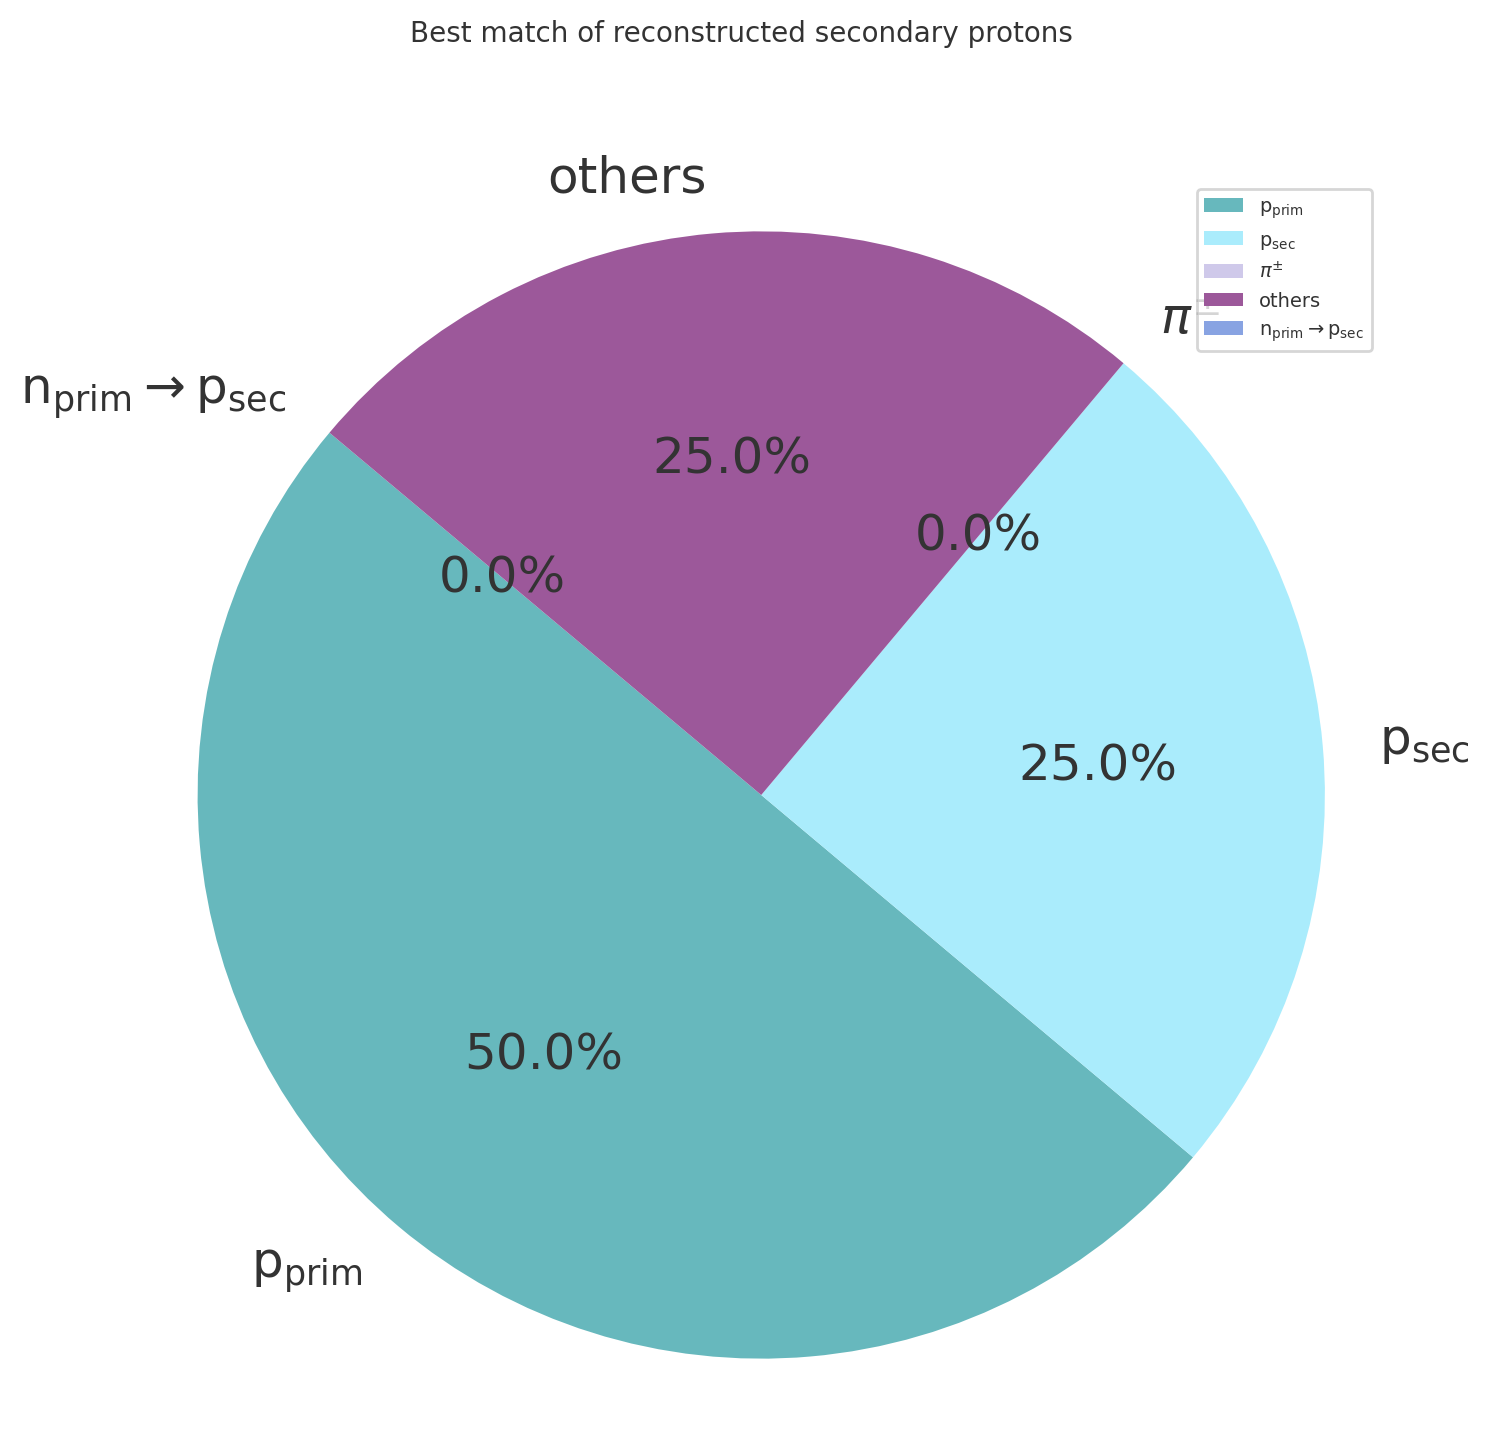

/global/homes/g/gkufatty/.conda/envs/env-nersc/lib/python3.12/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


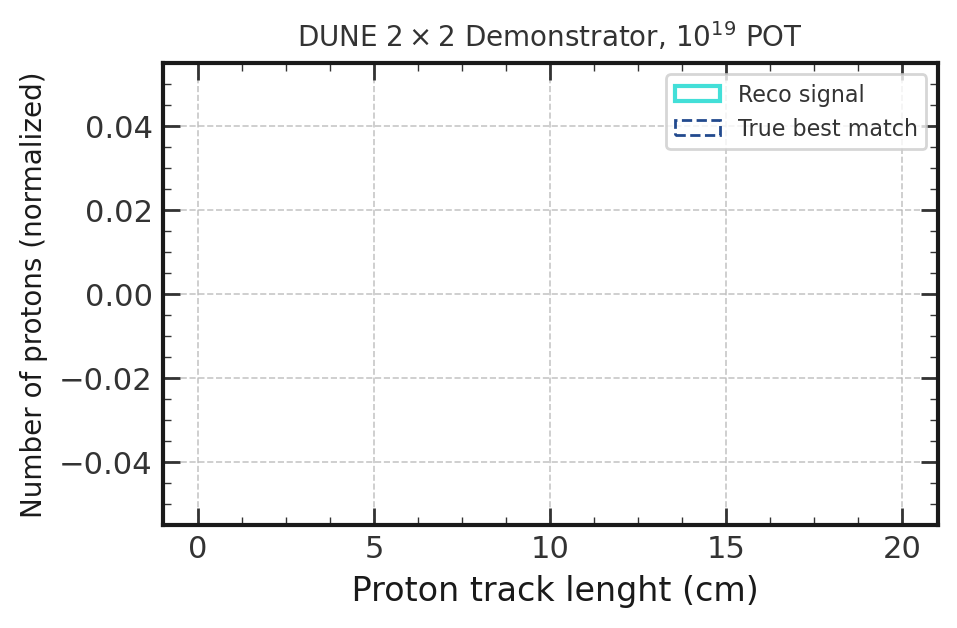

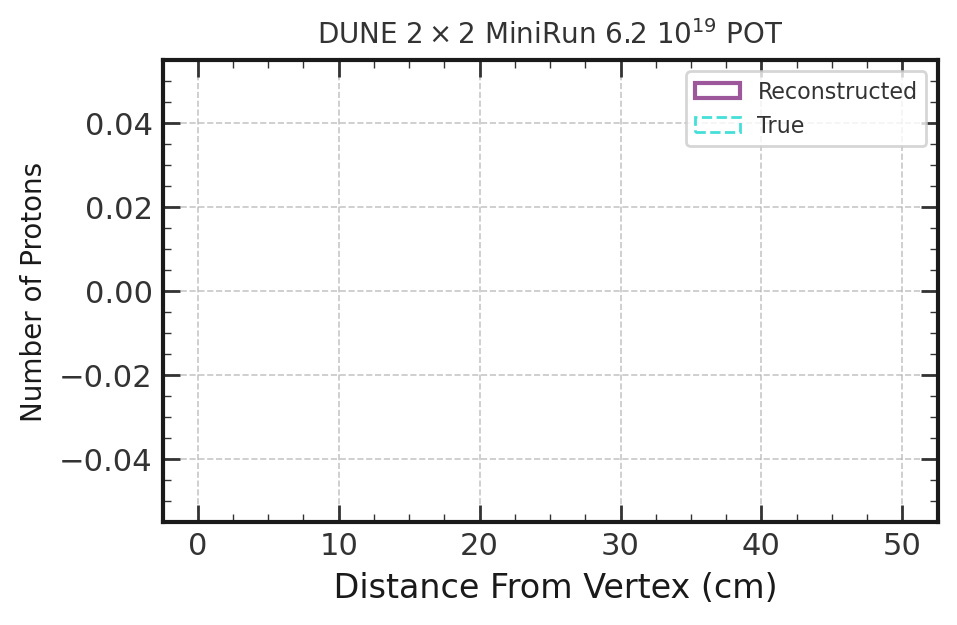

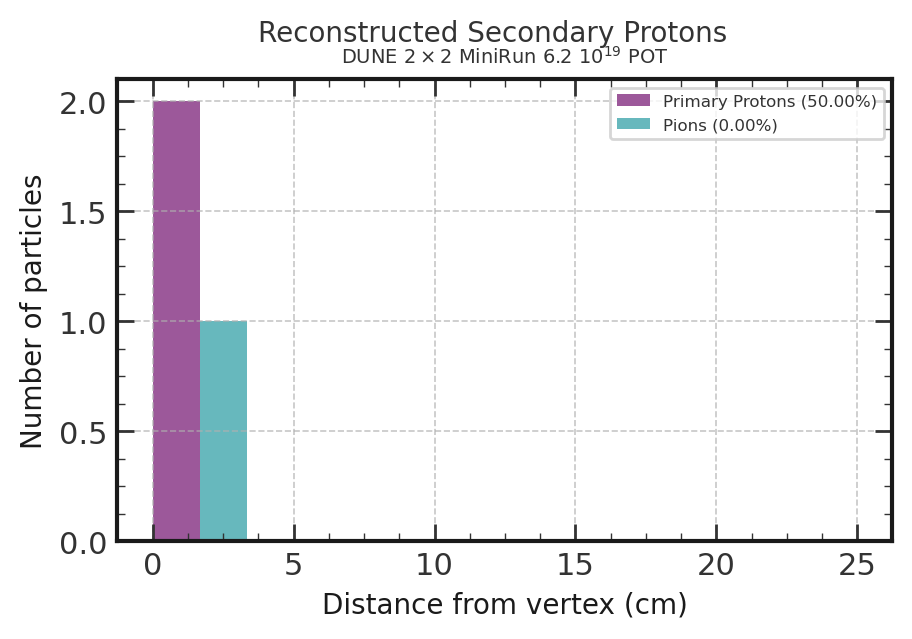

ValueError: Invalid vmin or vmax

Error in callback <function _draw_all_if_interactive at 0x7f59fc8662a0> (for post_execute), with arguments args (),kwargs {}:


ValueError: Invalid vmin or vmax

ValueError: Invalid vmin or vmax

<Figure size 1000x600 with 2 Axes>

In [12]:
#to run the global analyzer directly from the cvs files

import pandas as pd

# Load CSV file into a DataFrame

case= 'Case A'

reco_proton_file = f"/global/homes/g/gkufatty/projects/neutron-multiplicity/analysis/results/neutron_selection_{case}_reco_proton.csv"  # Update with your actual file path
sample_dic_file = f"/global/homes/g/gkufatty/projects/neutron-multiplicity/analysis/results/neutron_selection_{case}_sample.csv"
reco_proton_dic_df = pd.read_csv(reco_proton_file)
sample_dic_df = pd.read_csv(sample_dic_file)

# Convert the DataFrame to the required dictionary format
reco_proton_dic = {
    'best_match_pdg': reco_proton_dic_df['best_match_pdg'].tolist(),
    'best_match_type': reco_proton_dic_df['best_match_type'].tolist(),
    'best_match_length': reco_proton_dic_df['best_match_length'].tolist(),
    'best_match_distance': reco_proton_dic_df['best_match_distance'].tolist(),
    'reco_distance':reco_proton_dic_df['reco_distance'].tolist(),
    'reco_energy': reco_proton_dic_df['reco_energy'].tolist(),
    'reco_length': reco_proton_dic_df['reco_length'].tolist(),
    'parent_id': reco_proton_dic_df['parent_id'].tolist(),
}

sample_dic = {
    'best_match_length': sample_dic_df['best_match_length'].tolist(),
    'best_match_distance': sample_dic_df['best_match_distance'].tolist(),
    'best_match_energy': sample_dic_df['best_match_energy'].tolist(),
    'reco_distance': sample_dic_df['reco_distance'].tolist(),
    'reco_energy': sample_dic_df['reco_energy'].tolist(),
    'reco_length': sample_dic_df['reco_length'].tolist(),
}

# Initialize GlobalAnalyzer with dictionaries
global_analyzer = GlobalAnalyzer(reco_proton_dic, sample_dic, case="Case A")

# Run the analysis functions
global_analyzer.particle_predictions()
global_analyzer.plot_track_lenght()
global_analyzer.plot_part_dis()
global_analyzer.lenght_vs_distance()

# Save the results to a PDF
pdf_filename = global_analyzer.save_pdf()
print(f"Analysis saved in {pdf_filename}")
